<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/src/key_authors_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

Note: google drive is no longer supported. Adjust the input and output path if needed.

In [1]:
# Python
from __future__ import annotations

# System
import importlib
from importlib.metadata import entry_points
import os
from pathlib import Path

# ML
import pandas as pd
import numpy as np
from pandas.api.types import is_numeric_dtype

# Plot
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import StrMethodFormatter
import matplotlib.patches as mpatches
from matplotlib_venn import venn3
import seaborn as sns

# TF-IDf
from sklearn.feature_extraction.text import TfidfTransformer
# from sklearn.feature_extraction.text import TfidfVectorizer
# import torch

# Graphs
# Enable cu-Graph as the gpu-accelerated backend for NetworkX 
%env NX_CUGRAPH_AUTOCONFIG=False # TODO: Make true for GPU.
import networkx as nx

backends = [ep.name for ep in entry_points().select(group="networkx.backends")]
print("NetworkX backends =", backends)


# sklearn
from sklearn.feature_selection import mutual_info_classif

# General
import math
from collections.abc import Iterable
from tqdm import tqdm
import re
from datetime import date
from typing import List

env: NX_CUGRAPH_AUTOCONFIG=False # TODO: Make true for GPU.
NetworkX backends = ['cugraph', 'nx_loopback']


# Parameters

In [2]:
# Path to data
# Recommended: working directory is: "Backbone-Graph/src"
dataset_folder = "Labeled_Datasets/Ecuador"   # folder path
file_name = "Ecuador_part_all.gzip.parquet"  # file name
dataset_procced_date = "2026_01_10"        # ("%Y_%m_%d")


# Flags to control execution
run_demo = True  # Controls the demo functions until the Parameter Sweep section
run_graph_filtering = False  # Controls run_graph_filtering
run_parameter_sweep_analysis = False  # Controls the Parameter Sweep: Information Gain Analysis section
run_temporal_io_analysis_flag = False

use_boost_authors = False

# columns' names
account_id_col = "accountid"
author_key_score_col = "topic_author_key_score"
post_time_col = "post_time"
is_io_control_col = "is_control"

# parametres
topic_col = "BERTopic_topic_256"
top_percentage = 0.01 # percentage of top authors to select as key\boost authors.
entity_cols_lst = ["hashtags", "account_mentions", "ner_entities"] # no "urls"

# Loading and Exporting

## Load Data

In [3]:
# Note: Google Colab not supported anymore.

# Cluster\Local
# Recommended: working directory is: "Backbone-Graph/src"
file_name_no_suffixes = file_name.split(".")[0]
processed_dataset_path = Path("../experimental_results") / dataset_folder / file_name_no_suffixes / dataset_procced_date
# Example: ""../results/Labeled_Datasets/Ecuador/Ecuador_part_4/2025_11_27"
df_input_path = processed_dataset_path / f"processed_{file_name}"
print(f"Running on local/cluster.\nLoading data from: {df_input_path}")

# Load the parquet file
df = pd.read_parquet(df_input_path)

df[account_id_col] = df[account_id_col].astype(str)
print(f"In the df casted {account_id_col} to str")

# for testing
# df = df.sample(n = 500).reset_index(drop=True)  # TODO delete after debugging.

Running on local/cluster.
Loading data from: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/processed_Ecuador_part_all.gzip.parquet
In the df casted accountid to str


## Output

In [4]:
folder_output_path = processed_dataset_path / date.today().strftime("%Y_%m_%d")
folder_output_path.mkdir(parents=True, exist_ok=True)
print(f"Output will be saved to: {folder_output_path}")

Output will be saved to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07


# Logs

In [5]:
from functools import wraps
from datetime import datetime



REPORT_PATH = folder_output_path / "progress_report.txt"

def write_report(msg: str):
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"{timestamp} | {msg}"

    print(line)
    with open(REPORT_PATH, "a") as f:
        f.write(line + "\n")


def report_done(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        try:
            result = func(*args, **kwargs)
            write_report(f"Completed: {func.__name__}")
            return result
        except Exception as e:
            write_report(f"FAILED: {func.__name__} | {e}")
            write_report("#######################################################")
            write_report("#######################################################")
            raise
    return wrapper

In [6]:
write_report("Starting new execution of key_authors_graph.ipynb")
write_report(f"df path: {df_input_path}")
write_report(f"df with {len(df):,} rows and {len(df.columns):,} columns")
write_report(f"Output path: {folder_output_path}")

2026-07-07 16:53:23 | Starting new execution of key_authors_graph.ipynb
2026-07-07 16:53:23 | df path: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/processed_Ecuador_part_all.gzip.parquet
2026-07-07 16:53:23 | df with 1,468,565 rows and 37 columns
2026-07-07 16:53:23 | Output path: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07


# Save df

In [7]:
def save_df(df, folder_output_path, file_name):
    df_output_path = folder_output_path / f"processed_{file_name}"
    df.to_parquet(df_output_path, index=False, compression="gzip")
    write_report(f"df is saved to: {df_output_path}")

# Statistics

## Dataset Collums

In [8]:
print(f"df shape: ({df.shape[0]:,}, {df.shape[1]:,})")
print(f"Number of posts: {df.shape[0]:,}")
print(f"Number of unique authors: {df[account_id_col].nunique():,}")

print("")
print(f"{'**column name**':<30} **value type**")
for col in df.columns:
    # dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")

df shape: (1,468,565, 37)
Number of posts: 1,468,565
Number of unique authors: 21,923

**column name**                **value type**
postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | ndarray
is_control                     | bool
clean_text_with_entities       | str
clean_text_without_enteties    | str
translated_post                | str
BERTopic_topic_512          

## Account Mentions

In [9]:
# All authors that appear as accountid
authors_set = set(df[account_id_col].astype(str))

# All mentioned accounts
mentioned_authors = (
    df["account_mentions"]
    .dropna()
    .explode()
    .dropna()
    .astype(str)
    .unique()
)

# Mentions that are not authors in the dataset
print(f"Number of unique authors in {account_id_col} col: {len(authors_set):,}")
print(f"Number of mentioned authors: {len(mentioned_authors):,}")

mentioned_not_in_authors = set(mentioned_authors) - authors_set
print(f"Number of mentioned authors not in {account_id_col} col: {len(mentioned_not_in_authors):,} ({len(mentioned_not_in_authors) / len(mentioned_authors):.2%} of mentioned authors)")

Number of unique authors in accountid col: 21,923
Number of mentioned authors: 271,772
Number of mentioned authors not in accountid col: 266,774 (98.16% of mentioned authors)


In [10]:
# All authors that appear as accountid
authors_set = set(df[account_id_col].astype(str))

# Count how many times each account was mentioned
top_mentioned_authors_df = (
    df["account_mentions"]
    .dropna()
    .explode()
    .dropna()
    .astype(str)
    .value_counts()
    .reset_index()
)

top_mentioned_authors_df.columns = ["mentioned_accountid", "n_mentions"]

# Check if mentioned account appears as an author in the dataset
top_mentioned_authors_df["in_accountid_col"] = (
    top_mentioned_authors_df["mentioned_accountid"].isin(authors_set)
)


top_mentioned_authors_df.head(20).style.format({
    "n_mentions": "{:,}",
})

,mentioned_accountid,n_mentions,in_accountid_col
0,bef0e7981715abed0539a1eb8eedfdbf59651779f2,"193,901",True
1,aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d,"135,252",True
2,2087399d0b911ed0bb43aa9da21d7301f0a077e56c,"23,191",False
3,356b94f846e87ef3ad4e46c8847006b951d69314dc,"18,308",False
4,d77588c443644c33536cb68bb7610be2626b47b9b9,"18,053",True
5,516b0c1e968fe2c596440e5f94a61374a5bf26609b,"15,032",True
6,80e00b6d6a476e829fc977de4c7979270adb18cdaa,"14,705",False
7,fd79c292c5fe7c57e7ac6e43d6718d69db188c113e,"8,790",False
8,e8ca68507f7532e090467601f5732ac09ef97d5a96,"6,901",False
9,c957fab00d944792334d287af000aec15f39f5fba3,"6,590",False


## Topics Distribution

In [11]:
def extract_number(col_name: str) -> int:
    """Extract first integer found in column name.
    
    Args:
        col_name: Column name string.
        
    Returns:
        int: Extracted number or -1 if none found.
    """
    match = re.search(r"\d+", col_name)
    return int(match.group()) if match else -1

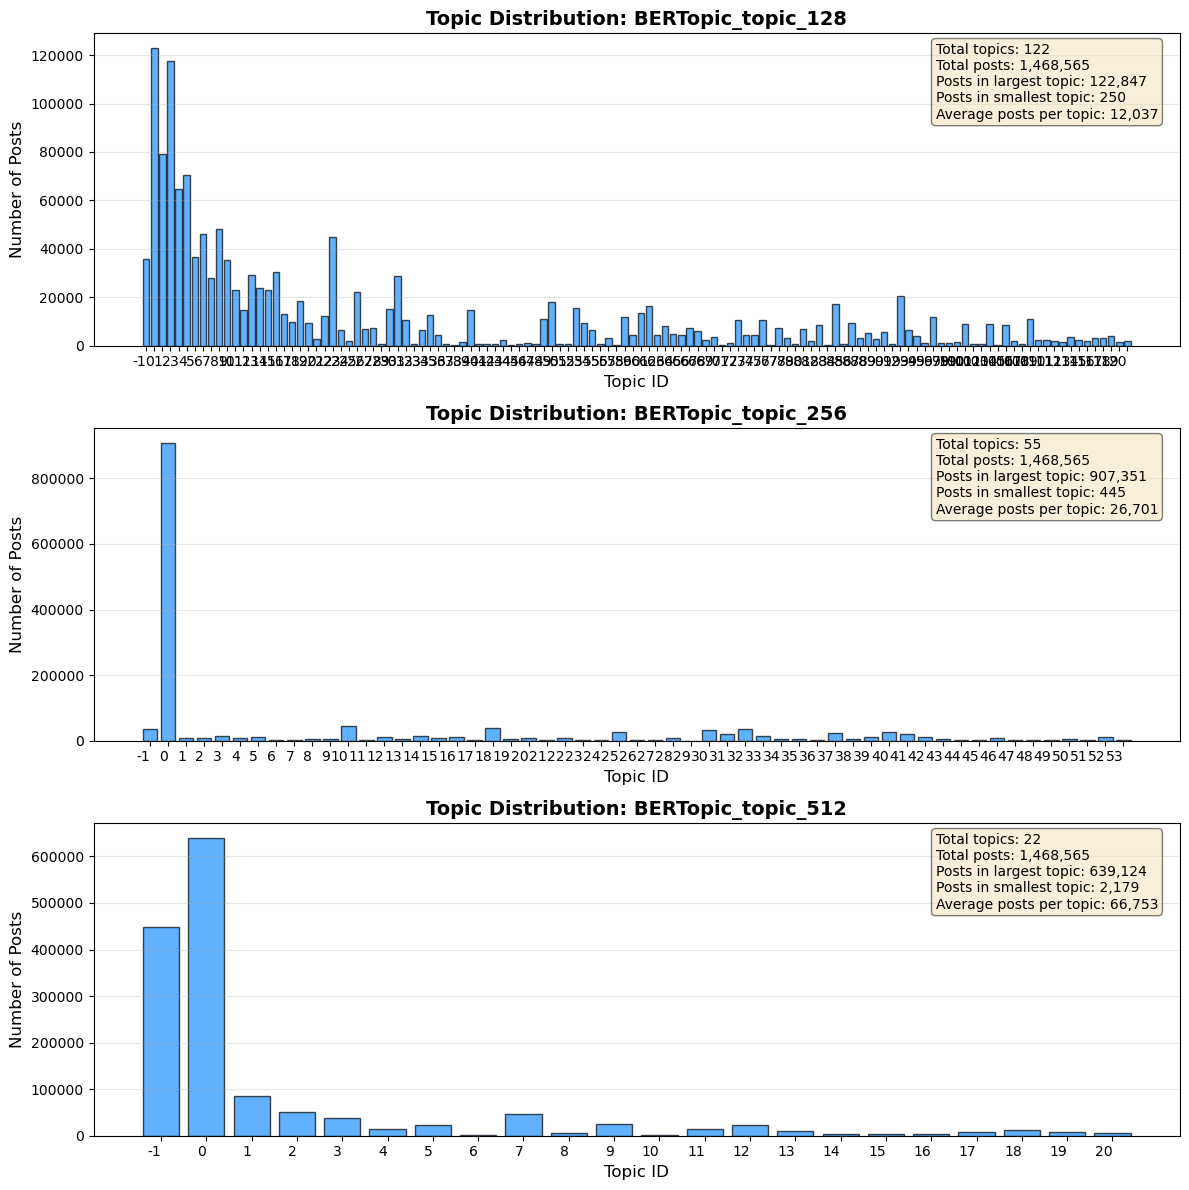

In [12]:
if run_demo:
    # Find all columns with "BERT", "K_Means", or "topic" in the name (excluding "prob" columns)
    topic_columns = [
        col for col in df.columns 
        if any(keyword.lower() in col.lower() for keyword in ["BERT", "K_Means", "topic"])
        and "prob" not in col.lower()
    ]
    topic_columns = sorted(topic_columns, key=extract_number)

    # Create distribution plots for each topic column
    num_cols = len(topic_columns)
    fig, axes = plt.subplots(num_cols, 1, figsize=(12, 4 * num_cols))

    # Handle case where there's only one column (axes won't be an array)
    if num_cols == 1:
        axes = [axes]

    for idx, col in enumerate(topic_columns):
        # Count posts per topic
        topic_counts = df[col].value_counts().sort_index()
        
        # Create bar plot
        axes[idx].bar(topic_counts.index, topic_counts.values, color='dodgerblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f"Topic Distribution: {col}", fontsize=14, fontweight='bold')
        axes[idx].set_xlabel("Topic ID", fontsize=12)
        axes[idx].set_ylabel("Number of Posts", fontsize=12)
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Set x-ticks to show all topic IDs
        axes[idx].set_xticks(topic_counts.index)
        axes[idx].set_xticklabels(topic_counts.index, rotation=0, ha='right')
        
        # Add count information
        topic_counts = df[col].value_counts()
        axes[idx].text(
            0.98, 0.97,
            f"Total topics: {len(topic_counts)}\n"
            f"Total posts: {len(df):,}\n"
            f"Posts in largest topic: {topic_counts.max():,}\n"
            f"Posts in smallest topic: {topic_counts.min():,}\n"
            f"Average posts per topic: {topic_counts.mean():,.0f}",
            transform=axes[idx].transAxes,
            verticalalignment='top',
            horizontalalignment='right',
            multialignment='left',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    )

    plt.tight_layout()

    plt.savefig(folder_output_path / f"topic_distributions.png", dpi=300)
    plt.show()
    plt.close()

## IO/Control Tweet Distribution

In [13]:
def plot_io_control_avg_tweets_bar(
    df: pd.DataFrame,
    author_col: str = "accountid",
    is_control_col: str = "is_control",
    output_folder_path: str | Path | None = None,
) -> pd.DataFrame:
    """Plot average tweet count per IO/control account over the full dataset."""
    required_cols = {author_col, is_control_col}
    missing_cols = sorted(required_cols - set(df.columns))
    if missing_cols:
        raise KeyError(f"Missing required df columns: {missing_cols}")

    plot_df = df[[author_col, is_control_col]].copy()
    plot_df[author_col] = plot_df[author_col].astype(str)

    labels = plot_df[is_control_col].replace({
        "True": 1,
        "true": 1,
        "False": 0,
        "false": 0,
    })
    labels = pd.to_numeric(labels, errors="coerce")
    invalid_labels = labels.isna() | ~labels.isin([0, 1])
    if invalid_labels.any():
        raise ValueError(
            f"{is_control_col!r} contains "
            f"{int(invalid_labels.sum()):,} values outside 0/1 or False/True."
        )

    plot_df["account_type"] = labels.astype(int).map({0: "IO", 1: "Control"})
    account_post_counts = (
        plot_df.groupby(["account_type", author_col])
        .size()
        .rename("n_posts")
        .reset_index()
    )
    avg_posts_df = (
        account_post_counts.groupby("account_type")["n_posts"]
        .mean()
        .reindex(["IO", "Control"])
        .reset_index(name="avg_posts_per_account")
    )

    colors = {"IO": "crimson", "Control": "dodgerblue"}
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(
        avg_posts_df["account_type"],
        avg_posts_df["avg_posts_per_account"],
        color=[colors.get(label, "gray") for label in avg_posts_df["account_type"]],
        edgecolor="black",
        alpha=0.8,
    )
    ax.set_title("Average Number of Tweets per Account", fontsize=16, fontweight="bold")
    ax.set_xlabel("Account Type", fontsize=16)
    ax.set_ylabel("Average Number of Tweets", fontsize=16)
    ax.tick_params(axis="both", labelsize=14)
    ax.grid(axis="y", alpha=0.3)

    for idx, row in avg_posts_df.iterrows():
        if pd.notna(row["avg_posts_per_account"]):
            ax.text(
                idx,
                row["avg_posts_per_account"],
                f"{row['avg_posts_per_account']:.1f}",
                ha="center",
                va="bottom",
                fontsize=14,
            )

    plt.tight_layout()
    if output_folder_path is not None:
        output_folder_path = Path(output_folder_path)
        output_folder_path.mkdir(parents=True, exist_ok=True)
        plot_path = output_folder_path / "io_control_avg_tweets_per_account.png"
        plt.savefig(plot_path, dpi=300, bbox_inches="tight")
        print(f"Saved fig to: {plot_path}")

    plt.show()
    plt.close()

    return avg_posts_df

Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_control_avg_tweets_per_account.png


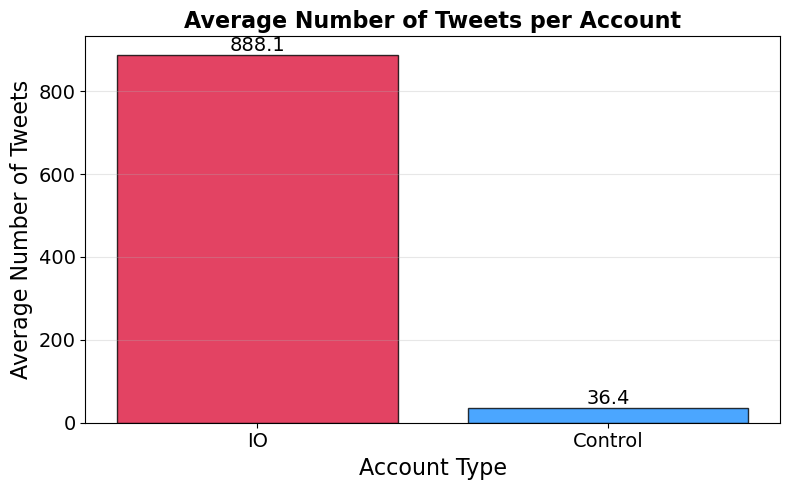

,account_type,avg_posts_per_account
0,IO,888.128335
1,Control,36.410465


In [14]:
if run_demo:
    io_control_avg_posts_df = plot_io_control_avg_tweets_bar(
        df=df,
        author_col=account_id_col,
        is_control_col=is_io_control_col,
        output_folder_path=folder_output_path,
    )
    display(io_control_avg_posts_df)

In [15]:
def plot_io_control_monthly_avg_tweets_scatter(
    df: pd.DataFrame,
    author_col: str = "accountid",
    is_control_col: str = "is_control",
    timestamp_col: str = "post_time",
    output_folder_path: str | Path | None = None,
) -> pd.DataFrame:
    """Plot monthly average tweet count per IO/control account."""
    required_cols = {author_col, is_control_col, timestamp_col}
    missing_cols = sorted(required_cols - set(df.columns))
    if missing_cols:
        raise KeyError(f"Missing required df columns: {missing_cols}")

    plot_df = df[[author_col, is_control_col, timestamp_col]].copy()
    plot_df[author_col] = plot_df[author_col].astype(str)
    plot_df[timestamp_col] = pd.to_datetime(plot_df[timestamp_col], errors="coerce")

    labels = plot_df[is_control_col].replace({
        "True": 1,
        "true": 1,
        "False": 0,
        "false": 0,
    })
    labels = pd.to_numeric(labels, errors="coerce")
    invalid_labels = labels.isna() | ~labels.isin([0, 1])
    if invalid_labels.any():
        raise ValueError(
            f"{is_control_col!r} contains "
            f"{int(invalid_labels.sum()):,} values outside 0/1 or False/True."
        )

    plot_df["account_type"] = labels.astype(int).map({0: "IO", 1: "Control"})
    plot_df = plot_df.dropna(subset=[timestamp_col, "account_type"])
    plot_df["month"] = plot_df[timestamp_col].dt.to_period("M").dt.to_timestamp()

    account_counts = plot_df.groupby("account_type")[author_col].nunique()
    monthly_posts = (
        plot_df.groupby(["month", "account_type"])
        .size()
        .rename("n_posts")
        .reset_index()
    )
    month_index = pd.date_range(plot_df["month"].min(), plot_df["month"].max(), freq="MS")
    full_index = pd.MultiIndex.from_product(
        [month_index, ["IO", "Control"]],
        names=["month", "account_type"],
    )

    monthly_avg_df = monthly_posts.set_index(["month", "account_type"])
    monthly_avg_df = monthly_avg_df.reindex(full_index, fill_value=0).reset_index()
    monthly_avg_df["n_accounts"] = monthly_avg_df["account_type"].map(account_counts).fillna(0).astype(int)
    monthly_avg_df["avg_posts_per_account"] = monthly_avg_df.apply(
        lambda row: row["n_posts"] / row["n_accounts"] if row["n_accounts"] > 0 else 0.0,
        axis=1,
    )

    colors = {"IO": "crimson", "Control": "dodgerblue"}
    fig, ax = plt.subplots(figsize=(12, 6))
    for account_type in ["IO", "Control"]:
        account_type_df = monthly_avg_df.loc[monthly_avg_df["account_type"] == account_type]
        ax.scatter(
            account_type_df["month"],
            account_type_df["avg_posts_per_account"],
            s=42,
            alpha=0.8,
            label=account_type,
            color=colors.get(account_type, "gray"),
        )

    ax.set_title("Monthly Average Number of Tweets per Account", fontsize=16, fontweight="bold")
    ax.set_xlabel("Month", fontsize=16)
    ax.set_ylabel("Average Number of Tweets", fontsize=16)
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(alpha=0.3)
    ax.legend(title="Account Type")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    if output_folder_path is not None:
        output_folder_path = Path(output_folder_path)
        output_folder_path.mkdir(parents=True, exist_ok=True)
        plot_path = output_folder_path / "io_control_monthly_avg_tweets_per_account.png"
        plt.savefig(plot_path, dpi=300, bbox_inches="tight")
        print(f"Saved fig to: {plot_path}")

    plt.show()
    plt.close()

    return monthly_avg_df

Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_control_monthly_avg_tweets_per_account.png


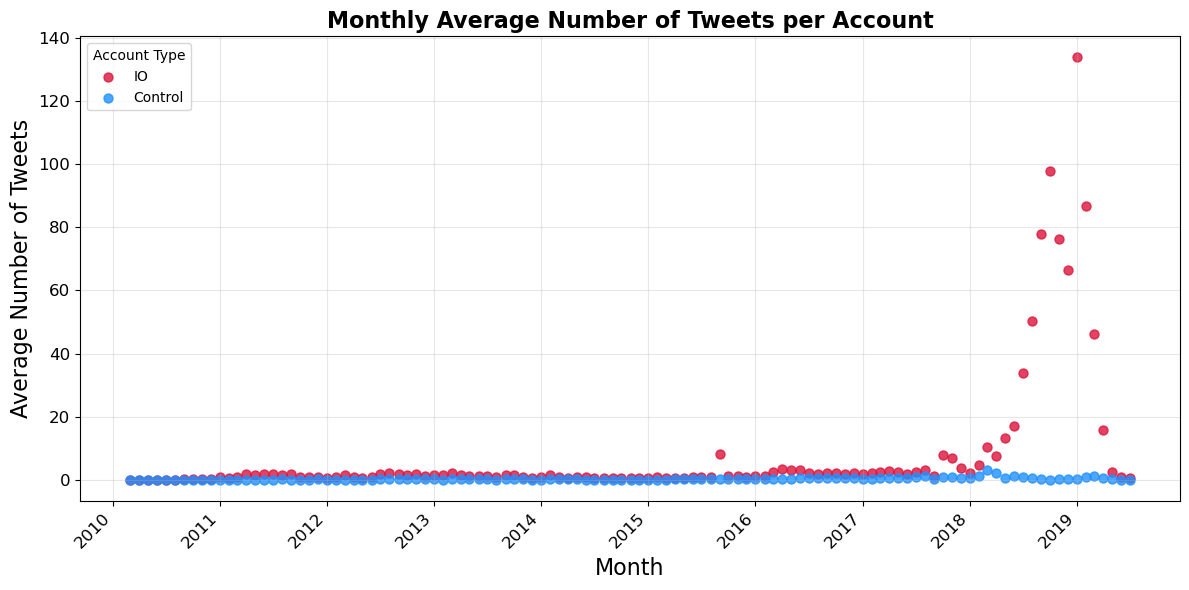

,month,account_type,n_posts,n_accounts,avg_posts_per_account
0,2010-03-01,IO,6,787,0.007624
1,2010-03-01,Control,0,21137,0.000000
2,2010-04-01,IO,14,787,0.017789
3,2010-04-01,Control,0,21137,0.000000
4,2010-05-01,IO,22,787,0.027954


In [16]:
if run_demo:
    io_control_monthly_avg_posts_df = plot_io_control_monthly_avg_tweets_scatter(
        df=df,
        author_col=account_id_col,
        is_control_col=is_io_control_col,
        timestamp_col=post_time_col,
        output_folder_path=folder_output_path,
    )
    display(io_control_monthly_avg_posts_df.head())

# TF-IDF Score

## Entities

TF-IDF Using *sklearn*

In [17]:
def normalize_entity(x: str) -> str:
    """Normalize a single entity string."""
    return re.sub(r"\s+", "_", str(x).lower().strip())


def normalize_entity_list(lst: Iterable[str]) -> List[str]:
    """Normalize a list of entity strings.

    Args:
        lst: Iterable of entity strings.

    Returns:
        List of normalized entity strings.
    """

    if isinstance(lst, str) or not isinstance(lst, list):
        raise TypeError(f"Expected a list of entities, got: {type(lst)} | value: {lst}")

    return [normalize_entity(x) for x in lst]

In [18]:
@report_done
def compute_entities_tfidf(
    df: pd.DataFrame,
    entity_col: str,
    topic_col: str = "BERTopic_topic",
) -> pd.DataFrame:
    """Compute entity TF-IDF by topic.

    This implementation avoids constructing large text documents,
    resulting in faster execution and lower memory usage.

    Args:
        df: Input DataFrame with topic labels and entity lists.
        entity_col: Column containing list-like entities per post.
        topic_col: Topic label column.

    Returns:
        DataFrame with rows=entities, columns=topics, values=tf-idf scores.
    """
    print(f"[compute_entities_tfidf] Topic column: {topic_col}, Entity column: {entity_col}")

    # # Normalize entities in the df (disabled since in parallel processing this is not the same df. this is done in compute_post_tfidf)
    # print(f"[compute_entities_tfidf] Normalizing entities in {entity_col} column.")
    # df[entity_col] = df[entity_col].map(
    #     lambda lst: [normalize_entity(x) for x in lst] if isinstance(lst, list) else lst
    # )

    # Explode to (topic, entity) pairs, drop rows with no entities
    df_exp = (
        df[[topic_col, entity_col]]
        .explode(entity_col)
        .dropna(subset=[entity_col])
        .reset_index(drop=True)
    )

    # Sparse count matrix: rows=topics, cols=entities, values=counts
    topic_entity_counts = pd.crosstab(
        df_exp[topic_col].to_numpy(),
        df_exp[entity_col].to_numpy(),
    )

    print(f"[compute_entities_tfidf] Topic-Entity count matrix shape: {topic_entity_counts.shape}")

    # Apply TF-IDF on the counts
    X_tfidf = TfidfTransformer().fit_transform(topic_entity_counts)

    # Build DataFrame where rows=entities, columns=topics, values=tf-idf scores
    entity_topic_df = pd.DataFrame.sparse.from_spmatrix(
        X_tfidf.T,
        index=topic_entity_counts.columns,
        columns=topic_entity_counts.index,
    )

    return entity_topic_df

In [19]:
if run_demo:
    hashtags_tfidf_df = compute_entities_tfidf(df, entity_col='hashtags', topic_col=topic_col)
    hashtags_tfidf_df.head()

[compute_entities_tfidf] Topic column: BERTopic_topic_256, Entity column: hashtags
[compute_entities_tfidf] Topic-Entity count matrix shape: (55, 164846)
2026-07-07 16:53:38 | Completed: compute_entities_tfidf


In [20]:
@report_done
def get_top_entities(entity_topic_df, topic_id, top_n=10):
    """
    Return a list of the top-N entities for a specific topic.

    Args:
        entity_topic_df (pd.DataFrame):
            Rows = entities, columns = topics ids, values = TF-IDF scores.
        topic_id (str | int):
            The topic.
        top_n (int):
            Number of top entities.

    Returns:
        list[str]: Top-N entities sorted by descending TF-IDF.
    """

    top_entities = entity_topic_df[topic_id].sort_values(ascending=False).head(top_n).index.tolist()

    return top_entities

In [21]:
if run_demo:
    topic_id = hashtags_tfidf_df.columns[2]  # example topic id, adjust as needed
    print(f"Top entities for topic {topic_id}:")
    top_entities = get_top_entities(hashtags_tfidf_df, topic_id = topic_id, top_n=10)
    print(top_entities)

Top entities for topic 1:
2026-07-07 16:53:38 | Completed: get_top_entities
['PREMIOSMTVMIAW', 'MTVINSTAARVIGNA', 'MTVINSTAARVICICONTE', 'MTVExPopLali', 'MTVCRUSHREYES', 'MTVEXPOPREYES', 'MTVHITCNCO', 'MTVINSTAMXDANNA', 'MTVEXPOPCNCO', 'MTVACTAPPCNCO']


## Posts

TF-IDF<sub>topic,post</sub> = ∑<sub>entity ∈ post</sub> TF-IDF<sub>topic,entity</sub>

In [22]:
import os

def _compute_one_entity_col_scores(
    df: pd.DataFrame,
    topic_col: str,
    entity_col: str,
) -> np.ndarray:
    """Compute per-row TF-IDF contribution for one entity column.

    Uses explode + merge + groupby and keeps only non-zero TF-IDF values.

    Args:
        df: Input DataFrame with topic and entity-list columns.
        topic_col: Topic column name.
        entity_col: Entity-list column name.

    Returns:
        Numpy array of per-row scores for this entity column.
    """

    pid = os.getpid()
    print(f"[_compute_one_entity_col_scores] PID {pid}: Calculating scores for {entity_col}")

    # Keep only needed columns.
    df_local = df[[topic_col, entity_col]].copy()

    # TF-IDF table: rows=entities, columns=topics, values=tf-idf
    entities_tfidf_df = compute_entities_tfidf(df_local, entity_col, topic_col)

    print(f"[_compute_one_entity_col_scores] PID {pid}: exploding + merging {entity_col}")

    # Convert sparse DataFrame to long table of non-zero scores only.
    coo = entities_tfidf_df.sparse.to_coo()
    scores_long = pd.DataFrame(
        {
            entity_col: entities_tfidf_df.index.to_numpy()[coo.row], # entities_tfidf_df contains the names, coo.row is the indexes for non-zero values
            topic_col: entities_tfidf_df.columns.to_numpy()[coo.col],
            "score": coo.data,
        }
    )

    # One row per original row/entity pair.
    exploded = (
        # reset_index put the original row ids in "row_id" column.
        df_local.reset_index(names="row_id")
        .explode(entity_col)
        .dropna(subset=[entity_col])
        .reset_index(drop=True)
    )

    merged = exploded.merge(
        scores_long,
        on=[entity_col, topic_col],
        how="left",
    )

    # row_scores.index is the original row ids.
    # In sum() Nam=0 so missing matches mean score 0.
    row_scores = merged.groupby("row_id", sort=False)["score"].sum()

    col_scores = np.zeros(len(df_local), dtype=float)
    col_scores[row_scores.index.to_numpy()] = row_scores.to_numpy() 

    print(f"[_compute_one_entity_col_scores] PID {pid}: done {entity_col}")
    return col_scores

In [23]:
from concurrent.futures import ProcessPoolExecutor
import os

@report_done
def compute_post_tfidf(
    df: pd.DataFrame,
    topic_col: str,
    entity_cols_lst: list[str],
    post_score_col: str = "post_tfidf",
    max_workers: int | None = None,
) -> None:
    """Compute per-post TF-IDF scores from multiple entity columns in parallel.

    Updates df[post_score_col] in place.

    Args:
        df: Input DataFrame.
        topic_col: Topic column name.
        entity_cols_lst: Entity-list column names.
        post_score_col: Output score column name.
        max_workers: Number of worker processes.

    Returns:
        None.
    """
    print(
        f"[compute_post_tfidf] Topic column: {topic_col}, "
        f"Entity columns: {entity_cols_lst}\n"
    )


    # normalize entities in all entity columns before parallel processing
    for ent_col in entity_cols_lst:
        print(f"[compute_post_tfidf] Normalizing entities in {ent_col} column.")
        df[ent_col] = df[ent_col].map(
            lambda lst: [normalize_entity(x) for x in lst] if isinstance(lst, list) else lst
        )

    
    # parameters for parallel processing
    min_df_list = [df[[ent_col, topic_col]].copy() for ent_col in entity_cols_lst]
    if max_workers is None:
        max_workers=min(len(entity_cols_lst), os.cpu_count() or 1)
        
    # parallel processing
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        print(f"[compute_post_tfidf] Computing TF-IDF scores for each entity column in parallel with {max_workers} workers...")
        results = list(
            tqdm(
                executor.map(
                    _compute_one_entity_col_scores,
                    min_df_list,
                    [topic_col] * len(entity_cols_lst),
                    entity_cols_lst,
                ),
                total=len(entity_cols_lst),
                desc="[compute_post_tfidf] Entity columns",
            )
        )
    

    print("[compute_post_tfidf] Combining scores from all entity columns...")
    total_scores = np.zeros(len(df), dtype=float)
    for col_scores in results:
        total_scores += col_scores

    df[post_score_col] = total_scores

In [24]:
if run_demo:
    compute_post_tfidf(df, topic_col, entity_cols_lst)
    print(f"### Finished [compute_post_tfidf] ###")
    display(df[["post_text", "post_tfidf", topic_col]].head())

[compute_post_tfidf] Topic column: BERTopic_topic_256, Entity columns: ['hashtags', 'account_mentions', 'ner_entities']

[compute_post_tfidf] Normalizing entities in hashtags column.
[compute_post_tfidf] Normalizing entities in account_mentions column.
[compute_post_tfidf] Normalizing entities in ner_entities column.
[compute_post_tfidf] Computing TF-IDF scores for each entity column in parallel with 3 workers...


[compute_post_tfidf] Entity columns:   0%|          | 0/3 [00:00<?, ?it/s]

[_compute_one_entity_col_scores] PID 2010667: Calculating scores for hashtags
[compute_entities_tfidf] Topic column: BERTopic_topic_256, Entity column: hashtags
[compute_entities_tfidf] Topic-Entity count matrix shape: (55, 164846)
2026-07-07 16:53:59 | Completed: compute_entities_tfidf
[_compute_one_entity_col_scores] PID 2010667: exploding + merging hashtags
[_compute_one_entity_col_scores] PID 2010667: done hashtags
[_compute_one_entity_col_scores] PID 2010668: Calculating scores for account_mentions
[compute_entities_tfidf] Topic column: BERTopic_topic_256, Entity column: account_mentions


[compute_post_tfidf] Entity columns:  33%|███▎      | 1/3 [00:19<00:39, 19.69s/it]

[compute_entities_tfidf] Topic-Entity count matrix shape: (55, 271772)
2026-07-07 16:54:13 | Completed: compute_entities_tfidf
[_compute_one_entity_col_scores] PID 2010668: exploding + merging account_mentions
[_compute_one_entity_col_scores] PID 2010669: Calculating scores for ner_entities
[compute_entities_tfidf] Topic column: BERTopic_topic_256, Entity column: ner_entities
[_compute_one_entity_col_scores] PID 2010668: done account_mentions


[compute_post_tfidf] Entity columns:  67%|██████▋   | 2/3 [00:25<00:11, 11.62s/it]

[compute_entities_tfidf] Topic-Entity count matrix shape: (55, 169685)
2026-07-07 16:54:19 | Completed: compute_entities_tfidf
[_compute_one_entity_col_scores] PID 2010669: exploding + merging ner_entities
[_compute_one_entity_col_scores] PID 2010669: done ner_entities


[compute_post_tfidf] Entity columns: 100%|██████████| 3/3 [00:31<00:00, 10.39s/it]


[compute_post_tfidf] Combining scores from all entity columns...
2026-07-07 16:54:21 | Completed: compute_post_tfidf
### Finished [compute_post_tfidf] ###


,post_text,post_tfidf,BERTopic_topic_256
0,Vamos a cambiar la forma de hacer comunicación...,0.000000,0
1,"Damos servicio de manejo de prensa, elaboració...",0.000000,0
2,@db7c47cef2aa2ba68b5c010d761a03fc1c0f0d1302 Bu...,0.001447,0
3,"Mario, debemos denuciar que en los poderes pub...",0.021874,0
4,Tambien debemos estar claro que la oposición e...,0.000000,0


In [25]:
if run_demo:
    save_df(df, folder_output_path, file_name)

2026-07-07 16:55:43 | df is saved to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/processed_Ecuador_part_all.gzip.parquet


## Authors

*(a = author, t= topic, p = post)*

TF<sub>a, t</sub> = ∑ <sub> p ∈ authors's posts in topic</sub> tfidf_score<sub>p, t</sub>

IDF<sub>a</sub> = log((|all_topics| + offset) / (|author's_topics| + offset))

TF-IDF<sub>a,t</sub> = TF<sub>a, t</sub> * IDF<sub>a</sub>

In [26]:
@report_done
def compute_author_key_score(
    df: pd.DataFrame,
    topic_col: str = "BERTopic_topic",
    author_col: str = "accountid",
    post_score_col: str = "post_tfidf",
    author_score_col: str = "topic_author_key_score",
    use_log_idf: bool = True,
    idf_offset: float = 1.0,
    folder_output_path: Path = None,
) -> pd.DataFrame:
    """Compute author-topic TF-IDF and write each post's score to df.
    IDF is computed by the authors using entities (so posts without entities are not counted).

    TF = sum of post scores per (author, topic).
    IDF = penalizes authors active in many topics.
    Output column contains TF-IDF(author, topic) for each post.

    Args:
        df: Input DataFrame with posts.
        topic_col: Topic column name.
        author_col: Author column name.
        post_score_col: Per-post score column.
        author_score_col: Column to store the computed author-topic scores.
        use_log_idf: Apply log to IDF.
        idf_offset: Smoothing constant.
        folder_output_path: If given, save the author-topic TF-IDF matrix to this path.

    Returns:
        author_topic_key_score_df (rows = authors, columns = topics, values = author-topic score)

    """

    print(
        f"[compute_author_key_score] "
        f"topic_col={topic_col}, "
        f"author_col={author_col}, "
        f"post_score_col={post_score_col}, "
        f"author_score_col={author_score_col}"
    )
    
    # TF matrix: rows = authors, columns = topics, values = tf score
    author_topic_tf = (
        df.groupby([author_col, topic_col])[post_score_col]
        .sum()
        .unstack(fill_value=0)
    )

    # IDF per author
    n_topics = author_topic_tf.shape[1]
    topics_per_author = (author_topic_tf > 0).sum(axis=1)
    idf = (n_topics + idf_offset) / (topics_per_author + idf_offset)
    if use_log_idf:
        idf = np.log(idf)

    # TF-IDF matrix
    author_topic_key_score_df = author_topic_tf.mul(idf, axis=0)

    # Assign TF-IDF(author, topic) to each post
    score_lookup = author_topic_key_score_df.stack() # MultiSeries with index=(author, topic) and value=score

    df[author_score_col] = score_lookup.reindex(list(zip(df[author_col], df[topic_col]))).to_numpy()
    # df[author_score_col] = df.apply(
    #     # Pandas aligns by row index = author.
    #     lambda row: author_topic_key_score_df.loc[row[author_col], row[topic_col]],
    #     axis=1,
    # )

    # save
    if folder_output_path is not None:
        author_topic_key_score_df.to_parquet(folder_output_path / f"author_topic_key_score_by_{topic_col}.parquet", compression="gzip")
        print(f"[compute_author_key_score] Saved author-topic key score matrix to: {folder_output_path / f'author_topic_key_score_by_{topic_col}.parquet'}")

    return author_topic_key_score_df

In [27]:
if run_demo:
    author_topic_key_score_df = compute_author_key_score(df, topic_col = topic_col, folder_output_path=folder_output_path)
    author_topic_key_score_df.head()

[compute_author_key_score] topic_col=BERTopic_topic_256, author_col=accountid, post_score_col=post_tfidf, author_score_col=topic_author_key_score
[compute_author_key_score] Saved author-topic key score matrix to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/author_topic_key_score_by_BERTopic_topic_256.parquet
2026-07-07 16:55:46 | Completed: compute_author_key_score


In [28]:
# # TODO: to delete

# # loading from disk
# author_topic_key_score_df = pd.read_parquet("../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_04_15/author_topic_key_score_by_BERTopic_topic_256.parquet")

# df["topic_author_key_score"] = df.apply(
#         # Pandas aligns by row index = author.
#         lambda row: author_topic_key_score_df.loc[row[account_id_col], row[topic_col]],
#         axis=1,
#     )

# Key Authors

In [29]:
@report_done
def get_topic_top_authors(
    df: pd.DataFrame,
    topic: str | int,
    score_col: str = "topic_author_key_score",
    author_col: str = "accountid",
    topic_col: str = "BERTopic_topic",
    n: int = 100,
) -> set:
    """Return the top-n authors for a given topic based on author-topic scores.

    The author-topic score is assumed to be precomputed. Each author is
    considered once per topic; repeated posts do not increase the score.

    Args:
        df: DataFrame containing posts with author-topic scores.
        topic: Topic to extract top authors for.
        score_col: Column storing author-topic scores.
        author_col: Column storing author identifiers.
        topic_col: Column storing topic labels.
        n: Number of top authors to return.

    Returns:
        set: Authors ranked in the top-n for the given topic.
    """

    print(f"[get_topic_top_authors] Using topic column: {topic_col}")

    top_authors = (
        df.loc[df[topic_col] == topic, [author_col, score_col]]
        .dropna(subset=[author_col, score_col])
        .drop_duplicates(author_col)     # one row per author
        .sort_values(score_col, ascending=False)
        .head(n)[author_col]
    )

    topic_key_authors = set(top_authors)

    print(f"[get_topic_top_authors] There are {len(topic_key_authors)} unique key authors in topic {topic}.")

    return topic_key_authors

In [30]:
if run_demo:
    get_topic_top_authors(df, topic=1, topic_col = topic_col)

[get_topic_top_authors] Using topic column: BERTopic_topic_256
[get_topic_top_authors] There are 100 unique key authors in topic 1.
2026-07-07 16:55:46 | Completed: get_topic_top_authors


In [31]:
@report_done
def get_all_topics_key_authors(
    df: pd.DataFrame,
    author_score_col: str = "topic_author_key_score",
    author_col: str = "accountid",
    topic_col: str | None =  None, # just for per topic mode, global mode will ignore this column
    key_authors_mode: str = "per_topic",
    base_number: int = 5,
    top_percentage: float | int= 0.1,
) -> set:
    """Return key authors selected by global or per-topic TF-IDF ranking.

    Modes:
        - "per_topic": For each topic, select base_number + top_percentage * (authors in topic).
        - "global":    Rank authors by their total TF-IDF sum across all topics,
                       select the top top_percentage fraction.

    Args:
        df: DataFrame with author-topic TF-IDF scores.
        author_score_col: Column storing TF-IDF(author, topic).
        author_col: Column storing author IDs.
        topic_col: Column storing topic labels.
        key_authors_mode: "per_topic" or "global".
        base_number: initial number authors per topic (per_topic mode only).
        top_percentage: Fraction of authors to select (0-1).

    Returns:
        set: Unique key-author IDs.
    """
    # Normalize mode string
    mode = key_authors_mode.strip().lower().replace(" ", "_")
    assert mode in ("per_topic", "global"), f"Invalid mode: {key_authors_mode!r}. Use 'per_topic' or 'global'."

    if top_percentage > 1:
        print(f"[get_all_topics_key_authors] WARNING: top_percentage {top_percentage} is > 1. Interpreting as {top_percentage:.2%}.")
        top_percentage = float(top_percentage) / 100

    assert 0 <= top_percentage <= 1, f"top_percentage must be in the range [0, 1], got {top_percentage}."

    if top_percentage == 1:
        write_report(f"[get_all_topics_key_authors] top_percentage is 100%, so all authors will be selected as key authors.")
    
    print(f"[get_all_topics_key_authors] Mode: {mode}, Top percentage: {top_percentage:.2%}, author_score_col: {author_score_col}, author_col: {author_col}")
    if mode == "per_topic":
        print(f"[get_all_topics_key_authors] Using topic column {topic_col}, Base number: {base_number}")
        columns_to_use = [topic_col, author_col, author_score_col]
    else:
        columns_to_use = [author_col, author_score_col]
 

    # Clean base table: one row per (topic, author) with their score
    base = (
        df[columns_to_use]
        .dropna()
        .drop_duplicates()
        .reset_index(drop=True)
    )

    if mode == "global":

        # Rank authors by total TF-IDF sum across all topics
        author_total_tfidf = base.groupby(author_col)[author_score_col].sum()
        n_select = int(top_percentage * len(author_total_tfidf))
        selected_authors_set = set(author_total_tfidf.nlargest(n_select).index)

    else:  # per_topic

        assert topic_col is not None, "topic_col must be provided in per_topic mode."

        # Dynamic threshold per topic: base_number + top_percentage * authors_in_topic
        topic_sizes = base.groupby(topic_col)[author_col].nunique()
        topics_thresholds = (base_number + (top_percentage * topic_sizes).astype(int)).to_dict()

        selected_authors_set = set()

        for topic, group in base.groupby(topic_col, sort=False):
            n_select = topics_thresholds[topic]
            selected_authors_set.update(group.nlargest(n_select, author_score_col)[author_col])

    print(f"[get_all_topics_key_authors] There are {len(selected_authors_set):,} unique key/boost authors in all topics.")

    return selected_authors_set


In [32]:
# --- Key-author selection mode ---
# "per_topic": base_number + top_percentage * (authors in topic), per topic.
# "global":    top_percentage of all authors ranked by total TF-IDF.

if run_demo:
    key_authors_mode = "per_topic"
    base_number = 10           # minimum authors per topic  (per_topic mode)

    all_topics_key_authors_set = get_all_topics_key_authors(
        df=df,
        topic_col=topic_col,
        key_authors_mode=key_authors_mode,
        base_number=base_number,
        top_percentage=top_percentage,
    )

[get_all_topics_key_authors] Mode: per_topic, Top percentage: 1.00%, author_score_col: topic_author_key_score, author_col: accountid
[get_all_topics_key_authors] Using topic column BERTopic_topic_256, Base number: 10
[get_all_topics_key_authors] There are 1,438 unique key/boost authors in all topics.
2026-07-07 16:55:46 | Completed: get_all_topics_key_authors


# Boost Authors


Loading result only
See the relevant netbook for more information.

In [33]:
boost_csv_path = "../results/labeled_datasets/Ecuador/boost_merged_global.csv"

In [34]:
@report_done
def load_boost_scores(boost_csv_path: str, all_authors_set: None | set = None, author_col: str = "accountid") -> pd.DataFrame:
        """Load boost scores from CSV, ensuring one row per author."""
        boost_df = pd.read_csv(boost_csv_path).drop_duplicates(subset=[author_col])
        boost_df[author_col] = boost_df[author_col].astype(str)
        if all_authors_set is not None:
            boost_df = boost_df[boost_df[author_col].isin(all_authors_set)]
            print(f"[load_boost_scores] Filtered boost scores to {len(boost_df):,} authors present in the dataset.")
        print(f"[load_boost_scores] Loaded {len(boost_df):,} unique authors from: {boost_csv_path}\n")
        print(f"[load_boost_scores] dtypes: {boost_df.dtypes}\n")
        
        return boost_df

In [35]:
if use_boost_authors and run_demo:
    all_authors_set = set(df[account_id_col].unique())
    boost_df = load_boost_scores(boost_csv_path, all_authors_set=all_authors_set, author_col=account_id_col)

    # Select the top 50% of authors by boost_score (global mode, no topic column needed)
    boost_authors_set = get_all_topics_key_authors(
        df=boost_df,
        author_col= account_id_col,
        author_score_col="boost_score",
        key_authors_mode="global", # must me global since boost scores are not topic-specific
        top_percentage=top_percentage,
    )
else:
    print(f"Boost authors will not be used. Set use_boost_authors=True to enable.")
    boost_authors_set = set()
    boost_df = None


Boost authors will not be used. Set use_boost_authors=True to enable.


# IO Authors

In [36]:
import json
from pathlib import Path

@report_done
def get_io_authors_by_ratio(
    df: pd.DataFrame,
    author_col: str = "accountid",
    is_io_control_col: str = "is_control",
    io_threshold: float = 0.33,
    min_posts: int = 0,
    folder_output_path: str | Path | None = None,
) -> set:
    """Return authors classified as IO based on IO-post ratio.

    Args:
        df: Posts DataFrame.
        author_col: Column with author IDs.
        is_io_control_col: Column where 1=control (non-IO), 0=IO.
        io_threshold: Minimum IO ratio to tag an author as IO.
        min_posts: Minimum number of posts per author.
        folder_output_path: Optional path to save output files.

    Returns:
        set: Author IDs tagged as IO.
    """
    grouped = df.groupby(author_col)[is_io_control_col]

    author_stats = pd.DataFrame({
        "total_posts": grouped.count(),
        "io_ratio": 1 - grouped.mean(),
    })

    author_io_set = set(
        author_stats[
            (author_stats["total_posts"] >= min_posts)
            & (author_stats["io_ratio"] >= io_threshold)
        ].index
    )

    author_io_set = set(map(str, author_io_set))

    print(f"[get_io_authors_by_ratio] There are {len(author_io_set)} IO authors.")

    if folder_output_path is not None:

        folder_output_path = Path(folder_output_path)
        set_path = folder_output_path / "author_io_set.json"

        with open(set_path, "w", encoding="utf-8") as f:
            json.dump(sorted(author_io_set), f, ensure_ascii=False, indent=2)

        print(f"Saved IO authors set to: {set_path}")

    return author_io_set

In [37]:
if run_demo:
    io_authors_set = get_io_authors_by_ratio(df, folder_output_path = folder_output_path)

[get_io_authors_by_ratio] There are 787 IO authors.
Saved IO authors set to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/author_io_set.json
2026-07-07 16:55:46 | Completed: get_io_authors_by_ratio


# Key, IO, Boost Authors

In [38]:
if run_demo:
    boost_and_key_authors_union_set = boost_authors_set.union(all_topics_key_authors_set)

## Summary

In [39]:
@report_done
def save_and_print_io_key_summary(
    df,
    io_authors_set : set,
    all_topics_key_authors_set : set,
    boost_authors_set : set,
    output_path: str | Path,
    author_col: str = "accountid",
):
    """Print and save summary statistics for IO / key authors."""

    if len(boost_authors_set) == 0:
        print("[save_and_print_io_key_summary] WARNING: No boost_authors_set found. If not expected set use_boost_authors to True.")

    both_io_and_key = io_authors_set & all_topics_key_authors_set
    pct_io_also_key = (len(both_io_and_key) / len(io_authors_set) * 100 if len(io_authors_set) > 0 else 0)

    all_authors_set = set(df[author_col].astype(str).drop_duplicates())

    summary_text = (
        "### io_key_summary ###\n"
        "\n"
        f"Number of all authors: {len(all_authors_set):,}\n"
        "\n"
        f"Number of IO authors: {len(io_authors_set):,} ({100 * len(io_authors_set) / len(all_authors_set):.1f}% of all authors)\n"
        f"Number of key authors: {len(all_topics_key_authors_set):,} ({100 * len(all_topics_key_authors_set) / len(all_authors_set):.1f}% of all authors)\n"
        f"Number of boost authors: {len(boost_authors_set):,} ({100 * len(boost_authors_set) / len(all_authors_set):.1f}% of all authors)\n"
        "\n"
        f"Number of authors that are both IO and key: {len(both_io_and_key):,}\n"
        f"{pct_io_also_key:.1f}% of IO authors are also key authors\n"
    )

    # print to console
    print(summary_text)

    # save to text file
    output_path = Path(output_path)
    summary_file_path = output_path / "io_key_authors_summary.txt"
    with open(summary_file_path, "w", encoding="utf-8") as f:
        f.write(summary_text)

    print(f"Saved summary to: {summary_file_path}")

    return None

In [40]:
# venn is better

if run_demo:
    print(f"Using topic column: {topic_col}")
    save_and_print_io_key_summary(df = df, io_authors_set = io_authors_set, all_topics_key_authors_set = all_topics_key_authors_set, boost_authors_set=boost_authors_set, output_path = folder_output_path)

Using topic column: BERTopic_topic_256
[save_and_print_io_key_summary] WARNING: No boost_authors_set found. If not expected set use_boost_authors to True.
### io_key_summary ###

Number of all authors: 21,923

Number of IO authors: 787 (3.6% of all authors)
Number of key authors: 1,438 (6.6% of all authors)
Number of boost authors: 0 (0.0% of all authors)

Number of authors that are both IO and key: 243
30.9% of IO authors are also key authors

Saved summary to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_key_authors_summary.txt
2026-07-07 16:55:46 | Completed: save_and_print_io_key_summary


## Venn Plot

In [41]:
@report_done
def plot_venn_3_sets(
    set_a: set,
    set_b: set,
    set_c: set,
    set_labels: tuple[str, str, str],
    title: str = "Venn Diagram",
    folder_output_path: str | Path = None,
) -> None:
    """Plot a 3-set Venn diagram for author subsets.

    Args:
        set_a: set
        set_b: set
        set_c: set
        title: Figure title.
        set_labels: Labels for the three sets (A, B, C) in the diagram.
    """
    # Normalize to strings for consistent overlap
    A = set(map(str, set_a))
    B = set(map(str, set_b))
    C = set(map(str, set_c))

    plt.figure(figsize=(7, 6))
    v = venn3(
        subsets=(A, B, C),
        set_labels=set_labels,
        set_colors=(
        "#6081B5",  # set_a
        "#AA6B0C",  # set_b 
        "#9E4950",  # set_c
    ),
        alpha=0.8,
    )

    # Format numbers with comma separator
    for subset_id in ('100', '010', '001', '110', '101', '011', '111'):
        label = v.get_label_by_id(subset_id)
        if label is not None:
            value = int(label.get_text())
            label.set_text(f"{value:,}")


    plt.title(title)
    plt.tight_layout()


    # Save figure
    if folder_output_path is not None:
        file_name = re.sub(r"_+", "_", re.sub(r"[^a-z0-9_]", "", title.lower().replace(" ", "_"))) + ".png"
        folder_output_path = Path(folder_output_path)
        venn_path = folder_output_path / file_name
        plt.savefig(venn_path, dpi=300)
        print(f"Saved fig to: {venn_path}")

    plt.show()
    plt.close()

In [42]:
if run_demo:
    all_authors_set = set(df[account_id_col].astype(str).drop_duplicates())

Using topic column: BERTopic_topic_256
Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/authors_overlap_all_key_io_bertopic_topic_256_top_percentage_001.png


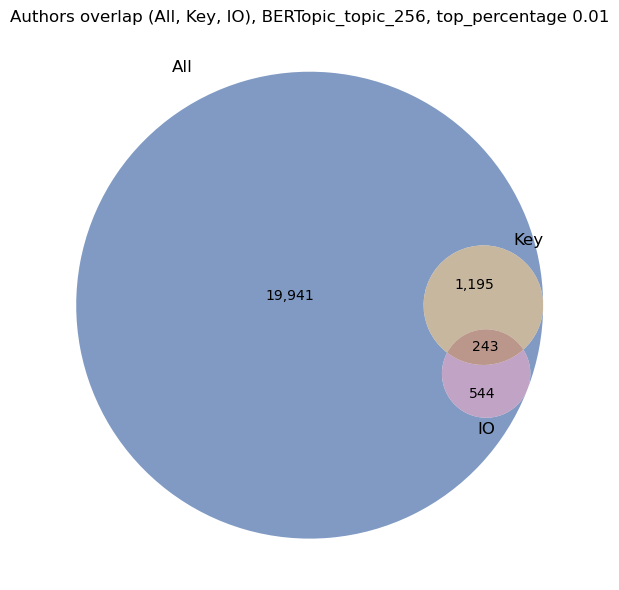

2026-07-07 16:55:47 | Completed: plot_venn_3_sets


In [43]:
# ven for ("All", "Key", "IO"),

if run_demo:

    print(f"Using topic column: {topic_col}")
    plot_venn_3_sets(
        set_a=all_authors_set,
        set_b=all_topics_key_authors_set,
        set_c=io_authors_set,
        title=f"Authors overlap (All, Key, IO), {topic_col}, top_percentage {top_percentage}",
        set_labels=("All", "Key", "IO"),
        folder_output_path=folder_output_path,
    )

In [44]:
# ven for ("Key", "IO", "Boost"),

if run_demo and use_boost_authors:

    print(f"Using topic column: {topic_col}")
    plot_venn_3_sets(
        set_a=all_topics_key_authors_set,
        set_b=io_authors_set,
        set_c=boost_authors_set,
        title=f"Authors overlap (Key, IO, Boost), top_percentage {top_percentage}",
        set_labels=("Key", "IO", "Boost"),
        folder_output_path=folder_output_path,
    )

## Ven Plot By Top Percentage

In [45]:
def all_key_io_ven_plot_by_top_percentage(
    df,
    top_percentage: float,
    topic_col: str,
    folder_output_path: str | Path = None,
    is_io_control_col: str = "is_control",
    key_authors_mode: str = "per_topic",
    account_id_col: str = "accountid",
) -> None:
    """Plot Venn diagram of all authors, key authors, and IO authors."""

    # print
    print(
        "[all_key_io_ven_plot_by_top_percentage] "
        f"Plotting Venn diagram for top percentage: {top_percentage} "
        f",topic column: {topic_col} "
        f"and key authors mode: {key_authors_mode}"
    )

    # all_authors_set
    print(f"[all_key_io_ven_plot_by_top_percentage] Calculating all_authors_set")
    all_authors_set = set(df[account_id_col].astype(str).drop_duplicates())

    # io_authors_set
    print(f"[all_key_io_ven_plot_by_top_percentage] Calculating io_authors_set")
    io_authors_set = get_io_authors_by_ratio(
        df=df,
        author_col=account_id_col,
        is_io_control_col=is_io_control_col,
    )

    # key_authors_set
    print(f"[all_key_io_ven_plot_by_top_percentage] Calculating key_authors_set")
    all_topics_key_authors_set = get_all_topics_key_authors(
        df=df,
        topic_col=topic_col,
        key_authors_mode=key_authors_mode,
        top_percentage=top_percentage,
    )

    # venn plot
    print(f"[all_key_io_ven_plot_by_top_percentage] Plotting Venn diagram")
    plot_venn_3_sets(
        set_a=all_authors_set,
        set_b=all_topics_key_authors_set,
        set_c=io_authors_set,
        title=(
            f"Authors overlap (All, Key, IO), "
            f"{topic_col}, top {top_percentage:.0%}"
        ),
        set_labels=("All", "Key", "IO"),
        folder_output_path=folder_output_path,
    )

[all_key_io_ven_plot_by_top_percentage] Plotting Venn diagram for top percentage: 0.01 ,topic column: BERTopic_topic_256 and key authors mode: per_topic
[all_key_io_ven_plot_by_top_percentage] Calculating all_authors_set
[all_key_io_ven_plot_by_top_percentage] Calculating io_authors_set
[get_io_authors_by_ratio] There are 787 IO authors.
2026-07-07 16:55:47 | Completed: get_io_authors_by_ratio
[all_key_io_ven_plot_by_top_percentage] Calculating key_authors_set
[get_all_topics_key_authors] Mode: per_topic, Top percentage: 1.00%, author_score_col: topic_author_key_score, author_col: accountid
[get_all_topics_key_authors] Using topic column BERTopic_topic_256, Base number: 5
[get_all_topics_key_authors] There are 1,254 unique key/boost authors in all topics.
2026-07-07 16:55:47 | Completed: get_all_topics_key_authors
[all_key_io_ven_plot_by_top_percentage] Plotting Venn diagram


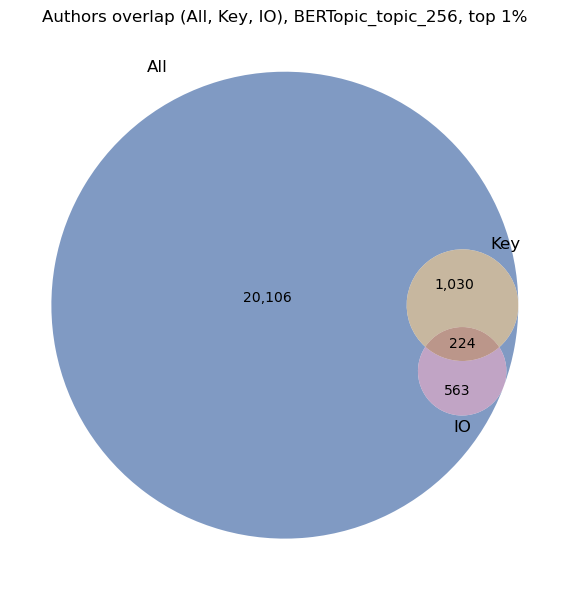

2026-07-07 16:55:47 | Completed: plot_venn_3_sets


In [46]:
if run_demo:
    all_key_io_ven_plot_by_top_percentage(df =df, top_percentage=0.01, topic_col=topic_col)

## IO Rates by Top Percentages

In [47]:
def plot_key_author_rates_by_top_percentage(
    df,
    top_percentages: list[float],
    topic_col: str,
    folder_output_path: str | Path = None,
    is_io_control_col: str = "is_control",
    key_authors_mode: str = "per_topic",
    account_id_col: str = "accountid",
) -> pd.DataFrame:
    """Plot key-author coverage rates across top percentages."""


    # print
    print(
        "[plot_key_author_rates_by_top_percentage] "
        f"Plotting rates for top percentages: {top_percentages} "
        f",topic column: {topic_col} "
        f"and key authors mode: {key_authors_mode}"
    )
    
    # all authors set
    print("[plot_key_author_rates_by_top_percentage] Calculating all_authors_set")
    all_authors_set = set(df[account_id_col].astype(str).drop_duplicates())

    # io authors set
    print("[plot_key_author_rates_by_top_percentage] Calculating io_authors_set")
    io_authors_set = get_io_authors_by_ratio(
        df=df,
        author_col=account_id_col,
        is_io_control_col=is_io_control_col,
    )
    io_authors_set = set(map(str, io_authors_set))


    rows = []

    for top_percentage in top_percentages:
        print(
            "[plot_key_author_rates_by_top_percentage] "
            f"Calculating key authors for top percentage: {top_percentage}"
        )

        key_authors_set = get_all_topics_key_authors(
            df=df,
            topic_col=topic_col,
            key_authors_mode=key_authors_mode,
            top_percentage=top_percentage,
        )
        key_authors_set = set(map(str, key_authors_set))

        rows.append({
            "top_percentage": top_percentage,
            "key_in_all_rate": len(all_authors_set & key_authors_set) / len(all_authors_set),
            "key_io_in_io": len(io_authors_set & key_authors_set) / len(io_authors_set),
        })

    rates_df = pd.DataFrame(rows)

    print("[plot_key_author_rates_by_top_percentage] Plotting rates")
    plt.figure(figsize=(10, 6))

    plt.plot(
        rates_df["top_percentage"] * 100,
        rates_df["key_in_all_rate"] * 100,
        marker="o",
        label="Key authors / All authors",
    )

    plt.plot(
        rates_df["top_percentage"] * 100,
        rates_df["key_io_in_io"] * 100,
        marker="o",
        label="Key IO authors / IO authors",
    )

    plt.xlabel("Top percentage", fontsize=16)
    plt.ylabel("Rate (%)", fontsize=16)
    plt.title(f"Key Author Coverage by Top Percentage ({topic_col})", fontsize=18)
    plt.legend()
    plt.grid(alpha=0.3)

    if folder_output_path is not None:
        folder_output_path = Path(folder_output_path)
        output_path = folder_output_path / (
            f"key_author_rates_by_top_percentage_{topic_col}_{key_authors_mode}.png"
        )
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"[plot_key_author_rates_by_top_percentage] Saved plot to: {output_path}")

    plt.show()
    plt.close()

    return rates_df

[plot_key_author_rates_by_top_percentage] Plotting rates for top percentages: [0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95] ,topic column: BERTopic_topic_256 and key authors mode: per_topic
[plot_key_author_rates_by_top_percentage] Calculating all_authors_set
[plot_key_author_rates_by_top_percentage] Calculating io_authors_set
[get_io_authors_by_ratio] There are 787 IO authors.
2026-07-07 16:55:47 | Completed: get_io_authors_by_ratio
[plot_key_author_rates_by_top_percentage] Calculating key authors for top percentage: 0.005
[get_all_topics_key_authors] Mode: per_topic, Top percentage: 0.50%, author_score_col: topic_author_key_score, author_col: accountid
[get_all_topics_key_authors] Using topic column BERTopic_topic_256, Base number: 5
[get_all_topics_key_authors] There are 762 unique key/boost authors in all topics.
2026-07-07 16:55:47 | Completed: get_all_topics_key_authors
[plot_key_author_rates_by_top_percentage] Calculating key authors for top percentage: 

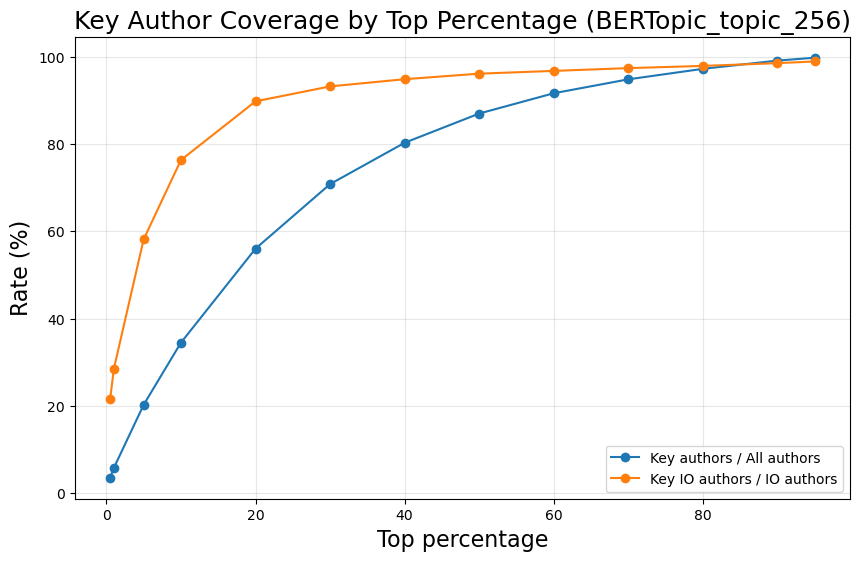

,top_percentage,key_in_all_rate,key_io_in_io
0,0.005,0.034758,0.214740
1,0.010,0.057200,0.284625
2,0.050,0.202208,0.581957
3,0.100,0.344706,0.763659
4,0.200,0.560325,0.898348
5,0.300,0.708434,0.932656
6,0.400,0.803312,0.949174
7,0.500,0.870364,0.961881
8,0.600,0.916937,0.968234
9,0.700,0.948866,0.974587


In [48]:
if run_demo:
    top_percentages = [0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
    rates_df = plot_key_author_rates_by_top_percentage(
        df=df,
        top_percentages=top_percentages,
        topic_col=topic_col,
        folder_output_path=folder_output_path,
        key_authors_mode="per_topic",
    )
    display(rates_df)

# Networkx Graphs

## Parameters

In [49]:
account_relations = [
    # (src_col, dst_col)
    ("in_reply_to_accountid", "accountid"),
    ("account_mentions", "accountid"),
    ("reposted_accountid", "accountid"),

    ("hashtags_reuse_12H_accountids", "accountid"),
    # ("urls_reuse_12H_accountids", "accountid"),
    ("account_mentions_reuse_12H_accountids", "accountid"),
    # ("ner_entities_reuse_12H_accountids", "accountid"), # not use NER to avoid using text features
    
    ("hashtags_reuse_3D_accountids", "accountid"),
    # ("urls_reuse_3D_accountids", "accountid"),
    ("account_mentions_reuse_3D_accountids", "accountid"),
    # ("ner_entities_reuse_3D_accountids", "accountid") # not use NER to avoid using text features

    # text similarity, not implemented
]


similarity_account_relations = [
    # (src_col, dst_col)
    ("hashtags_reuse_12H_accountids", "accountid"),
    # ("urls_reuse_12H_accountids", "accountid"),
    ("account_mentions_reuse_12H_accountids", "accountid"),
    # ("ner_entities_reuse_12H_accountids", "accountid"), # not use NER to avoid using text features
    
    ("hashtags_reuse_3D_accountids", "accountid"),
    # ("urls_reuse_3D_accountids", "accountid"),
    ("account_mentions_reuse_3D_accountids", "accountid"),
    # ("ner_entities_reuse_3D_accountids", "accountid") # not use NER to avoid using text features

    # text similarity, not implemented
]


interactions_account_relations = [
    # (src_col, dst_col)
    ("in_reply_to_accountid", "accountid"),
    ("account_mentions", "accountid"),
    ("reposted_accountid", "accountid"),
]

## Build Account ↔ Account Graph

### Add Edges

In [50]:
def add_relation_edges(
    G: nx.Graph,
    df: pd.DataFrame,
    src_col: str,
    dst_col: str,
    weight: int = 1,
    ignore_self_loops: bool = True,
    all_topics_key_authors_set: set | None = None,  # if given, only add edges where both src and dst are in this set
    post_time_col: str = "post_time",
) -> None:
    """Add weighted edges to a graph from co-occurrence counts of (src, dst) pairs.

    Edge weights are incremented by `weight` for each co-occurrence. Each edge
    also stores the contributing relation occurrences in an ``entities``
    attribute as ``(type, entity, date)`` tuples.

    Args:
        G: Target NetworkX graph.
        df: DataFrame containing relation columns.
        src_col: Source column name (scalar or list-like).
        dst_col: Destination column name (scalar or list-like).
        post_time_col: Column containing post timestamps.
        weight: Multiplier applied to counted co-occurrences.
        ignore_self_loops: If True, drops rows where src == dst.
        all_topics_key_authors_set: set of authors to add edges for. If None, adds edges for all authors.

    Returns:
        None
    """

    print(f"[add_relation_edges] Adding {src_col} -> {dst_col} Edges")
    
    # make timestamped pairs of src-dst
    pairs = df[[src_col, dst_col, post_time_col]].copy()
    pairs[post_time_col] = pd.to_datetime(pairs[post_time_col], errors="coerce")
    pairs = pairs.dropna(subset=[src_col, dst_col, post_time_col])
    pairs = pairs.explode(src_col).dropna(subset=[src_col])
    pairs = pairs.explode(dst_col).dropna(subset=[dst_col])
    pairs[src_col] = pairs[src_col].astype(str)
    pairs[dst_col] = pairs[dst_col].astype(str)

    # filter to key authors
    if all_topics_key_authors_set is not None:
        pairs = pairs[pairs[src_col].isin(all_topics_key_authors_set) & pairs[dst_col].isin(all_topics_key_authors_set)]

    # remove self loops
    if ignore_self_loops:
        pairs = pairs[pairs[src_col] != pairs[dst_col]]

    # aggregate each pair while preserving its contributing timestamps
    grouped_pairs = pairs.groupby([src_col, dst_col], sort=False)

    # main loop
    for (src, dst), edge_rows in tqdm(
        grouped_pairs,
        total=grouped_pairs.ngroups,
        desc=f"Adding edges for {src_col} -> {dst_col}",
    ):
        w = len(edge_rows) * weight
        entities = [
            (src_col, src, timestamp)
            for timestamp in edge_rows[post_time_col]
        ]

        if G.has_edge(src, dst):
            G[src][dst]["weight"] += w
            G[src][dst].setdefault("entities", []).extend(entities)
        else:
            G.add_edge(src, dst, weight=w, entities=entities)

    return None

### Add Nodes Labels

In [51]:
import json

def add_nodes_labels(
    df: pd.DataFrame,
    G: nx.Graph,
    author_col: str,
    topic_col: str | None,
    io_authors: set | None = None,
    author_topic_key_score_df: pd.DataFrame | None = None,
    boost_score_df: pd.DataFrame | None = None,
) -> None:
    """Attach all node-level labels to graph nodes.

    Labels added:
        * io_author: 1 if author in io_authors, else 0
        * top_topic: topic with the highest key score
        * top_topic_key_score: score of the top topic
        * top_5_topics: comma-separated top 5 topic IDs by score
        * all_topics_key_score_sum: sum of all topic scores
        * key_score_dominance: max score / (sum + eps), higher = more concentrated
        * posting_dominance: max topic post count / total posts
        * boost_score: boost score for the author (0.0 if not in boost_score_df)

    Args:
        df: DataFrame containing posts.
        G: Graph whose nodes are authors.
        author_col: Column with author IDs.
        topic_col: Column with topic labels.
        io_authors: Optional set of IO-labeled authors.
        author_topic_key_score_df: Optional DataFrame with author-topic scores
            (index=author, columns=topics, values=score).
        boost_score_df: Optional DataFrame with columns [accountid, boost_score].

    Returns:
        None. Updates G node attributes in-place.
    """

    print(f"[add_nodes_labels] Adding node labels to graph nodes based on author column: {author_col} and topic column: {topic_col}")

    node_authors = pd.Index(map(str, G.nodes))

    # --- IO author label ---
    if io_authors is not None:
        io_authors_set = set(map(str, io_authors))
        nx.set_node_attributes(
            G,
            {author: int(author in io_authors_set) for author in node_authors},
            "io_author",
        )

    # --- Key-score labels ---
    if author_topic_key_score_df is not None:
        # Set defaults first so every node has the same attributes.
        nx.set_node_attributes(G, {author: -1 for author in node_authors}, "top_topic")
        nx.set_node_attributes(G, {author: 0.0 for author in node_authors}, "top_topic_key_score")
        nx.set_node_attributes(G, {author: "" for author in node_authors}, "top_5_topics")
        nx.set_node_attributes(G, {author: 0.0 for author in node_authors}, "all_topics_key_score_sum")
        nx.set_node_attributes(G, {author: 0.0 for author in node_authors}, "key_score_dominance")

        key_scores = author_topic_key_score_df.copy()
        key_scores.index = key_scores.index.astype(str)

        available_authors = node_authors.intersection(key_scores.index)
        missing_count = len(node_authors) - len(available_authors)
        if missing_count > 0:
            print(
                f"[add_nodes_labels] {missing_count} graph authors were missing from author_topic_key_score_df; using defaults for them."
            )

        if len(available_authors) > 0:
            author_score_matrix = key_scores.loc[available_authors]

            top_topics = author_score_matrix.idxmax(axis=1)
            top_topic_scores = author_score_matrix.max(axis=1)
            score_sums = author_score_matrix.sum(axis=1)
            key_score_dominance = top_topic_scores / (score_sums + 1e-6)

            # Keep top-5 topic labels for explainability in exports.
            
            # top_5_topics = author_score_matrix.apply(
            #     lambda row: ",".join(map(str, row.nlargest(5).index.tolist())),
            #     axis=1,
            # )
            top_5_topics = author_score_matrix.apply(
                lambda row: json.dumps(row.nlargest(5).index.tolist()),
                axis=1,
            )

            nx.set_node_attributes(G, top_topics.to_dict(), "top_topic")
            nx.set_node_attributes(G, top_topic_scores.to_dict(), "top_topic_key_score")
            nx.set_node_attributes(G, top_5_topics.to_dict(), "top_5_topics")
            nx.set_node_attributes(G, score_sums.to_dict(), "all_topics_key_score_sum")
            nx.set_node_attributes(G, key_score_dominance.to_dict(), "key_score_dominance")

    # --- Boost score label ---
    if boost_score_df is not None:
        boost_score_map = (
            boost_score_df.assign(**{author_col: boost_score_df[author_col].astype(str)})
            .set_index(author_col)["boost_score"]
            .to_dict()
        )
        nx.set_node_attributes(
            G,
            {author: float(boost_score_map.get(author, 0.0)) for author in node_authors},
            "boost_score",
        )

    # --- Posting dominance ---
    # Count posts per (author, topic) and compute concentration ratio per author.
    if topic_col is not None:
        author_topic_counts = (
            df[[author_col, topic_col]]
            .dropna()
            .assign(**{author_col: lambda x: x[author_col].astype(str)})
            .groupby([author_col, topic_col])
            .size()
        )

        max_counts = author_topic_counts.groupby(level=0).max()
        total_counts = author_topic_counts.groupby(level=0).sum()
        posting_dominance = (max_counts / (total_counts + 1e-6)).to_dict()

        nx.set_node_attributes(
            G,
            {author: float(posting_dominance.get(author, 0.0)) for author in node_authors},
            "posting_dominance",
        )

In [52]:
import json
import networkx as nx


def add_nodes_labels_for_topic(
    G: nx.Graph,
    topic_id: int,
    io_authors: set,
    top_topics_attr: str = "top_5_topics",
) -> None:
    """Add topic-IO label to each node.

        Label meaning:
        1: Not topic-related, not IO Driver
        2: Not topic-related, IO Driver
        3: Topic-related,     not IO Driver
        4: Topic-related,     IO Driver
    """

    print(f"[add_nodes_labels_for_topic] Adding topic-IO labels for topic {topic_id} using top topics attribute: {top_topics_attr}")

    io_authors = set(map(str, io_authors))

    node_topic_io_label = {}

    nodes_with_invalid_json = 0

    for node, attrs in G.nodes(data=True):

        author_id = str(node)
        try:
            top_5_topics = json.loads(attrs.get(top_topics_attr, "[]"))
        except json.JSONDecodeError:
            print(f"[add_nodes_labels_for_topic] WARNING: Node {node} has invalid JSON in {top_topics_attr}: {attrs.get(top_topics_attr)!r}. Treating as empty list.")
            nodes_with_invalid_json+=1
            top_5_topics = []

        is_topic_related = topic_id in top_5_topics
        is_io = author_id in io_authors

        node_topic_io_label[node] = (
            1 if not is_topic_related and not is_io else
            2 if not is_topic_related and is_io else
            3 if is_topic_related and not is_io else
            4
        )

    print(f"There were {nodes_with_invalid_json} ({nodes_with_invalid_json / len(G.nodes()) * 100:.2f}%) nodes with invalid JSON")
    
    nx.set_node_attributes(
        G,
        node_topic_io_label,
        f"topic_{topic_id}_related_and_io_label",
    )

    # add graph-level explanation
    G.graph["topic_label_explanation"] = json.dumps({
        1: "Not topic-related, not IO Driver",
        2: "Not topic-related, IO Driver",
        3: "Topic-related, not IO Driver",
        4: "Topic-related, IO Driver",
    })

### Build Graph

In [53]:
@report_done
def build_accounts_graph(
    df: pd.DataFrame,
    account_relations: list[tuple[str, str]],
    topic_col: str | None = "BERTopic_topic_512",
    io_authors: set | None = None,
    all_topics_key_authors_set: set | None = None,
    author_topic_key_score_df: pd.DataFrame | None = None,
    boost_score_df: pd.DataFrame | None = None,
    is_directed_graphs: bool = True,
    output_path: Path | None = None,
    author_col: str = "accountid",
    graph_name: str = "accounts_graph",
    post_time_col: str = "post_time",
) -> nx.Graph:
    """Build a directed accounts interaction graph and optionally export to GEXF.

    Args:
        df: Posts DataFrame.
        account_relations: List of (src_col, dst_col) relations. Columns must exist in df.
        topic_col: Topic column name.
        io_authors: Set of IO authors (used to tag nodes).
        all_topics_key_authors_set: Optional set of key authors. When provided,
            df is pre-filtered to rows by key authors and non-key-author nodes
            are pruned after edge construction.
        author_topic_key_score_df: Optional DataFrame with author-topic scores for node labels.
        boost_score_df: Optional DataFrame with columns [accountid, boost_score] for node labels.
        is_directed_graphs (bool): If True, use a directed graph (nx.DiGraph); otherwise use an undirected graph (nx.Graph).
        output_path: If provided, writes `<output_path>/<topic_col>_accounts_graph.gexf`.
        author_col: Column name for author IDs.
        post_time_col: Column containing post timestamps used in edge metadata.
        graph_name: Name to assign to the graph .

    Returns:
        nx.DiGraph: The constructed accounts graph.
    """

    print(f"[build_accounts_graph] Building accounts graph with topic column: {topic_col}, and account relations: {account_relations}")

    # create graph
    if is_directed_graphs:
        G = nx.DiGraph()
    else:
        G = nx.Graph()

    # Set graph name (exported to GEXF)
    if topic_col is not None:
        G.graph["name"] = f"{graph_name}_topic_col_{topic_col}"
    else:
        G.graph["name"] = f"{graph_name}_no_topic_col"

    # User Warnings
    if io_authors is None:
        print("Warning: io_authors is None. No nodes will be tagged as io_author.")
    if author_topic_key_score_df is None:
        print("Warning: author_topic_key_score_df is None. No node score-labels will be included.")
    if boost_score_df is None:
        print("Warning: boost_score_df is None. No boost_score labels will be included.")
    if topic_col is None:
        print("Warning: topic_col is None. No topic-related labels will be included.")
    if all_topics_key_authors_set is None:
        print(f"[build_accounts_graph] Warning: all_topics_key_authors_set is None, not filtering edges to key authors.")
    
    # Add edges

    for src_col, dst_col in tqdm(account_relations, desc=f"Adding account edges"):

        add_relation_edges(
            G,
            df,
            src_col=src_col,
            dst_col=dst_col,
            post_time_col=post_time_col,
            weight=1,
            ignore_self_loops=True,
            all_topics_key_authors_set = all_topics_key_authors_set,
        )

    # Add all node labels (io_author, key scores, boost score, posting dominance)
    add_nodes_labels(
        df,
        G,
        author_col=author_col,
        topic_col=topic_col,
        io_authors=io_authors,
        author_topic_key_score_df=author_topic_key_score_df,
        boost_score_df=boost_score_df,
    )


    if io_authors is not None and topic_col is not None:

        topic_counts = df[topic_col].value_counts()
        for topic_id in topic_counts.nlargest(5).index:

            add_nodes_labels_for_topic(
                G=G,
                topic_id=topic_id,
                io_authors=io_authors,
                top_topics_attr="top_5_topics",
            )


    # Save
    if output_path is not None:
        graph_output_path = output_path / G.graph['name']
        export_graph = G.copy()
        for _, _, edge_data in export_graph.edges(data=True):
            edge_data["entities"] = json.dumps([
                (relation_type, entity, date.isoformat())
                for relation_type, entity, date in edge_data["entities"]
            ])
        nx.write_gexf(export_graph, f"{graph_output_path}.gexf")
        nx.write_graphml(export_graph, f"{graph_output_path}.graphml")
        
        print(f"Saved graph to: {graph_output_path} .gexf and.graphml")


    # print graph stats
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    print(f"\n[build_accounts_graph] Graph construction complete. Nodes: {n_nodes:,}, Edges: {n_edges:,}")

    return G

In [54]:
if run_demo:
    G_accounts = build_accounts_graph(
        df=df,
        account_relations = account_relations,
        topic_col=topic_col,
        io_authors=io_authors_set,
        all_topics_key_authors_set = boost_and_key_authors_union_set, # key authors and boost authors combined
        author_topic_key_score_df = author_topic_key_score_df,
        boost_score_df = boost_df,
        is_directed_graphs = False,
        output_path = folder_output_path,
        author_col = account_id_col,
    )

[build_accounts_graph] Building accounts graph with topic column: BERTopic_topic_256, and account relations: [('in_reply_to_accountid', 'accountid'), ('account_mentions', 'accountid'), ('reposted_accountid', 'accountid'), ('hashtags_reuse_12H_accountids', 'accountid'), ('account_mentions_reuse_12H_accountids', 'accountid'), ('hashtags_reuse_3D_accountids', 'accountid'), ('account_mentions_reuse_3D_accountids', 'accountid')]


Adding account edges:   0%|          | 0/7 [00:00<?, ?it/s]

[add_relation_edges] Adding in_reply_to_accountid -> accountid Edges


Adding edges for in_reply_to_accountid -> accountid: 100%|██████████| 448/448 [00:00<00:00, 11165.21it/s]
Adding account edges:  14%|█▍        | 1/7 [00:00<00:00,  7.83it/s]

[add_relation_edges] Adding account_mentions -> accountid Edges


...

[add_relation_edges] Adding hashtags_reuse_3D_accountids -> accountid Edges


Adding edges for hashtags_reuse_3D_accountids -> accountid: 100%|██████████| 39993/39993 [00:12<00:00, 3079.60it/s]
Adding account edges:  86%|████████▌ | 6/7 [01:15<00:18, 18.17s/it]

[add_relation_edges] Adding account_mentions_reuse_3D_accountids -> accountid Edges


Adding edges for account_mentions_reuse_3D_accountids -> accountid: 100%|██████████| 34974/34974 [00:43<00:00, 810.02it/s] 
Adding account edges: 100%|██████████| 7/7 [02:09<00:00, 18.56s/it]


[add_nodes_labels] Adding node labels to graph nodes based on author column: accountid and topic column: BERTopic_topic_256
[add_nodes_labels_for_topic] Adding topic-IO labels for topic 0 using top topics attribute: top_5_topics
There were 0 (0.00%) nodes with invalid JSON
[add_nodes_labels_for_topic] Adding topic-IO labels for topic 10 using top topics attribute: top_5_topics
There were 0 (0.00%) nodes with invalid JSON
[add_nodes_labels_for_topic] Adding topic-IO labels for topic 18 using top topics attribute: top_5_topics
There were 0 (0.00%) nodes with invalid JSON
[add_nodes_labels_for_topic] Adding topic-IO labels for topic 32 using top topics attribute: top_5_topics
There were 0 (0.00%) nodes with invalid JSON
[add_nodes_labels_for_topic] Adding topic-IO labels for topic -1 using top topics attribute: top_5_topics
There were 0 (0.00%) nodes with invalid JSON
Saved graph to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/accounts_graph_top

In [55]:
if run_demo:
    print(G_accounts)

    node_attrs_df = pd.DataFrame.from_dict(dict(G_accounts.nodes(data=True)), orient="index")
    display(node_attrs_df.head())

    edge_attrs_df = nx.to_pandas_edgelist(G_accounts)
    display(edge_attrs_df.head())

Graph named 'accounts_graph_topic_col_BERTopic_topic_256' with 1366 nodes and 29597 edges


,io_author,top_topic,top_topic_key_score,top_5_topics,all_topics_key_score_sum,key_score_dominance,posting_dominance,topic_0_related_and_io_label,topic_10_related_and_io_label,topic_18_related_and_io_label,topic_32_related_and_io_label,topic_-1_related_and_io_label
d1fed0cb1f9a0ced49d4220d2bc911d7819d6406d6,0,0,113.721680,"[0, 30, 18, -1, 12]",124.739178,0.911676,0.883784,3,1,3,1,3
71cc57155d061d447c2c65756c7dfd6873e403a097,1,0,225.238709,"[0, -1, 18, 37, 19]",304.464686,0.739786,0.719572,4,2,4,2,4
d77588c443644c33536cb68bb7610be2626b47b9b9,0,0,67.517134,"[0, 30, 18, -1, 16]",81.566218,0.827759,0.844697,3,1,3,1,3
25210ba8c850b5808903961aa600fb41462eebf726,0,34,1.515203,"[34, -1, 0, 1, 2]",1.515203,0.999999,0.999999,3,1,1,1,3
40a927417ec7dd26939b28d3e7eeb83eddd908f1c3,1,0,12.449376,"[0, 35, 53, 19, 18]",33.593261,0.370591,0.678721,4,2,4,2,2


,source,target,entities,weight
0,d1fed0cb1f9a0ced49d4220d2bc911d7819d6406d6,71cc57155d061d447c2c65756c7dfd6873e403a097,"[(in_reply_to_accountid, d1fed0cb1f9a0ced49d42...",1724
1,d1fed0cb1f9a0ced49d4220d2bc911d7819d6406d6,aca3fac374bd4d6984775a04829701e9cb181927e1,"[(in_reply_to_accountid, aca3fac374bd4d6984775...",7
2,d1fed0cb1f9a0ced49d4220d2bc911d7819d6406d6,568bee1e980dd6c9507561386659a23fa806e5bc91,"[(in_reply_to_accountid, 568bee1e980dd6c950756...",36
3,d1fed0cb1f9a0ced49d4220d2bc911d7819d6406d6,5a2fb24452f0054e9fc24e8c38bcc891e82f658562,"[(in_reply_to_accountid, d1fed0cb1f9a0ced49d42...",8
4,d1fed0cb1f9a0ced49d4220d2bc911d7819d6406d6,1d3b57a2b2ad220e9453d9c3a3fb07e59235d8052c,"[(in_reply_to_accountid, 1d3b57a2b2ad220e9453d...",3


## Plot Accounts Graph

In [56]:
def _get_pos(graph: nx.Graph, layout_name: str):

    print(f"[get_pos] Computing node positions using {layout_name} layout for graph name: {graph.graph.get('name', 'Unwon')}")

    if layout_name == "spring":
        return nx.spring_layout(graph, iterations=300)
    elif layout_name == "circular":
        return nx.circular_layout(graph)
    elif layout_name == "random":
        return nx.random_layout(graph)
    elif layout_name == "shell":
        return nx.shell_layout(graph)
    elif layout_name == "spectral":
        return nx.spectral_layout(graph)
    elif layout_name == "kamada_kawai":
        return nx.kamada_kawai_layout(graph)
    else:
        raise ValueError(f"Unknown layout: {layout_name}")


def _validate_pos(graph: nx.Graph, pos: dict) -> dict:
    """Validate that a NetworkX pos dict covers graph nodes with 2D coordinates."""
    missing_nodes = [node for node in graph.nodes if node not in pos]
    if missing_nodes:
        sample_missing = missing_nodes[:5]
        raise KeyError(
            f"Provided pos is missing {len(missing_nodes):,} nodes "
            f"for graph '{graph.graph.get('name', 'Unknown')}'. "
            f"Sample missing nodes: {sample_missing}"
        )

    for node in graph.nodes:
        coords = pos[node]
        try:
            coords_array = np.asarray(coords, dtype=float)
        except (TypeError, ValueError) as exc:
            raise ValueError(
                f"Provided pos for node {node!r} must be numeric 2D coordinates, "
                f"got {coords!r}."
            ) from exc

        if coords_array.shape != (2,):
            raise ValueError(
                f"Provided pos for node {node!r} must be 2D coordinates, "
                f"got shape {coords_array.shape}."
            )

    return pos


def _resolve_layout_pos(graph: nx.Graph, layout: str | dict) -> tuple[dict, str]:
    """Return validated node positions and a readable label for the layout."""
    if isinstance(layout, str):
        return _get_pos(graph, layout), layout

    if isinstance(layout, dict):
        return _validate_pos(graph, layout), "provided_pos"

    raise ValueError(
        "layout must be a layout name string, a NetworkX pos dict, "
        "or a list of strings/pos dicts when plotting multiple graphs."
    )


def _subset_pos_for_graph(pos: dict, graph: nx.Graph) -> dict:
    missing_nodes = [node for node in graph.nodes if node not in pos]
    if missing_nodes:
        sample_missing = missing_nodes[:5]
        raise KeyError(
            f"Cannot reuse layout for graph '{graph.graph.get('name', 'Unknown')}'. "
            f"Position dict is missing {len(missing_nodes):,} nodes. "
            f"Sample missing nodes: {sample_missing}"
        )

    return {node: pos[node] for node in graph.nodes}


def _layout_label(layout) -> str:
    if isinstance(layout, str):
        return layout
    if isinstance(layout, dict):
        return "provided_pos"
    if isinstance(layout, list):
        return "mixed_layout"
    return "layout"

In [57]:
@report_done
def plot_accounts_graph(
    G: nx.Graph | list[nx.Graph],
    folder_output_path: str | Path | None = None,
    graph_name: str | None = None,
    figsize: tuple = (14, 14),
    key_authors: set | Iterable | None = None,
    layout: str | dict | list[str | dict] = "spring",
    title: str | list[str] | None = None,
):
    """Plot one NetworkX graph or multiple graphs as subplots.

    Args:
        G: A single graph or a list of graphs.
        folder_output_path: If provided, saves the plot to this folder.
        graph_name: File name for the saved figure.
        figsize: Figure size.
        key_authors: If provided, only plot the subgraph induced by these authors.
        layout: Layout name, NetworkX pos dict, or list of names/pos dicts for subplots.
        title: Optional title for a single graph, or list of titles for multiple graphs.
    """
    import math

    def filter_graph(graph: nx.Graph, authors: set | Iterable | None) -> nx.Graph:
        if authors is not None:
            authors = set(map(str, authors))
            return graph.subgraph(authors)
        return graph

    def _draw_one(
        ax,
        graph: nx.Graph,
        layout_for_graph: str | dict,
        subplot_title: str | None = None,
    ):

        G_plot = filter_graph(graph, key_authors)

        n_nodes = G_plot.number_of_nodes()
        n_io = sum(1 for n in G_plot.nodes if G_plot.nodes[n].get("io_author", 0) == 1)
        n_legitimate = n_nodes - n_io
        io_pct = 100 * n_io / n_nodes if n_nodes > 0 else 0

        print(
            f"[plot_accounts_graph] Plotting graph with {n_nodes:,} nodes: "
            f"{n_legitimate:,} legitimate authors, {n_io:,} IO authors, "
            f"IO percentage: {io_pct:.1f}%"
        )
        pos, layout_label = _resolve_layout_pos(G_plot, layout_for_graph)
        print(f"[plot_accounts_graph] Layout: {layout_label}")

        node_colors = [
            "red" if G_plot.nodes[n].get("io_author", 0) == 1 else "steelblue"
            for n in G_plot.nodes
        ]

        nx.draw(
            G_plot,
            pos,
            ax=ax,
            node_size=30,
            node_color=node_colors,
            edge_color="gray",
            width=0.5,
            alpha=0.8,
            with_labels=False,
        )

        legend_elements = [
            mpatches.Patch(
                color="steelblue",
                label=f"Non-IO author ({n_legitimate:,} nodes, {(100 - io_pct):.1f}%)",
            ),
            mpatches.Patch(
                color="red",
                label=f"IO author ({n_io:,} nodes, {io_pct:.1f}%)",
            ),
        ]
        ax.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=12)

        if subplot_title is not None:
            ax.set_title(subplot_title, fontsize=18)

        ax.text(
            0.5,
            -0.06,
            f"Layout: {layout_label}",
            transform=ax.transAxes,
            ha="center",
            fontsize=12,
        )
        ax.set_axis_off()

    graphs = G if isinstance(G, list) else [G]
    n_graphs = len(graphs)

    if isinstance(layout, list):
        if len(layout) != n_graphs:
            raise ValueError(f"layout must have length {n_graphs}, got {len(layout)}")
        layouts = layout
    else:
        layouts = [layout] * n_graphs

    if isinstance(title, list):
        if len(title) != n_graphs:
            raise ValueError(f"title must have length {n_graphs}, got {len(title)}")
        titles = title
    else:
        titles = [title] * n_graphs

    if n_graphs == 1:
        fig, ax = plt.subplots(figsize=figsize)
        _draw_one(ax, graphs[0], layouts[0], titles[0])
    else:
        ncols = min(3, n_graphs)
        nrows = math.ceil(n_graphs / ncols)

        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
        axes = np.array(axes).reshape(-1)

        for ax, graph, layout_for_graph, subplot_title in tqdm(zip(axes, graphs, layouts, titles), desc="Plotting graphs"):
            _draw_one(ax, graph, layout_for_graph, subplot_title)

        for ax in axes[n_graphs:]:
            ax.set_visible(False)

    plt.tight_layout()

    if folder_output_path is not None:
        if graph_name is None:
            if n_graphs == 1:
                graph_name = graphs[0].graph.get("name", "accounts_graph")
            else:
                graph_name = "accounts_graphs"

        plot_path = Path(folder_output_path) / f"{graph_name}_{_layout_label(layout)}.png"
        plt.savefig(plot_path, dpi=300, bbox_inches="tight")
        print(f"Saved graph to: {plot_path}")

    plt.show()
    plt.close()

In [58]:
# Layout Options: 'spring', 'circular', 'random', 'shell', 'spectral', 'kamada_kawai'

# if run_demo:
#     plot_accounts_graph(G = G_accounts, folder_output_path = folder_output_path, layout="spring")

# TODO: uncomment if needed

# IO Indicators

e.g, centralities, core number

## Compute Indicators


[Facebook Network Analysis](https://networkx.org/nx-guides/content/exploratory_notebooks/facebook_notebook.html) </br>
[NX Algoritms](https://networkx.org/documentation/stable/reference/algorithms/index.html)

In [59]:
import os
import time
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

import networkx as nx
import pandas as pd

In [60]:
_GRAPH = None


def _init_indicator_worker(graph: nx.Graph) -> None:
    """Store graph once per worker process."""
    global _GRAPH
    _GRAPH = graph


def _compute_indicator(indicator_name: str) -> tuple[str, dict, float]:
    """Compute one indicator by name.

    Args:
        indicator_name: Indicator name.

    Returns:
        Tuple of:
            indicator_name,
            dict {node: indicator_value},
            execution time in seconds.
    """
    global _GRAPH

    print(f"[_compute_indicator] (PID {os.getpid()}) Starting computing {indicator_name}\n")
    start_time = time.time()

    G = _GRAPH

    indicator_funcs = {
        "degree_centrality": lambda: nx.degree_centrality(G),

        # distance = 1 / weight.
        "harmonic_centrality": lambda: nx.harmonic_centrality(G, distance="distance"),                          # distance is distances.   
        "betweenness_centrality": lambda: nx.betweenness_centrality(G, weight="distance", normalized=True),     # weight is interpreted as distances.
        "eigenvector_centrality": lambda: nx.eigenvector_centrality(G, weight="weight"),                        # weight is interpreted as the connection strength.
        
        "pagerank": lambda: nx.pagerank(G, weight="weight"),
        "core_number": lambda: nx.core_number(G),
        "clustering": lambda: nx.clustering(G, weight="weight"),
        "square_clustering": lambda: nx.square_clustering(G),
        "louvain_community": lambda: _compute_louvain_community_map(G),
        "key_score_sum": lambda: {
            node: G.nodes[node].get("all_topics_key_score_sum", 0.0)
            for node in G.nodes
        },
        "key_score_dominance": lambda: {
            node: G.nodes[node].get("key_score_dominance", 0.0)
            for node in G.nodes
        },
        "posting_dominance": lambda: {
            node: G.nodes[node].get("posting_dominance", 0.0)
            for node in G.nodes
        },
        "boost_score": lambda: {
            node: G.nodes[node].get("boost_score", 0.0)
            for node in G.nodes
        },
        "top_topic": lambda: {
            node: G.nodes[node].get("top_topic", -1)
            for node in G.nodes
        },
    }

    if indicator_name not in indicator_funcs:
        raise ValueError(f"Unknown indicator: {indicator_name}")

    nodes_to_indicator_dict = indicator_funcs[indicator_name]()
    execution_time = time.time() - start_time


    print(f"[_compute_indicator] (PID {os.getpid()}) Finished computing {indicator_name} in {execution_time:.2f}s\n")

    return indicator_name, nodes_to_indicator_dict, execution_time


def _compute_louvain_community_map(G: nx.Graph) -> dict:
    """Run Louvain community detection and return node -> community id."""
    communities = nx.community.louvain_communities(G, weight="weight")

    node_to_community = {}
    for community_id, nodes in enumerate(communities):
        for node in nodes:
            node_to_community[node] = community_id

    return node_to_community

In [61]:
@report_done
def compute_indicators(
    G: nx.Graph,
    output_folder_path: str | Path | None = None,
    max_workers: int | None = 4,
) -> pd.DataFrame:
    """Compute graph indicators in parallel with ProcessPoolExecutor.map.

    Args:
        G: NetworkX graph.
        output_folder_path: Optional folder to save parquet output.
        max_workers: Number of worker processes.

    Returns:
        DataFrame indexed by node/accountid with computed indicators.
    """
    indicator_names = [
        "degree_centrality",
        "harmonic_centrality",
        "eigenvector_centrality",
        "betweenness_centrality",
        "pagerank",
        "core_number",
        "clustering",
        "square_clustering",
        "louvain_community",
        "key_score_sum",
        "key_score_dominance",
        "posting_dominance",
        "boost_score",
        "top_topic",
        "louvain_community",
    ]

    print(
        f"[compute_indicators] Computing indicators in parallel\n"
        f"Graph name: {G.graph.get('name', 'Unknown')}\n"
        f"Graph number of nodes: {G.number_of_nodes():,}, "
        f"number of edges: {G.number_of_edges():,}"
    )

    results = {}
    execution_times = {}

    print("[compute_indicators] Calculating distances based on edge weights")
    for u, v, d in G.edges(data=True):
        d["distance"] = 1 / d["weight"]

    with ProcessPoolExecutor(
        max_workers=max_workers,
        initializer=_init_indicator_worker,
        initargs=(G,),
    ) as executor:
        for indicator_name, nodes_to_indicator_dict, execution_time in tqdm(
            executor.map(
                _compute_indicator,
                indicator_names,
            ),
            total=len(indicator_names),
            desc="Computing indicators",
        ):
            results[indicator_name] = nodes_to_indicator_dict
            execution_times[indicator_name] = execution_time


    node_indicators_df = pd.DataFrame(results)
    node_indicators_df.index.name = "accountid"

    print("\n" + "=" * 50)
    print("INDICATOR CALCULATION TIME REPORT")
    print("=" * 50)
    for indicator, elapsed_time in sorted(
        execution_times.items(),
        key=lambda x: x[1],
        reverse=True,
    ):
        print(f"{indicator:.<35} {elapsed_time:>8.2f}s")
    print("-" * 50)
    print(f"{'TOTAL':.<35} {sum(execution_times.values()):>8.2f}s")
    print("=" * 50 + "\n")


    if output_folder_path is not None:
        
        output_folder_path = Path(output_folder_path)
        graph_name = G.graph.get("name", "accounts_graph")
        node_indicators_df_path = output_folder_path / f"{graph_name}_node_indicators.parquet"
        
        node_indicators_df.to_parquet(node_indicators_df_path, index=True, compression="gzip")

        write_report(f"node_indicators_df is saved to: {node_indicators_df_path}")

    return node_indicators_df

In [62]:
if run_demo:
    node_indicators_df = compute_indicators(G_accounts, output_folder_path = folder_output_path)
    node_indicators_df.head()

[compute_indicators] Computing indicators in parallel
Graph name: accounts_graph_topic_col_BERTopic_topic_256
Graph number of nodes: 1,366, number of edges: 29,597
[compute_indicators] Calculating distances based on edge weights


Computing indicators:   0%|          | 0/15 [00:00<?, ?it/s]

[_compute_indicator] (PID 2015322) Starting computing degree_centrality
[_compute_indicator] (PID 2015328) Starting computing harmonic_centrality
[_compute_indicator] (PID 2015329) Starting computing eigenvector_centrality
[_compute_indicator] (PID 2015331) Starting computing betweenness_centrality




[_compute_indicator] (PID 2015322) Finished computing degree_centrality in 0.01s

[_compute_indicator] (PID 2015322) Starting computing pagerank

[_compute_indicator] (PID 2015322) Finished computing pagerank in 0.14s

[_compute_indicator] (PID 2015322) Starting computing core_number

[_compute_indicator] (PID 2015322) Finished computing core_number in 0.03s

[_compute_indicator] (PID 2015322) Starting computing clustering

[_compute_indicator] (PID 2015329) Finished computing eigenvector_centrality in 0.31s

[_compute_indicator] (PID 2015329) Starting computing square_clustering

[_compute_indicator] (PID 2015329) Finished computing square_clustering in 0.84s

[_compute_indicator] (PID 

Computing indicators:  13%|█▎        | 2/15 [00:36<03:54, 18.02s/it]

[_compute_indicator] (PID 2015331) Finished computing betweenness_centrality in 52.31s



Computing indicators: 100%|██████████| 15/15 [00:52<00:00,  3.49s/it]



INDICATOR CALCULATION TIME REPORT
betweenness_centrality.............    52.31s
harmonic_centrality................    36.02s
clustering.........................     3.41s
square_clustering..................     0.84s
eigenvector_centrality.............     0.31s
louvain_community..................     0.23s
pagerank...........................     0.14s
core_number........................     0.03s
degree_centrality..................     0.01s
posting_dominance..................     0.00s
key_score_sum......................     0.00s
key_score_dominance................     0.00s
boost_score........................     0.00s
top_topic..........................     0.00s
--------------------------------------------------
TOTAL..............................    93.32s

2026-07-07 17:02:08 | node_indicators_df is saved to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/accounts_graph_topic_col_BERTopic_topic_256_node_indicators.parquet
2026-07-07 17

## Add Missing Authors with Zeros

In [63]:
def add_missing_authors_with_zeros(
    node_indicators_df: pd.DataFrame,
    all_authors: Iterable[str],
) -> pd.DataFrame:
    """Ensure all authors exist in the indicators DataFrame.

    If `all_authors` is provided, this function adds any missing authors
    (i.e., authors not present in the DataFrame index) with indicator values set to zero.

    Args:
        node_indicators_df (pd.DataFrame):
            DataFrame where index represents author IDs and columns are numeric indicators.
        all_authors (Iterable[str]):
            Iterable of all expected author IDs.

    Returns:
        pd.DataFrame:
            Updated DataFrame containing all authors, with missing ones added and filled with zeros.

    Notes:
        - Author IDs are converted to strings for consistency.
        - Preserves the original index name.
    """

    all_authors_set = set(map(str, all_authors))
    existing_authors = set(node_indicators_df.index.astype(str))
    missing_authors = all_authors_set - existing_authors

    if not missing_authors:
        return node_indicators_df

    # Create zero-filled rows for missing authors
    zero_df = pd.DataFrame(
        0.0,
        index=list(missing_authors),
        columns=node_indicators_df.columns,
    )
    zero_df.index.name = node_indicators_df.index.name

    node_indicators_df = pd.concat([node_indicators_df, zero_df], axis=0)

    print(f"[add_missing_authors_with_zeros] Added {len(missing_authors)} missing authors with indicators values set to zero.")

    return node_indicators_df

## Indicators Correlation

Saved indicators correlation heatmap to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/indicators_correlation_heatmap.png


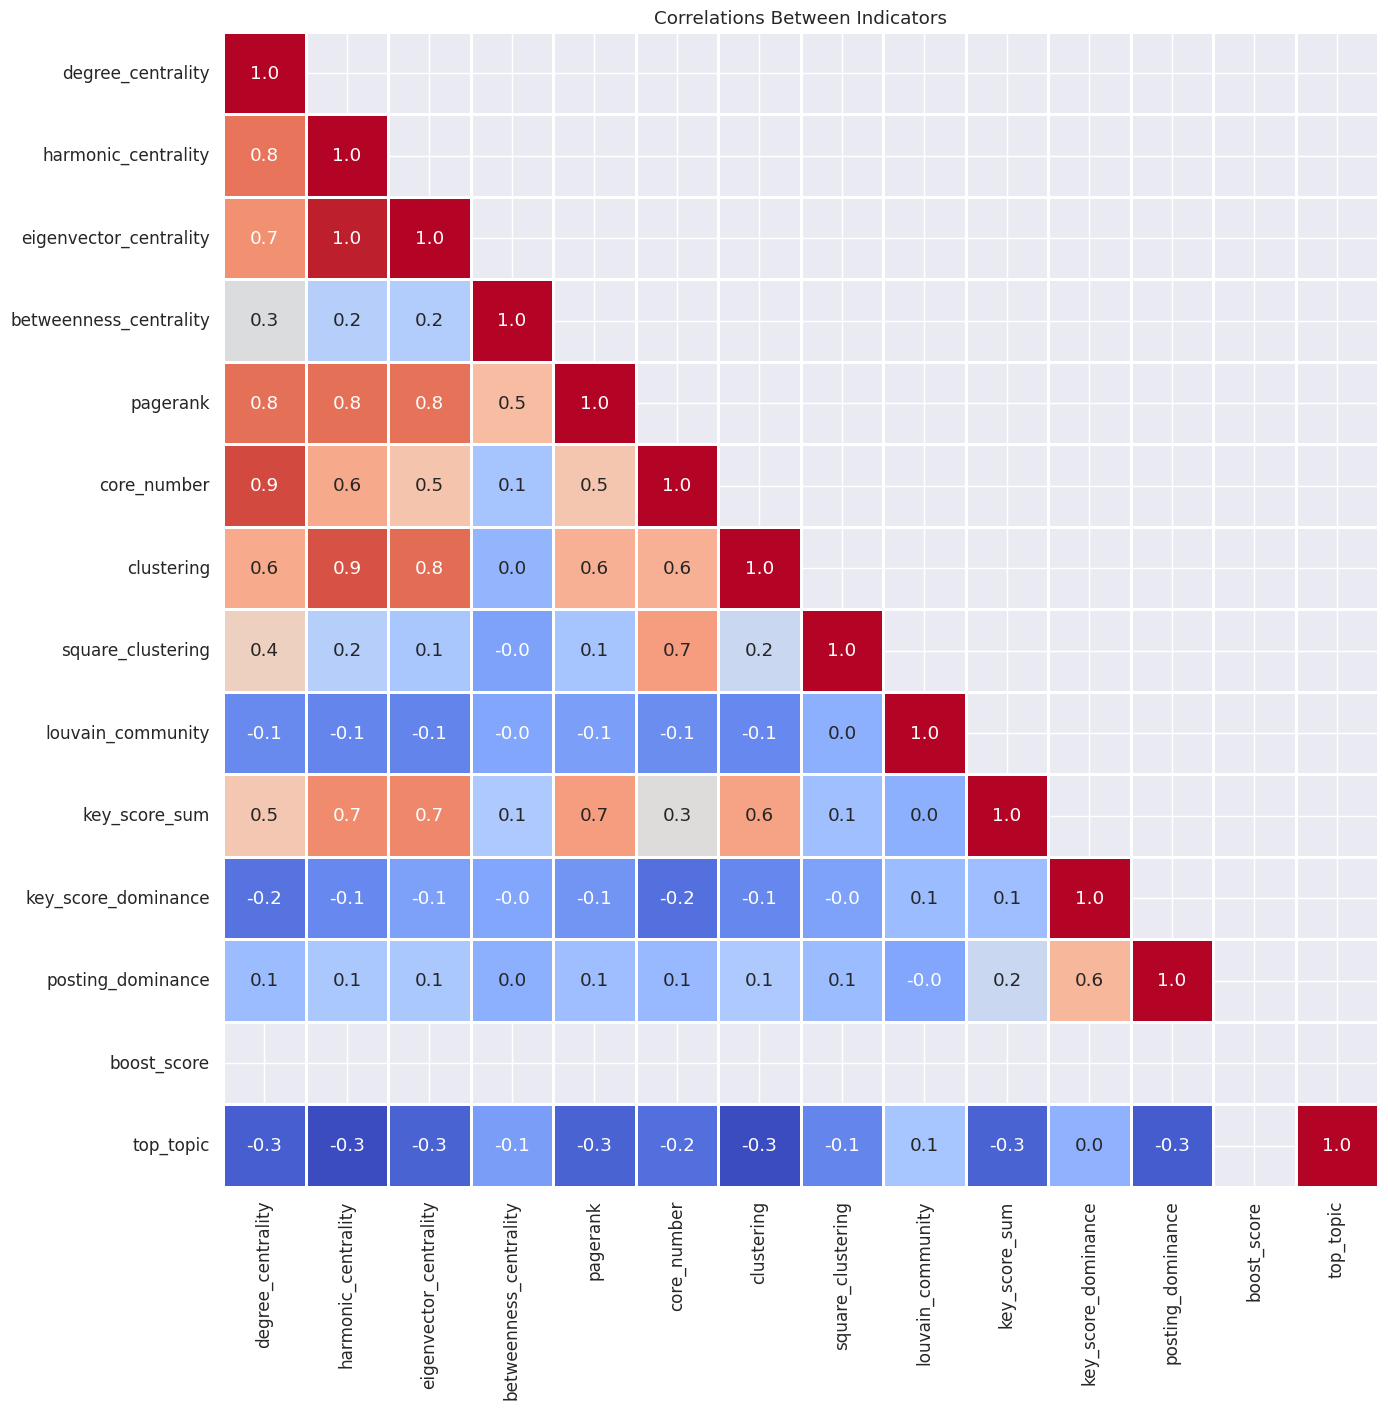

In [64]:
# Display correlations between indicators.
if run_demo:
    corr = node_indicators_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    sns.set(font_scale=1.1)
    plt.figure(figsize=(15, 15))
    sns.heatmap(corr,
                annot=True,
                fmt='.1f',
                cmap='coolwarm',
                square=True,
                mask = mask,
                linewidths=1,
                cbar=False)
    plt.title("Correlations Between Indicators")


    plt.savefig(folder_output_path / "indicators_correlation_heatmap.png", dpi=300, bbox_inches="tight")
    print(f"Saved indicators correlation heatmap to: {folder_output_path / 'indicators_correlation_heatmap.png'}")

    plt.show()
    plt.close()

## Z-Score

In [65]:
def zscore_from_series(values_series: pd.Series, ddof: int = 0) -> pd.Series:
    """Compute z-score normalization for a pandas Series.
    Args:
        s: Input series.
        ddof: Delta degrees of freedom for std (0=population, 1=sample).
    Returns:
        Z-scored series (same index).
    """
    mean = values_series.mean()
    std = values_series.std(ddof=ddof)

    if std == 0 or pd.isna(std):
        return pd.Series(0.0, index=values_series.index, name=f"{values_series.name}_z_score")

    return ((values_series - mean) / std).rename(f"{values_series.name}_z_score")


In [66]:
@report_done
def compute_zscore(node_indicators_df : pd.DataFrame) -> pd.DataFrame:
    """Compute z-score normalization for all columns in a DataFrame.

    Args:
        node_indicators_df: Input DataFrame with numeric columns.

    Returns:
        zscore_df: DataFrame with z-scored columns.
    """
    
    zscore_df = pd.DataFrame()

    for col in node_indicators_df.columns:
        zscore_df[f"{col}"] = zscore_from_series(node_indicators_df[col])

    zscore_df.index = node_indicators_df.index

    zscore_df.index.name = "accountid"

    return zscore_df

In [67]:
if run_demo:
    node_indicators_zscore_df = compute_zscore(node_indicators_df)
    print("#### zscore ####")
    node_indicators_zscore_df.head()

2026-07-07 17:02:08 | Completed: compute_zscore
#### zscore ####


## Account Indicators Summery

In [68]:
def show_account_indicators(
    accountid,
    node_indicators_df: pd.DataFrame,
    node_indicators_zscore_df: pd.DataFrame,
) -> None:
    """Display raw indicators and z-scores for a single account.
    Args:
        accountid: Account identifier (must exist in both DataFrames).
        node_indicators_df: Raw node-level indicators indexed by accountid.
        node_indicators_zscore_df: Z-score–normalized indicators indexed by accountid.
    Returns:
        None
    Raises:
        KeyError: If accountid is not found in either DataFrame.
    """
    # Validate inputs
    if accountid not in node_indicators_df.index:
        raise KeyError(f"accountid {accountid} not found in node_indicators_df")
    if accountid not in node_indicators_zscore_df.index:
        raise KeyError(f"accountid {accountid} not found in node_indicators_zscore_df")


    # Extract rows
    raw_row = node_indicators_df.loc[accountid]
    z_row = node_indicators_zscore_df.loc[accountid]

    # Build records DataFrame
    records = [
        {
            "indicator": indicator,
            "value": raw_row[indicator],
            "z_score": z_row[indicator],
        }
        for indicator in node_indicators_df.columns
    ]
    records_df = pd.DataFrame(records)

    # Style for visual inspection
    styled = (
        records_df.style
        .background_gradient(subset=["z_score"], cmap="coolwarm", vmin=-1.5, vmax=1.5)
        .format({"value": "{:.3f}", "z_score": "{:.2f}"})
    )

    # Display
    print(f"Account ID: {accountid}")
    display(styled)

    return None

In [69]:
if run_demo:
    suspect_accountid = node_indicators_df.sample(n=1).iloc[0].name


    show_account_indicators(
        accountid = suspect_accountid,
        node_indicators_df = node_indicators_df,
        node_indicators_zscore_df = node_indicators_zscore_df,
    )

Account ID: db50b1567d031513053d44bf4b3e622ae25c33298c


,indicator,value,z_score
0,degree_centrality,0.004,-0.63
1,harmonic_centrality,35884.621,-0.33
2,eigenvector_centrality,0.000,-0.24
3,betweenness_centrality,0.000,-0.10
4,pagerank,0.000,-0.50
5,core_number,6.000,-0.73
6,clustering,0.001,-0.28
7,square_clustering,0.247,-0.18
8,louvain_community,21.000,2.42
9,key_score_sum,10.071,-0.49


## Information Gain

In [70]:
@report_done
def compute_indicators_information_gain(
    node_indicators_df: pd.DataFrame,
    io_authors: set,
    folder_path: str | Path | None = None,
    all_authors: Iterable[str] | None = None,
) -> pd.Series:
    """Compute information gain (mutual information) between centrality features
    and an IO-author label.

    Args:
        node_indicators_df: DataFrame with authors as index and
            centrality metrics as columns.
        io_authors: Set of author IDs labeled as IO (1). Others are control (0).
        folder_path: Optional path to save the information gain results.
        all_authors: Optional iterable of all author IDs. If provided, missing authors
            are added to node_indicators_df with zero-valued indicators, ensuring
            information gain is computed over the complete author population.

    Returns:
        pd.Series: Information gain per centrality feature, sorted descending.
    """
    # Ensure consistent typing
    io_authors = set(map(str, io_authors))
    
    # If all_authors provided, add missing authors with zero indicators
    if all_authors is not None:
        node_indicators_df = add_missing_authors_with_zeros(node_indicators_df, all_authors)

    authors = node_indicators_df.index.astype(str)

    # Build binary label per author
    author_io_tag = authors.isin(io_authors).astype(int)

    # Prepare arrays for sklearn
    X = node_indicators_df.to_numpy()
    y = author_io_tag

    # Compute information gain (MI)
    mi = mutual_info_classif(X, y, discrete_features=False, random_state=42)

    # Convert to Series and sort
    mi_series = pd.Series(
        mi,
        index=node_indicators_df.columns,
        name="information_gain"
    ).sort_values(ascending=False)

    # Save results
    if folder_path is not None:
        folder_path = Path(folder_path)
        info_gain_output_path = folder_path / "indicators_information_gain.parquet"
        mi_series.to_frame().to_parquet(info_gain_output_path, compression = "gzip")
        print(f"Saved information gain results to: {info_gain_output_path}")

    return mi_series

In [71]:
if run_demo:
    mi_series = compute_indicators_information_gain(
        node_indicators_df,
        io_authors_set,
        folder_output_path,
        all_authors=df[account_id_col].astype(str).unique(),
    )
    display(mi_series)

[add_missing_authors_with_zeros] Added 20557 missing authors with indicators values set to zero.
Saved information gain results to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/indicators_information_gain.parquet
2026-07-07 17:02:10 | Completed: compute_indicators_information_gain


core_number               0.036617
degree_centrality         0.035737
eigenvector_centrality    0.030716
clustering                0.027734
harmonic_centrality       0.027675
louvain_community         0.026759
square_clustering         0.023827
pagerank                  0.022823
key_score_dominance       0.021471
posting_dominance         0.020926
key_score_sum             0.018967
top_topic                 0.015894
betweenness_centrality    0.006915
boost_score               0.000000
Name: information_gain, dtype: float64

## Plot

### Indicators Information Gain

In [72]:
@report_done
def plot_indicators_information_gain(
    mi_series: pd.Series,
    output_path: Path | str | None = None,
    filename: str = "indicators_information_gain.png",
    title: str = "Information Gain of Node Indicators for IO Driver Status",
) -> None:
    """Plot and save information gain per centrality feature.

    Args:
        mi_series: Information gain per centrality feature.
        output_path: Directory where the image will be saved.
        filename: Name of the output image file.
        title: Title of the plot.
    """

    # Create the plot
    plt.figure(figsize=(8, 4))
    mi_series.plot(kind="bar")

    plt.ylabel("Information gain")
    plt.xlabel("Indicators")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    # Save figure
    if output_path is not None:
      output_path = Path(output_path)
      file_path = output_path / filename
      plt.savefig(file_path, dpi=300)
      print(f"Saved fig to: {file_path}")

    # Show figure
    plt.show()

    # Close figure
    plt.close()

Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/indicators_information_gain_BERTopic_topic_256.png


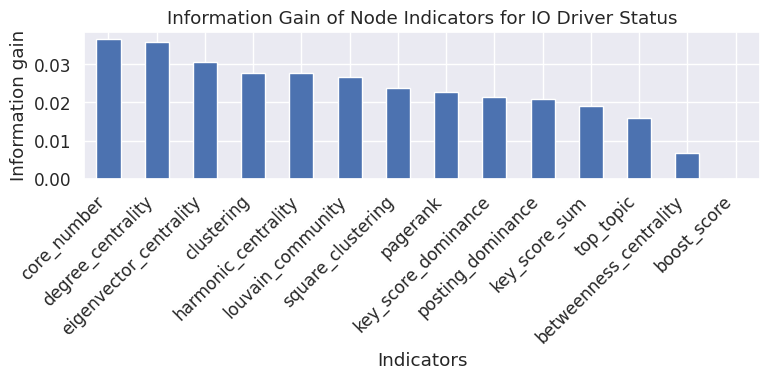

2026-07-07 17:02:10 | Completed: plot_indicators_information_gain


In [73]:
if run_demo:
    plot_indicators_information_gain(mi_series, folder_output_path, filename=f"indicators_information_gain_{topic_col}.png")

In [74]:
# the ig of z-score is the same as the original indicators, since z-scoring is a derivative of the original indicators
# if run_demo:
#     z_score_mi_series = compute_indicators_information_gain(
#         node_indicators_zscore_df,
#         io_authors_set,
#         all_authors=df[account_id_col].astype(str).unique(),
#     )
#     plot_indicators_information_gain(z_score_mi_series, folder_output_path, filename=f"indicators_z_score_information_gain_{topic_col}.png", title = "Information Gain of Node Indicators (Z-score) for IO Driver Status")

### Distributions

In [75]:
@report_done
def plot_indicators_distributions(
    node_indicators_df,
    output_path: str | Path | None = None,
    bins: int = 30,
):
    """Plot distributions of indicators for all authors.

    Args:
        node_indicators_df: DataFrame (index=author, columns=centralities).
        output_path: If given, save figure to this folder path.
        bins: Number of histogram bins.
    """
    features = node_indicators_df.columns
    n = len(features)

    rows = 2
    cols = math.ceil(n / rows)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten()  # key fix

    for ax, feature in zip(axes, features):
        ax.hist(node_indicators_df[feature], bins=bins, alpha=0.8)
        ax.set_title(feature)
        ax.set_xlabel("Value")
        ax.set_ylabel("Counts")


    # remove unused axes (when n is odd)
    for ax in axes[n:]:
        ax.remove()

    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        distributions_output_path = output_path / "indicators_distributions.png"
        fig.savefig(distributions_output_path, dpi=300, bbox_inches="tight")
        print(f"Saved indicators distributions to: {distributions_output_path}")

    plt.show()
    plt.close(fig)

Saved indicators distributions to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/indicators_distributions.png


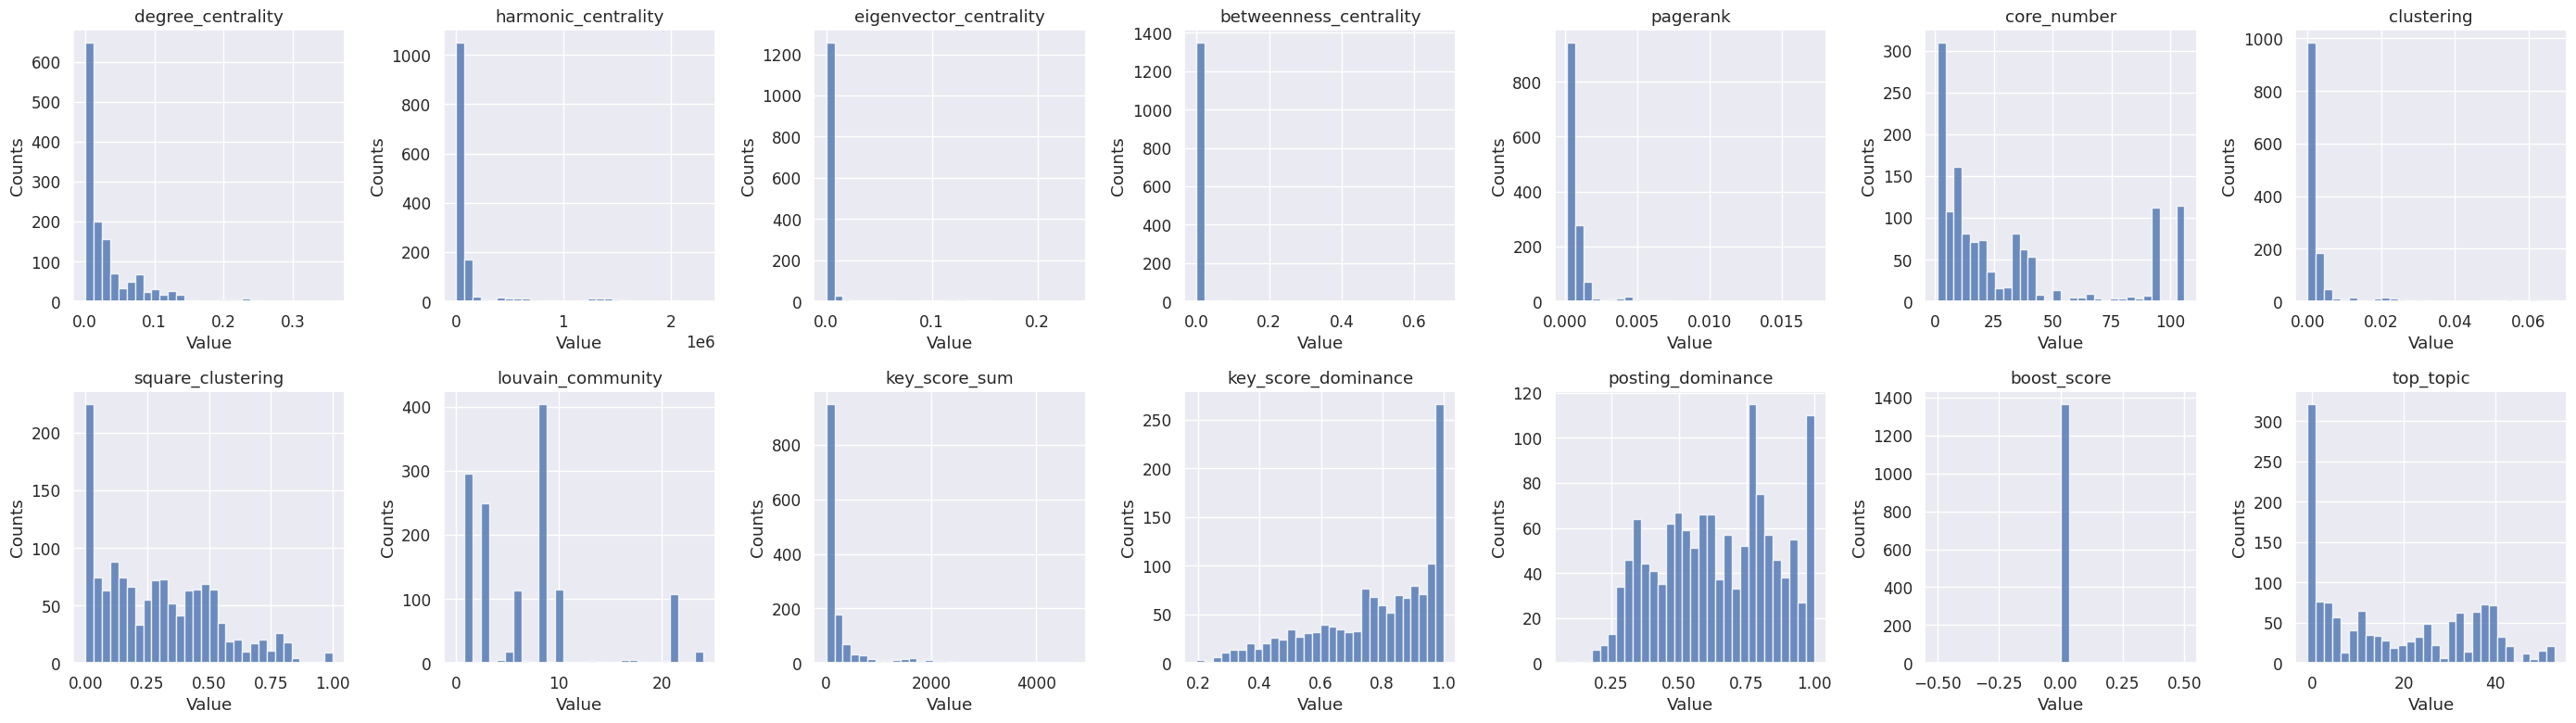

2026-07-07 17:02:13 | Completed: plot_indicators_distributions


In [76]:
if run_demo:
    plot_indicators_distributions(node_indicators_df, folder_output_path)

### Boxplots

In [77]:
@report_done
def plot_indicator_boxplots(node_indicators_df: pd.DataFrame, io_authors: set, output_folder_path: str | Path= None) -> None:
    """Create box plots of each indicator grouped by IO status.

    Args:
        node_indicators_df: DataFrame indexed by author/accountid with indicator columns.
        io_authors: Set of IO author IDs.
        output_folder_path: Optional path to save the plot image.
    """
    io_authors_set = set(map(str, io_authors))
    # idx_str = node_indicators_df.index.astype(str)

    plot_df = node_indicators_df.copy()

    io_mask = node_indicators_df.index.astype(str).isin(io_authors_set)
    plot_df["io_status"] = np.where(io_mask, "IO", "Non-IO")

    # Keep only numeric indicators
    indicators = [c for c in node_indicators_df.columns if is_numeric_dtype(node_indicators_df[c])]

    if not indicators:
        print("No numeric indicators found to plot.")
        return

    n = len(indicators)
    rows = 3 if n > 1 else 1
    cols = math.ceil(n / rows)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = [axes] if not isinstance(axes, (list, tuple, pd.core.generic.NDFrame)) and getattr(axes, "plot", None) else axes
    axes = getattr(axes, "flatten", lambda: axes)()

    for ax, ind in zip(axes, indicators):
        plot_df.boxplot(column=ind, by="io_status", ax=ax, grid=False)
        ax.set_title(ind)
        ax.set_xlabel("IO status")
        ax.set_ylabel(ind)

    # Remove unused axes
    for ax in axes[n:]:
        ax.remove()

    # Remove pandas' automatic "Boxplot grouped by io_status"
    fig.suptitle("Indicators vs IO status")
    plt.title("")  # clears the auto-title added by pandas
    plt.tight_layout(rect=[0, 0, 1, 0.95])


    if output_folder_path is not None:
        output_folder_path = Path(output_folder_path)
        distributions_output_path = output_folder_path / "indicators_boxplots.png"
        fig.savefig(distributions_output_path, dpi=300, bbox_inches="tight")
        print(f"Saved fig to: {distributions_output_path}")
    
    plt.show()
    plt.close()

Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/indicators_boxplots.png


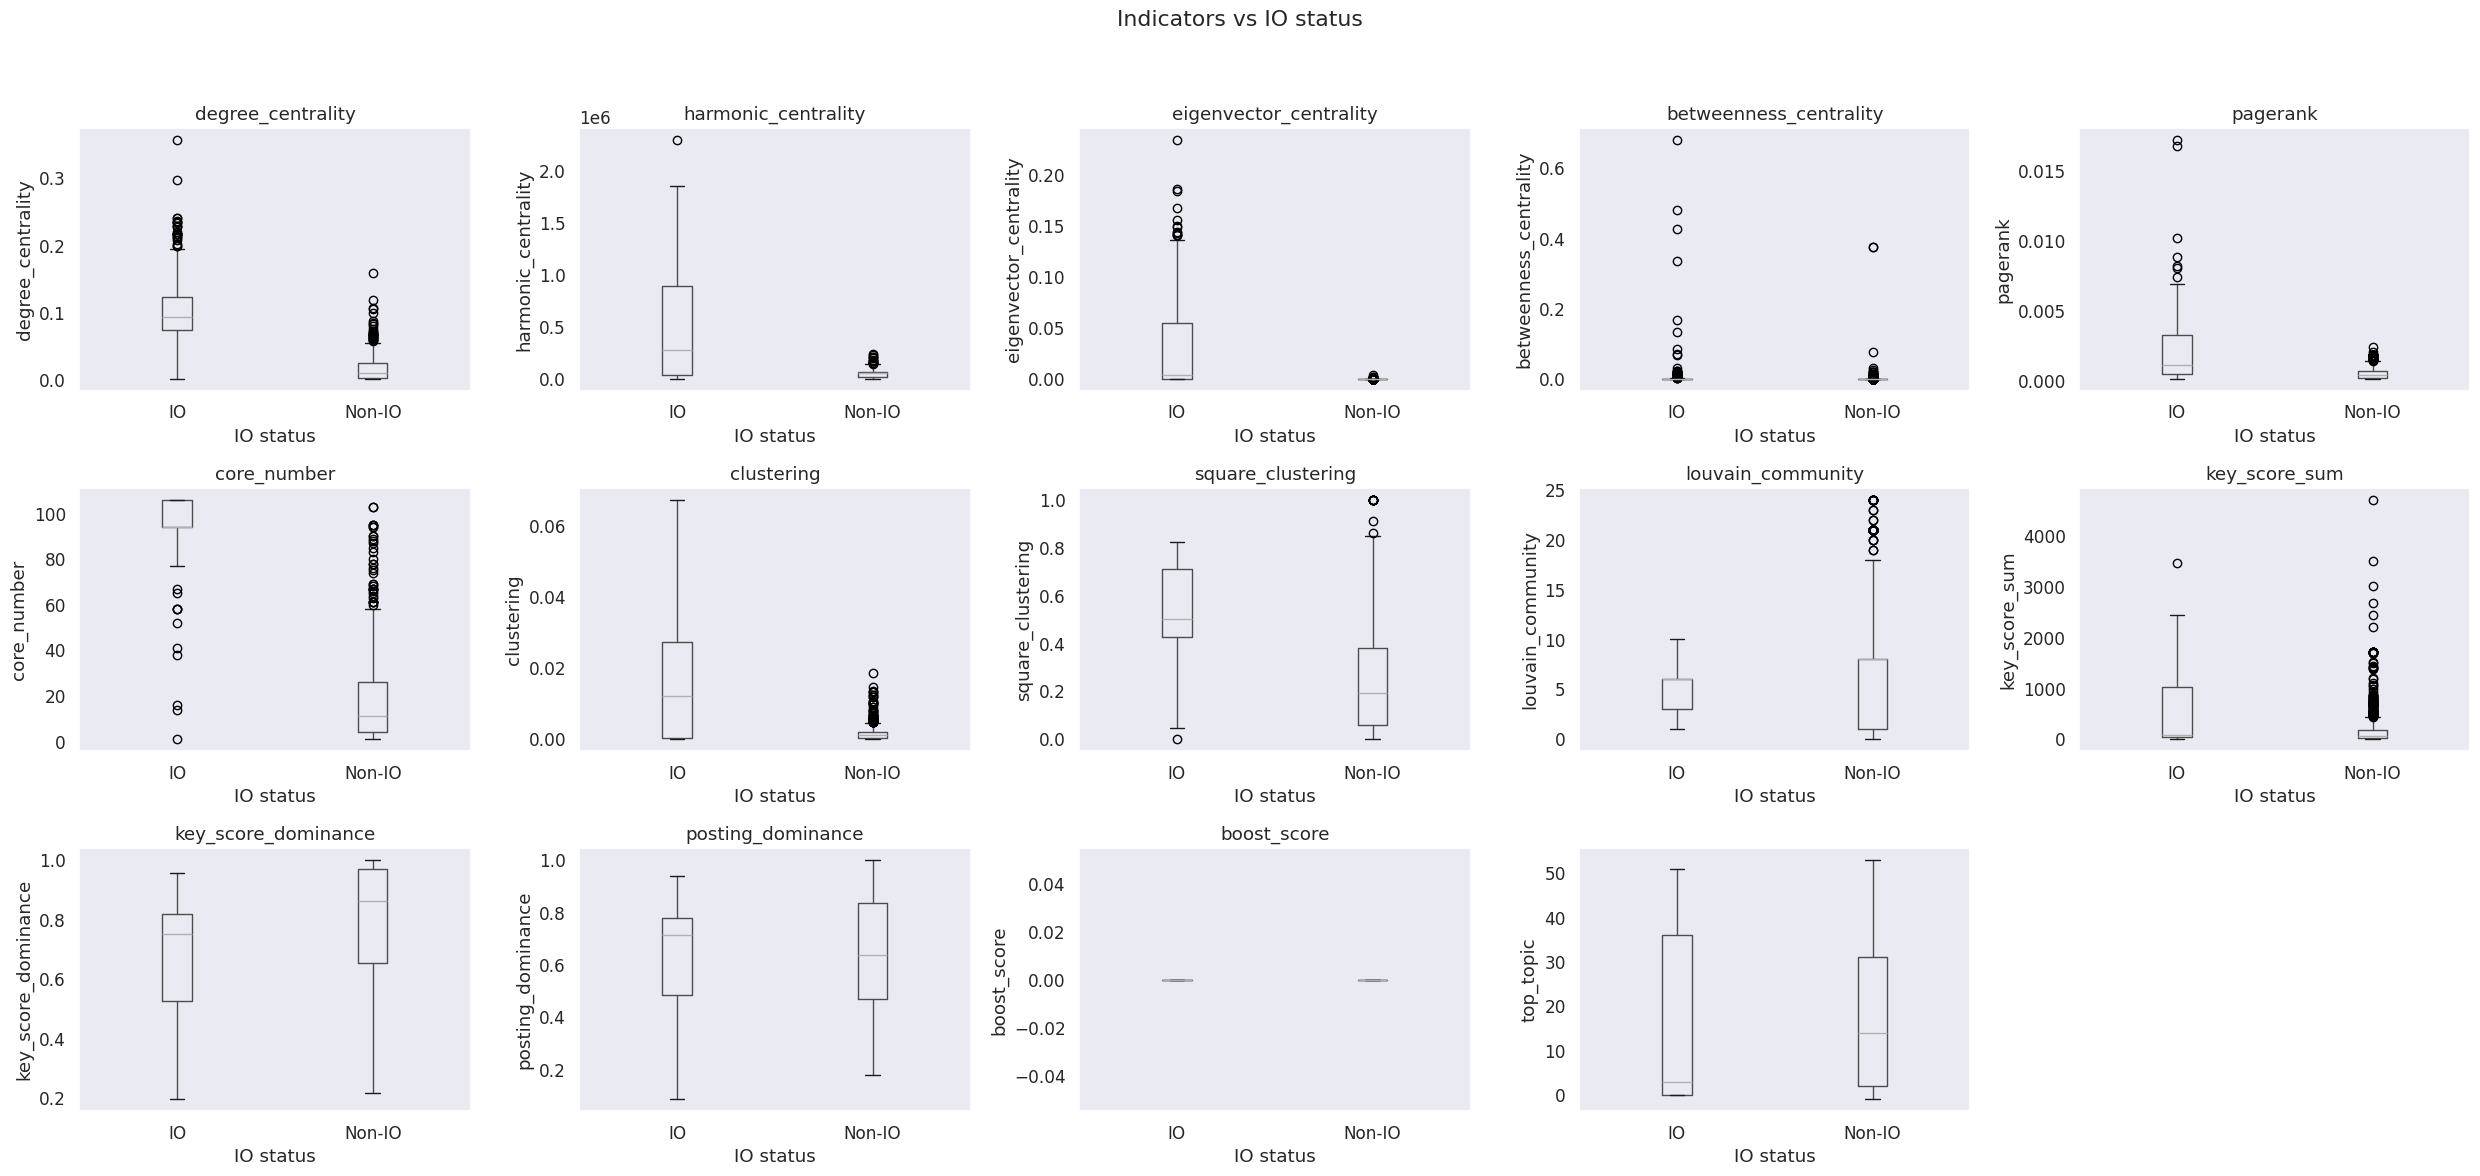

2026-07-07 17:02:15 | Completed: plot_indicator_boxplots


In [78]:
if run_demo:
    plot_indicator_boxplots(node_indicators_df, io_authors_set, output_folder_path = folder_output_path)

## Linear Coefficients

In [79]:
import pandas as pd
from pandas.api.types import is_numeric_dtype

if run_demo:
    io_mask = node_indicators_df.index.astype(str).isin(io_authors_set)

    # make it a Series with the same index
    io_binary = pd.Series(io_mask.astype(int), index=node_indicators_df.index, name="io_binary")

    indicators = [c for c in node_indicators_df.columns if is_numeric_dtype(node_indicators_df[c])]

    coefficients = {}
    for indicator in indicators:
        coefficients[indicator] = node_indicators_df[indicator].corr(io_binary)  # Pearson by default

    coefficients_df = (
        pd.Series(coefficients, name="correlation")
        .sort_values(ascending=False)
        .to_frame()
    )

    # display(coefficients_df)

/home/amitner/.conda/envs/backbone_env_v2/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/amitner/.conda/envs/backbone_env_v2/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [80]:
import matplotlib.pyplot as plt

@report_done
def plot_io_correlations(
        coefficients_df,
        title="Indicator Linear Coefficients with IO Label",
        folder_output_path: str | Path | None = None,
    ) -> None:
    """Plot correlation of graph indicators with IO binary label.

    Args:
        coefficients_df: DataFrame with index=indicator, column 'correlation'.
        title: Plot title.
    """
    df = coefficients_df.sort_values("correlation")

    plt.figure(figsize=(8, max(4, 0.35 * len(df))))
    plt.barh(df.index, df["correlation"])
    plt.axvline(0)
    plt.xlabel("Correlation with IO (binary)")
    plt.title(title)
    plt.tight_layout()
    
    if folder_output_path is not None:
        io_plot_path = Path(folder_output_path) / "indicators_io_linear_coefficients.png"
        plt.savefig(io_plot_path, dpi=300, bbox_inches="tight")
        print(f"Saved fig to: {io_plot_path}")

    plt.show()
    plt.close()

Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/indicators_io_linear_coefficients.png


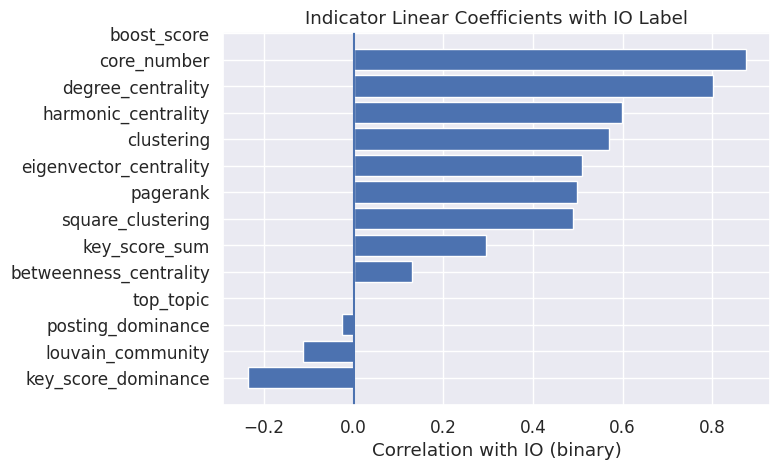

2026-07-07 17:02:16 | Completed: plot_io_correlations


In [81]:
if run_demo:
    plot_io_correlations(coefficients_df, folder_output_path = folder_output_path)

# PageRank and Key-Score

In [82]:
@report_done
def plot_pagerank_key_score_correlation(
    node_indicators_df: pd.DataFrame,
    key_score_col: str = "key_score_sum",
    pagerank_col: str = "pagerank",
    folder_output_path: str | Path | None = None,
    normalize_for_plot: bool = True,
    lowess_frac: float = 0.3,
) -> pd.DataFrame:
    """Correlate author KeyScore with PageRank and plot PageRank by KeyScore."""
    missing_cols = [
        col for col in [key_score_col, pagerank_col]
        if col not in node_indicators_df.columns
    ]
    if missing_cols:
        raise KeyError(f"Missing required columns in node_indicators_df: {missing_cols}")

    score_df = node_indicators_df[[key_score_col, pagerank_col]].copy()
    score_df[key_score_col] = pd.to_numeric(score_df[key_score_col], errors="coerce")
    score_df[pagerank_col] = pd.to_numeric(score_df[pagerank_col], errors="coerce")
    score_df = score_df.dropna().sort_values(key_score_col, ascending=False)

    if score_df.empty:
        raise ValueError("No valid KeyScore/PageRank pairs available for correlation.")

    pearson_corr = score_df[key_score_col].corr(score_df[pagerank_col], method="pearson")
    spearman_corr = score_df[key_score_col].corr(score_df[pagerank_col], method="spearman")
    print(f"Pearson correlation ({key_score_col} vs {pagerank_col}): {pearson_corr:.4f}")
    print(f"Spearman correlation ({key_score_col} vs {pagerank_col}): {spearman_corr:.4f}")

    plot_df = score_df.copy()

    x_label = "KeyScore"
    y_label = "PageRank"
    if normalize_for_plot:
        x_label = "Normalized KeyScore (0-1)"
        y_label = "Normalized PageRank (0-1)"
        for col in [key_score_col, pagerank_col]:
            col_min = plot_df[col].min()
            col_max = plot_df[col].max()
            if col_max > col_min:
                plot_df[col] = (plot_df[col] - col_min) / (col_max - col_min)
            else:
                plot_df[col] = 0.0

    plt.figure(figsize=(12, 6))
    plt.scatter(plot_df[key_score_col], plot_df[pagerank_col], s=24, alpha=0.7, label="Author Scores")

    if plot_df[key_score_col].nunique() > 1:
        slope, intercept = np.polyfit(plot_df[key_score_col], plot_df[pagerank_col], deg=1)
        x_fit = np.linspace(plot_df[key_score_col].min(), plot_df[key_score_col].max(), 100)
        y_fit = slope * x_fit + intercept
        plt.plot(x_fit, y_fit, color="black", linestyle="--", linewidth=2, label="Linear regression")

        from statsmodels.nonparametric.smoothers_lowess import lowess
        lowess_fit = lowess(
            plot_df[pagerank_col],
            plot_df[key_score_col],
            frac=lowess_frac,
            return_sorted=True,
        )
        plt.plot(lowess_fit[:, 0], lowess_fit[:, 1], color="orange", linewidth=2.5, label="LOWESS trend")

    plt.xlabel(x_label, fontsize=18)
    plt.ylabel(y_label, fontsize=18)
    plt.title(
        "PageRank by Author KeyScore\n"
        f"correlation: Pearson ={pearson_corr:.3f}, Spearman ={spearman_corr:.3f}",
        fontsize=22
    )
    plt.tick_params(axis="both", labelsize=14)
    plt.legend()
    plt.tight_layout()

    if folder_output_path is not None:
        plot_path = Path(folder_output_path) / "pagerank_key_score_scatter.png"
        plt.savefig(plot_path, dpi=300, bbox_inches="tight")
        print(f"Saved fig to: {plot_path}")

    plt.show()
    plt.close()

    return score_df


Pearson correlation (key_score_sum vs pagerank): 0.6567
Spearman correlation (key_score_sum vs pagerank): 0.5776
Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/pagerank_key_score_scatter.png


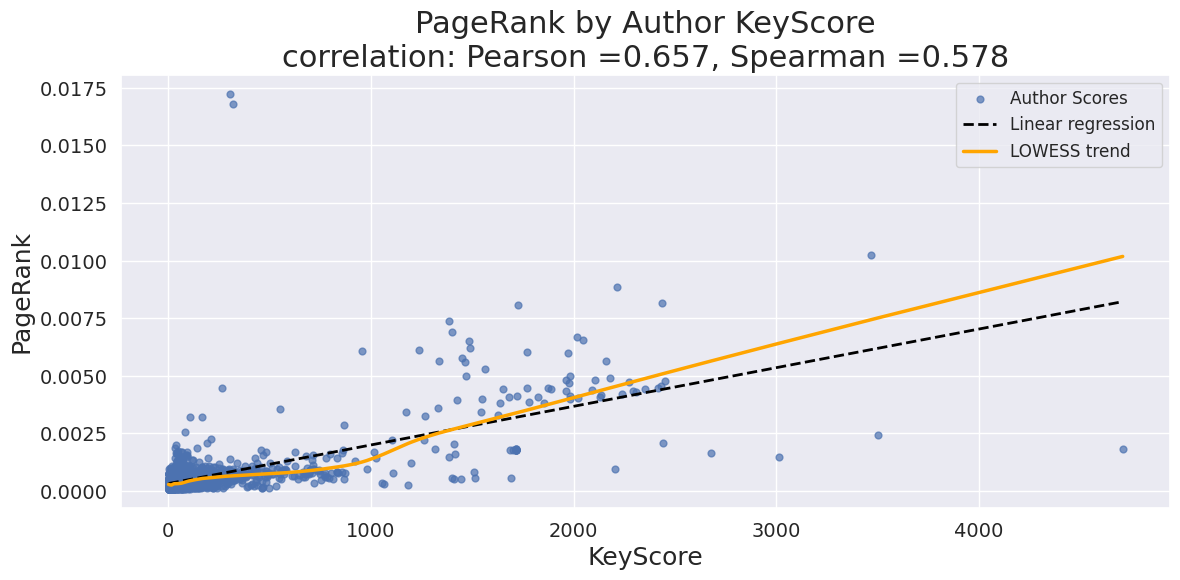

2026-07-07 17:02:16 | Completed: plot_pagerank_key_score_correlation


In [83]:
if run_demo:
    pagerank_key_score_df = plot_pagerank_key_score_correlation(
        node_indicators_df,
        folder_output_path=folder_output_path,
        normalize_for_plot = False
    )

# Classification

In [84]:
# for debugging
print(f"df shape: {df.shape}")

df shape: (1468565, 39)


In [85]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

import joblib

In [86]:
def get_classifier(model_name: str, random_state: int = 42, **kwargs):
    """Return a classifier instance by model name.

    Args:
        model_name: Model name. Supported:
            "random_forest", "rf",
            "xgboost", "xgb",
            "logistic_regression", "lr", "logistic"
        random_state: Random seed.
        **kwargs: Extra parameters passed to the model.

    Returns:
        A sklearn-compatible classifier.

    Raises:
        ValueError: If model_name is not supported.
    """
    model_name = model_name.lower()

    if model_name in ["random_forest", "rf"]:
        return RandomForestClassifier(
            random_state=random_state,
            **kwargs,
        )

    if model_name in ["xgboost", "xgb"]:
        return XGBClassifier(
            random_state=random_state,
            eval_metric="logloss",
            **kwargs,
        )

    if model_name in ["logistic_regression", "lr", "logistic"]:
        return LogisticRegression(
            random_state=random_state,
            solver="liblinear",  # safe default
            max_iter=1000,
            **kwargs,
        )

    raise ValueError(
        f"Unsupported model_name: {model_name}. "
        "Supported: random_forest/rf, xgboost/xgb, logistic_regression/lr/logistic"
    )

In [87]:
@report_done
def io_classification(
    node_indicators_df: pd.DataFrame,
    io_authors_set: set,
    model_name: str,
    folder_output_path: str | Path | None = None,
    test_size: float = 0.2,
    random_state: int = 42,
):
    """Train and evaluate an IO classifier using the selected model.

    Args:
        node_indicators_df: DataFrame indexed by author IDs, with numeric features.
        io_authors_set: Set of author IDs labeled as IO.
        model_name: Model name. Supported: random_forest/rf, xgboost/xgb, logistic_regression/lr/logistic.
        folder_output_path: Optional folder path to save report and model.
        test_size: Fraction of data used for test split.
        random_state: Random seed.

    Returns:
        tuple(clf, report, auc, f1, y_test, y_proba_test):
            - clf: Trained classifier
            - report: Classification report string
            - auc: ROC AUC score
            - f1: F1 score for the IO class
            - y_test: Test labels
            - y_proba_test: Test prediction probabilities
    """
    X = node_indicators_df.to_numpy()

    io_authors_set = set(map(str, io_authors_set))
    y = node_indicators_df.index.astype(str).isin(io_authors_set).astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )
    print(f"Training set: {len(X_train)} samples, Test set: {len(X_test)} samples")

    clf = get_classifier(model_name=model_name, random_state=random_state)
    clf.fit(X_train, y_train)

    y_pred_test = clf.predict(X_test)
    y_proba_test = clf.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred_test, target_names=["Non-IO", "IO"])
    auc = roc_auc_score(y_test, y_proba_test)
    f1 = f1_score(y_test, y_pred_test)

    if folder_output_path is not None:
        folder_output_path = Path(folder_output_path)

        report_path = folder_output_path / f"io_classification_{model_name}_report.txt"
        model_path = folder_output_path / f"io_classification_{model_name}_model.joblib"

        # report
        report_text = (
            f"Model: {model_name}\n"
            f"Training set: {len(X_train):,} samples\n"
            f"Test set: {len(X_test):,} samples\n\n"
            f"{report}\n"
            f"AUC: {auc:.4f}\n"
            f"F1: {f1:.4f}\n"
        )
        print(report_text)
        with open(report_path, "w", encoding="utf-8") as f:
            f.write(report_text)

        # save model
        joblib.dump(clf, model_path)

        write_report(f"Saved report to: {report_path}")
        write_report(f"Saved model to: {model_path}")

    return clf, report, auc, f1, y_test, y_proba_test

In [88]:
if run_demo:
    rf_model, rf_report, rf_auc, rf_f1, _, _ = io_classification(node_indicators_df, io_authors_set, "random_forest", folder_output_path)

Training set: 1092 samples, Test set: 274 samples
Model: random_forest
Training set: 1,092 samples
Test set: 274 samples

              precision    recall  f1-score   support

      Non-IO       1.00      1.00      1.00       225
          IO       0.98      0.98      0.98        49

    accuracy                           0.99       274
   macro avg       0.99      0.99      0.99       274
weighted avg       0.99      0.99      0.99       274

AUC: 0.9870
F1: 0.9796

2026-07-07 17:02:17 | Saved report to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_classification_random_forest_report.txt
2026-07-07 17:02:17 | Saved model to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_classification_random_forest_model.joblib
2026-07-07 17:02:17 | Completed: io_classification


In [89]:
if run_demo:
    xgb_model, xgb_report, xgb_auc, xgb_f1, _, _ = io_classification(node_indicators_df, io_authors_set, "xgboost", folder_output_path)

Training set: 1092 samples, Test set: 274 samples
Model: xgboost
Training set: 1,092 samples
Test set: 274 samples

              precision    recall  f1-score   support

      Non-IO       1.00      0.99      0.99       225
          IO       0.94      0.98      0.96        49

    accuracy                           0.99       274
   macro avg       0.97      0.98      0.98       274
weighted avg       0.99      0.99      0.99       274

AUC: 0.9946
F1: 0.9600

2026-07-07 17:02:17 | Saved report to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_classification_xgboost_report.txt
2026-07-07 17:02:17 | Saved model to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_classification_xgboost_model.joblib
2026-07-07 17:02:17 | Completed: io_classification


In [90]:
if run_demo:
    lr_model, lr_report, lr_auc, lr_f1, _, _ = io_classification(node_indicators_df, io_authors_set, "logistic_regression", folder_output_path)

Training set: 1092 samples, Test set: 274 samples
Model: logistic_regression
Training set: 1,092 samples
Test set: 274 samples

              precision    recall  f1-score   support

      Non-IO       0.99      0.95      0.97       225
          IO       0.80      0.96      0.87        49

    accuracy                           0.95       274
   macro avg       0.89      0.95      0.92       274
weighted avg       0.96      0.95      0.95       274

AUC: 0.9714
F1: 0.8704

2026-07-07 17:02:17 | Saved report to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_classification_logistic_regression_report.txt
2026-07-07 17:02:17 | Saved model to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_classification_logistic_regression_model.joblib
2026-07-07 17:02:17 | Completed: io_classification


## Features Importance

### SHAP

In [91]:
import shap
import matplotlib.pyplot as plt
from pathlib import Path

@report_done
def plot_shap_analysis(
    trained_model,
    X: pd.DataFrame,
    folder_output_path: str | Path | None = None,
) -> None:

    """
    Plot SHAP analysis for a tree-based model.

    Args:
        trained_model: Fitted tree-based model.
        X: Data as DataFrame (must include column names).
        folder_output_path: Optional folder path to save the SHAP plots.

    Returns:
        None. Displays SHAP plots.
    """

    explainer = shap.Explainer(trained_model)
    shap_values = explainer(X)

    if folder_output_path is not None:
        folder_output_path = Path(folder_output_path)


    # --- BAR PLOT ---
    shap.plots.bar(shap_values, show=False)

    if folder_output_path is not None:
        shap_bar_path = folder_output_path / "shap_global_importance.png"
        plt.savefig(shap_bar_path, dpi=300, bbox_inches="tight")
        print(f"[SHAP] Saved global importance plot to: {shap_bar_path.resolve()}")

    plt.show()
    plt.close()

    # --- BEESWARM ---
    shap.plots.beeswarm(shap_values, show=False)

    if folder_output_path is not None:
        shap_beeswarm_path = folder_output_path / "shap_global_distribution.png"
        plt.savefig(shap_beeswarm_path, dpi=300, bbox_inches="tight")
        print(f"[SHAP] Saved global distribution plot to: {shap_beeswarm_path.resolve()}")

    plt.show()
    plt.close()

SHAP analysis for XGBoost model:


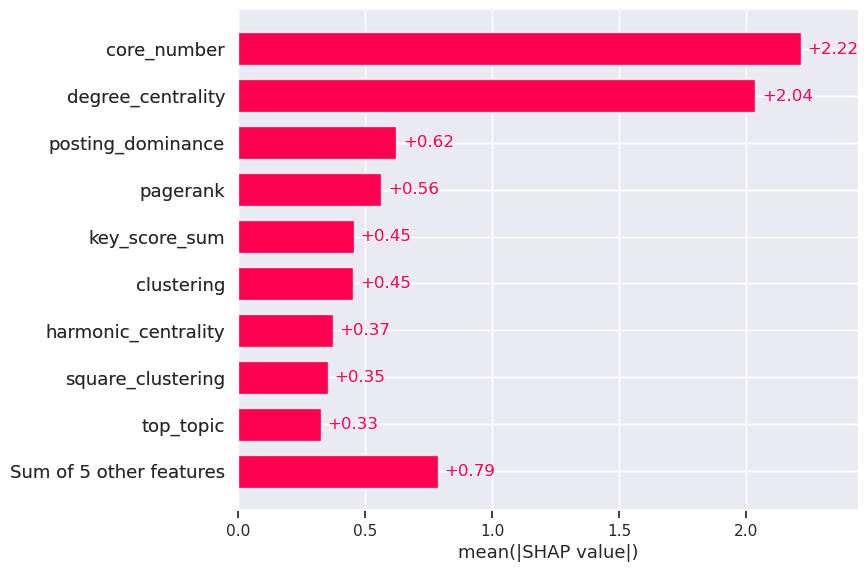

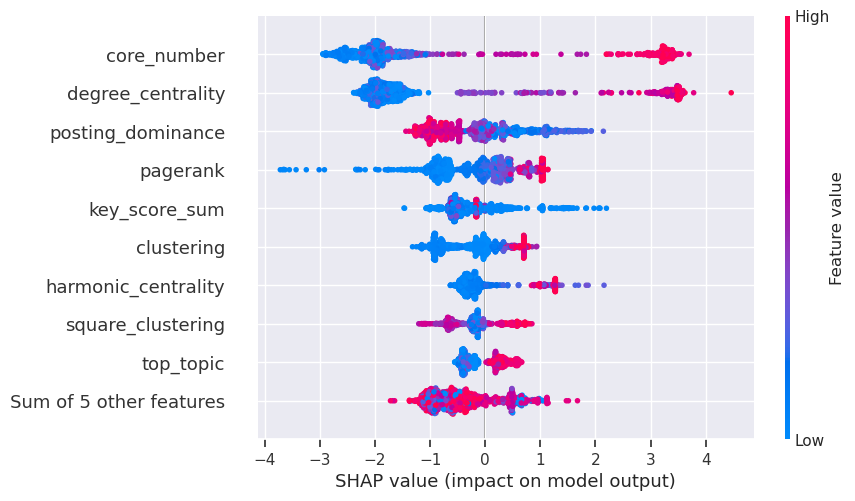

2026-07-07 17:02:20 | Completed: plot_shap_analysis


In [92]:
if run_demo:
    print("SHAP analysis for XGBoost model:")
    plot_shap_analysis(xgb_model, node_indicators_df)

## Core Number

In [93]:
if run_demo:
    indicator_col= "core_number"
    core_number_df = node_indicators_df[[indicator_col]].copy()
    core_number_df[indicator_col] = pd.to_numeric(core_number_df[indicator_col], errors="coerce")
    core_number_df = core_number_df.dropna(subset=[indicator_col])

In [94]:
if run_demo:
    rf_model_core_only, rf_report_core_only, rf_auc_core_only, rf_f1_core_only, _, _ = io_classification(core_number_df, io_authors_set, "random_forest", folder_output_path)
    xgb_model_core_only, xgb_report_core_only, xgb_auc_core_only, xgb_f1_core_only, _, _ = io_classification(core_number_df, io_authors_set, "xgboost", folder_output_path)
    lr_model_core_only, lr_report_core_only, lr_auc_core_only, lr_f1_core_only, _, _ = io_classification(core_number_df, io_authors_set, "logistic_regression", folder_output_path)

Training set: 1092 samples, Test set: 274 samples
Model: random_forest
Training set: 1,092 samples
Test set: 274 samples

              precision    recall  f1-score   support

      Non-IO       0.98      1.00      0.99       225
          IO       0.98      0.90      0.94        49

    accuracy                           0.98       274
   macro avg       0.98      0.95      0.96       274
weighted avg       0.98      0.98      0.98       274

AUC: 0.9866
F1: 0.9362

2026-07-07 17:02:20 | Saved report to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_classification_random_forest_report.txt
2026-07-07 17:02:20 | Saved model to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_classification_random_forest_model.joblib
2026-07-07 17:02:20 | Completed: io_classification
Training set: 1092 samples, Test set: 274 samples
Model: xgboost
Training set: 1,092 samples
Test set: 274 samples

              preci

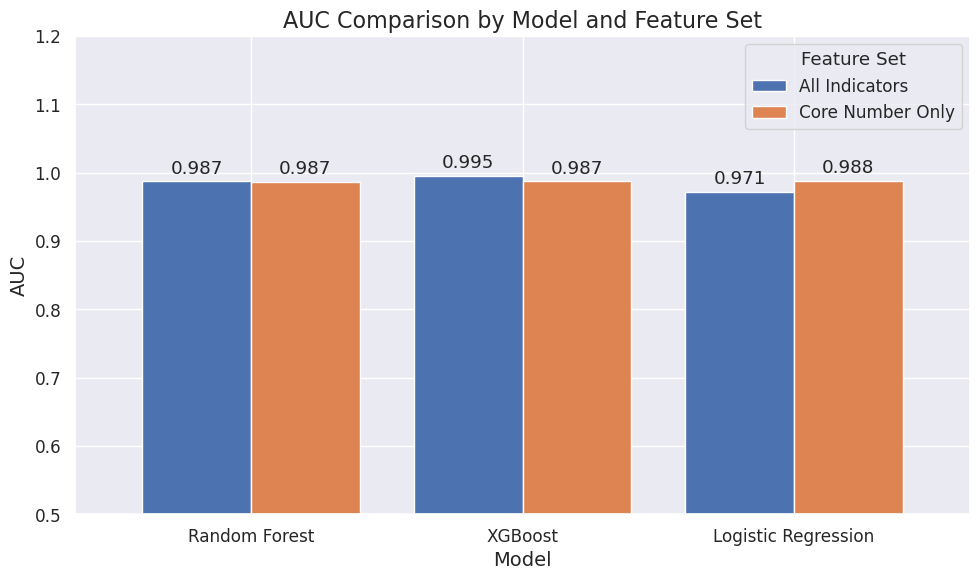

In [183]:
# AUC comparison

if run_demo:
    auc_df = pd.DataFrame(
        {
            "All Indicators": [rf_auc, xgb_auc, lr_auc],
            "Core Number Only": [rf_auc_core_only, xgb_auc_core_only, lr_auc_core_only],
        },
        index=["Random Forest", "XGBoost", "Logistic Regression"],
    )


    ax = auc_df.plot(
        kind="bar",
        figsize=(10, 6),
        rot=0,
        width=0.8,
    )

    ax.set_title("AUC Comparison by Model and Feature Set", fontsize=16)
    ax.set_xlabel("Model", fontsize=14)
    ax.set_ylabel("AUC", fontsize=14)
    ax.set_ylim(0.5, 1.2)
    ax.legend(title="Feature Set")

    # Add values above the bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3)

    plt.tight_layout()
    plt.show()

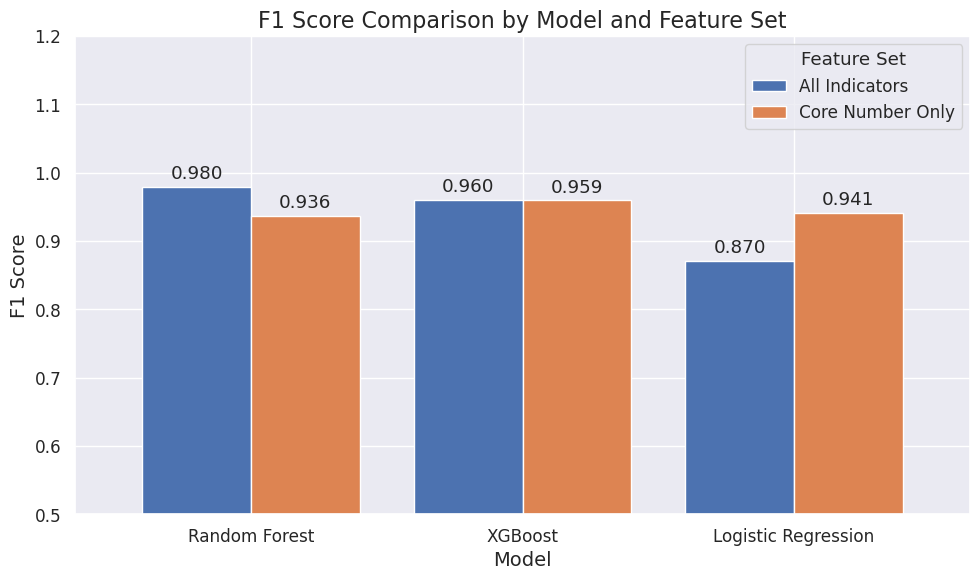

In [181]:
# F1 comparison

if run_demo:
    f1_df = pd.DataFrame(
        {
            "All Indicators": [rf_f1, xgb_f1, lr_f1],
            "Core Number Only": [rf_f1_core_only, xgb_f1_core_only, lr_f1_core_only],
        },
        index=["Random Forest", "XGBoost", "Logistic Regression"],
    )

    ax = f1_df.plot(
        kind="bar",
        figsize=(10, 6),
        rot=0,
        width=0.8,
    )

    ax.set_title("F1 Score Comparison by Model and Feature Set", fontsize=16)
    ax.set_xlabel("Model", fontsize=14)
    ax.set_ylabel("F1 Score", fontsize=14)
    ax.set_ylim(0.5, 1.2)
    ax.legend(title="Feature Set")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3)

    plt.tight_layout()
    plt.show()

# Hypothesis

## Utils

In [97]:
def build_io_rate_by_indicator(
    node_indicators_df: pd.DataFrame,
    io_authors_set: set,
    indicator_col: str,
    n_bins: int | None = None,
    group_mode: str = "equal",
) -> pd.DataFrame:
    """Compute IO rate statistics per indicator value or bin.

        This function aggregates authors by a given indicator and computes:
        total authors, number of IO authors, IO rate, and non-IO authors.

        Args:
            node_indicators_df (pd.DataFrame):
                DataFrame indexed by account ID containing indicator columns.
            io_authors_set (set):
                Set of account IDs labeled as IO authors.
            indicator_col (str):
                Name of the indicator column to analyze.
            n_bins (int | None, optional):
                Number of quantile-based bins. If None, uses raw indicator values.
            group_mode (str, optional):
                Method to group indicator values into bins. Supported: ["equal", "larger", "smaller", "=", ">", "<"]

        Returns:
            pd.DataFrame:
                DataFrame with the following columns:
                    - indicator_col: Indicator value or bin midpoint.
                    - n_authors: Total number of authors in group.
                    - io_authors: Number of IO authors in group.
                    - io_rate: Fraction of IO authors (io_authors / n_authors).
                    - legitimate_authors: Number of non-IO authors.
        """
    if indicator_col not in node_indicators_df.columns:
        raise KeyError(f"{indicator_col} not found")

    group_mode =  group_mode.lower().strip()
    if group_mode not in ["equal", "larger", "smaller", "=", ">", "<"]:
        raise ValueError(f"Unsupported group_mode: {group_mode}")

    # Build minimal dataframe
    df = node_indicators_df[[indicator_col]].copy()

    # IO label
    io_authors_set = set(map(str, io_authors_set))
    df["io_status"] = df.index.astype(str).isin(io_authors_set).astype(int)

    # Optional binning
    if n_bins is not None:
        # df[indicator_col] = pd.qcut(df[indicator_col], q=n_bins, duplicates="drop")
        df[indicator_col] = pd.cut(df[indicator_col], bins=n_bins, duplicates="drop")

    # Group by indicator and compute IO rate
    if group_mode in ["equal", "="]:
        indicator_io_df = (
            df.groupby(indicator_col)["io_status"]
            .agg(n_authors="count", io_authors="sum", io_rate="mean")
            .reset_index()
            .sort_values(indicator_col)
        )
        indicator_io_df["legitimate_authors"] = indicator_io_df["n_authors"] - indicator_io_df["io_authors"]
    
    else:

        values = sorted(df[indicator_col].dropna().unique())

        if group_mode in ["larger", ">"]:
            rows = []
            for v in values:
                temp = df[df[indicator_col] > v]
                rows.append({
                    indicator_col: v,
                    "n_authors": len(temp),
                    "io_authors": temp["io_status"].sum(),
                    "io_rate": temp["io_status"].mean(),
                })

        elif group_mode in ["smaller", "<"]:
            rows = []
            for v in values:
                temp = df[df[indicator_col] < v]
                rows.append({
                    indicator_col: v,
                    "n_authors": len(temp),
                    "io_authors": temp["io_status"].sum(),
                    "io_rate": temp["io_status"].mean(),
                })
            
        indicator_io_df = pd.DataFrame(rows)
        indicator_io_df["legitimate_authors"] = indicator_io_df["n_authors"] - indicator_io_df["io_authors"]




    if n_bins is not None:
        indicator_io_df[indicator_col + "_bin"] = indicator_io_df[indicator_col]
        indicator_io_df[indicator_col] = indicator_io_df[indicator_col].apply(lambda x: x.mid)


    display(indicator_io_df)

    return indicator_io_df

In [98]:
@report_done
def plot_io_counts_by_indicator(
    indicator_io_df: pd.DataFrame,
    indicator_col: str,
    output_path: Path | str | None = None,
    used_bins: bool = False,
    graph_type: str = "line",
    group_mode: str = "UNK", # for legend
) -> None:
    """Plot total, IO, and legitimate authors by indicator.
    Args:        
        indicator_io_df: DataFrame with columns [indicator_col, n_authors, io_authors, io_rate].
        indicator_col: Column name for the indicator (x-axis).
        output_path: Optional path to save the plot image.
        used_bins: Whether the indicator_col is binned. For the title and x-axis label formatting.
        graph_type: Type of graph to plot ("line" or "bar").
    """

    if graph_type not in ["line", "bar"]:
        raise ValueError(f"Unsupported graph_type: {graph_type}. Supported: 'line', 'bar'")

    x = indicator_io_df[indicator_col]


    plt.figure(figsize=(8, 4))

    if graph_type == "line":
        # total
        plt.plot(
            x,
            indicator_io_df["n_authors"],
            marker="o",
            label="Total authors",
        )

        # io
        plt.plot(
            x,
            indicator_io_df["io_authors"],
            marker="o",
            label="IO authors",
        )

        # legitimate
        plt.plot(
            x,
            indicator_io_df["legitimate_authors"],
            marker="o",
            label="Legitimate authors",
        )

        plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) # format y-axis with commas


    if graph_type == "bar":

        plt.xticks(x)

        # total
        plt.bar(
            x,
            indicator_io_df["n_authors"],
            label="Total authors",
            color= "tab:blue",
        )

        # io
        plt.bar(
            x,
            indicator_io_df["io_authors"],
            label="IO authors",
            color= "tab:orange",
        )

    plt.xlabel(indicator_col + ("" if not used_bins else  " (middle value of bin)"), fontsize=16)
    plt.ylabel("Number of authors", fontsize=16)
    plt.title(f"Author Counts by {indicator_col}", fontsize=18)
    plt.grid(alpha=0.3)

    handles, labels = plt.gca().get_legend_handles_labels()
    handles.append(
        Line2D([0], [0], color="none", label=f"Group mode: {group_mode}")
    )
    plt.legend(handles=handles)
    
    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        file_path = output_path / f"io_counts_by_{indicator_col}.png"
        plt.savefig(file_path, dpi=300)
        print(f"Saved fig to: {file_path}")

    plt.show()
    plt.close()

In [99]:
@report_done
def plot_io_rate_by_indicator(
    io_rate_df: pd.DataFrame,
    indicator_col: str,
    min_support: int = 1,
    output_path: Path | str | None = None,
    used_bins: bool = False,
    graph_type: str = "line",
    group_mode: str = "UNK", # for legend
) -> None:
    """
    Plot IO rate as a function of an indicator.

    Args:
        io_rate_df (pd.DataFrame):
            DataFrame containing aggregated statistics with columns:
            [indicator_col, n_authors, io_authors, io_rate].
        indicator_col (str):
            Name of the indicator column to plot on the x-axis.
        min_support (int):
            Minimum number of authors required for a group to be included.
        output_path (str | Path | None, optional):
            Path to save the plot image. If None, the plot is not saved.
        used_bins (bool):
            Whether the indicator values are binned. Affects axis labeling and title.
        graph_type (str):
            Type of plot to generate. Supported values: "line" or "bar".

    Returns:
        None:
            Displays the plot and optionally saves it to disk.
    """

    print(f"[plot_io_rate_by_indicator] Plotting {len(io_rate_df):,} samples with at least {min_support} authors each.")
    
    if graph_type not in ["line", "bar"]:
        raise ValueError(f"Unsupported graph_type: {graph_type}. Supported: 'line', 'bar'")

    # filter small groups
    df_plot = io_rate_df[io_rate_df["n_authors"] >= min_support]

    # sort values
    df_plot = df_plot.sort_values(indicator_col)


    plt.figure(figsize=(8, 4))

    if graph_type == "line":
        # plt.plot(
        #     df_plot[indicator_col],
        #     df_plot["io_rate"],
        #     marker="o",
        #     color="black",
        # )

        n = df_plot["n_authors"]
        min_size = 20
        max_size = 150
        sizes = min_size + (n - n.min()) / (n.max() - n.min()) * (max_size - min_size)
        
        plt.scatter(
            df_plot[indicator_col],
            df_plot["io_rate"],
            s=sizes,  # size by support
            color="navy",
            zorder=3, # dots on top of the line
        )

        plt.plot(
            df_plot[indicator_col],
            df_plot["io_rate"],
            color="black",
            linewidth=0.8,
            alpha=0.5,
        )


        legend_elements = [
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor="navy",
            markersize=6,
            label="Point size ∝ number of authors",
        ),
        Line2D(
            [0], [0],
            color="none",
            label=f"Plotting groups with ≥ {min_support} authors",
        ),
        Line2D(
            [0], [0],
            color="none",
            label=f"Group mode: {group_mode}",
        ),
        ]

        plt.legend(handles=legend_elements, loc="best")

    else: # graph_type == "bar"
        plt.bar(
            df_plot[indicator_col],
            df_plot["io_rate"],
            color="black",
        )
        
        plt.xticks(df_plot[indicator_col])


    plt.xlabel(indicator_col + ("" if not used_bins else  " (middle value of bin)"), fontsize=16)
    plt.ylabel("IO rate", fontsize=16)
    plt.title(f"IO Rate by {indicator_col}", fontsize=18)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        file_path = output_path / f"io_rate_by_{indicator_col}.png"
        plt.savefig(file_path, dpi=300)
        print(f"Saved fig to: {file_path}")

    plt.show()
    plt.close()

In [100]:
@report_done
def plot_indicator_cdf_subplots(
    node_indicators_df: pd.DataFrame,
    io_authors_set: set,
    indicator_col: str,
    output_path: Path | str | None = None,
) -> None:
    """Plot CDFs for all, legitimate, and IO authors with linear/log scales.

    Args:
        node_indicators_df: DataFrame indexed by account ID.
        io_authors_set: Set of IO author IDs.
        indicator_col: Indicator column to plot.
        output_path: Optional folder path to save the figure.
    """
    if indicator_col not in node_indicators_df.columns:
        raise KeyError(f"{indicator_col} not found")

    io_authors_set = set(map(str, io_authors_set))

    df = node_indicators_df[[indicator_col]].copy()
    df["is_io"] = df.index.astype(str).isin(io_authors_set)

    groups = {
        "All authors": df[indicator_col],
        "Legitimate authors": df.loc[~df["is_io"], indicator_col],
        "IO authors": df.loc[df["is_io"], indicator_col],
    }

    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=False)

    for col_idx, (title, values) in enumerate(groups.items()):
        values = values.dropna().sort_values()

        if values.empty:
            axes[0, col_idx].set_title(title)
            axes[1, col_idx].set_title(f"{title} | log-log")
            continue

        y = np.arange(1, len(values) + 1) / len(values) # the CDF values (from 1/n to 1)

        # Regular CDF
        axes[0, col_idx].step(values, y, where="post")
        axes[0, col_idx].set_title(title)
        axes[0, col_idx].set_xlabel(indicator_col, fontsize=14)
        axes[0, col_idx].set_ylabel("CDF", fontsize=14)
        axes[0, col_idx].grid(True)

        # Log-log CDF
        log_values = values[values > 0]
        log_y = np.arange(1, len(log_values) + 1) / len(log_values)

        axes[1, col_idx].step(log_values, log_y, where="post")
        axes[1, col_idx].set_xscale("log")
        axes[1, col_idx].set_yscale("log")
        axes[1, col_idx].set_title(f"{title} | log-log")
        axes[1, col_idx].set_xlabel(indicator_col, fontsize=14)
        axes[1, col_idx].set_ylabel("CDF", fontsize=14)
        axes[1, col_idx].grid(True)

    plt.tight_layout()

    if output_path:
        output_path = Path(output_path)
        output_path.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path / f"{indicator_col}_cdf_subplots.png", dpi=300)

    plt.show()

## H1 (Dense Community Hypothesis):
* IO drivers are more likely to appear in densely connected regions of the co-action graph.
* Evaluation: Compare IO driver probability across core-number values.
* Statistical test: Binomial Logistic Regression (Wald test on coefficient).
    * Dependent variable: IO status (categorical, 0/1).
    * Independent variable:  k-core values (numeric, discrete non-negative).

In [101]:
# @report_done
# def plot_indicator_histogram(
#     node_indicators_df: pd.DataFrame,
#     indicator_col: str,
#     io_authors_set: set,
#     log_scale: bool = False,
#     output_path: Path | str | None = None,
#     used_bins: bool = False,
# ) -> None:
#     """
#     Plot histogram of an indicator for total, IO, and legitimate authors.
#     Args:        
#         node_indicators_df: DataFrame indexed by author IDs, with indicator columns.
#         indicator_col: Column name of the indicator to plot.
#         io_authors_set: Set of author IDs labeled as IO.
#         log_scale: Whether to use logarithmic scale for y-axis.
#         output_path: Optional path to save the plot image.
#         used_bins: Whether the indicator_col is binned. For the title and x-axis label formatting.
#     """

#     if indicator_col not in node_indicators_df.columns:
#         raise KeyError(f"{indicator_col} not found")

#     df = node_indicators_df.copy()

#     # IO label
#     io_authors_set = set(map(str, io_authors_set))
#     df["io_status"] = df.index.astype(str).isin(io_authors_set)

#     total = df[indicator_col].dropna()
#     io_vals = df.loc[df["io_status"], indicator_col].dropna()
#     legit_vals = df.loc[~df["io_status"], indicator_col].dropna()

#     plt.figure(figsize=(8, 4))

#     # Total
#     plt.hist(
#         total,
#         color="tab:blue",
#         alpha=0.5,
#         label="Total authors",
#     )

#     # Legitimate
#     plt.hist(
#         legit_vals,
#         color="tab:green",
#         alpha=0.5,
#         label="Legitimate authors",
#     )

#     # IO
#     plt.hist(
#         io_vals,
#         color="tab:orange",
#         alpha=0.5,
#         label="IO authors",
#     )

#     plt.xlabel(indicator_col + (" (value)" if not used_bins else " (binned)"))
#     plt.ylabel("Number of authors" + (" (log scale)" if log_scale else ""))
#     plt.title(f"{indicator_col} Distribution")

#     if log_scale:
#         plt.yscale("log")

#     plt.legend()
#     plt.tight_layout(rect=[0, 0, 0.85, 1])

#     if output_path is not None:
#         output_path = Path(output_path)
#         file_path = output_path / f"{indicator_col}_distribution.png"
#         plt.savefig(file_path, dpi=300)
#         print(f"Saved fig to: {file_path}")

#     plt.show()
#     plt.close()

In [102]:
import statsmodels.formula.api as smf

@report_done
def logit_statistical_test(
    node_indicators_df: pd.DataFrame,
    io_authors_set: set,
    indicator_col: str,
):
    """
    Perform a logistic regression to test the relationship between an indicator and IO status.
    Used for categorical dependent variable and numeric independent variable.
    Args:
        node_indicators_df: DataFrame indexed by author IDs, with indicator columns.
        io_authors_set: Set of author IDs labeled as IO.
        indicator_col: Column name of the indicator to test.

    Returns:
        logit_model: Fitted logistic regression model.
        summery: Summary of the logistic regression model.
    """

    if indicator_col not in node_indicators_df.columns:
        raise KeyError(f"{indicator_col} not found")

    indicators_df = node_indicators_df[[indicator_col]].copy()
    io_authors_set = set(map(str, io_authors_set))
    indicators_df["io_status"] = indicators_df.index.astype(str).isin(io_authors_set).astype(int)

    logit_model = smf.logit(f"io_status ~ {indicator_col}", data=indicators_df).fit(disp=False)
    summery = logit_model.summary()

    print(summery)

    return logit_model, summery

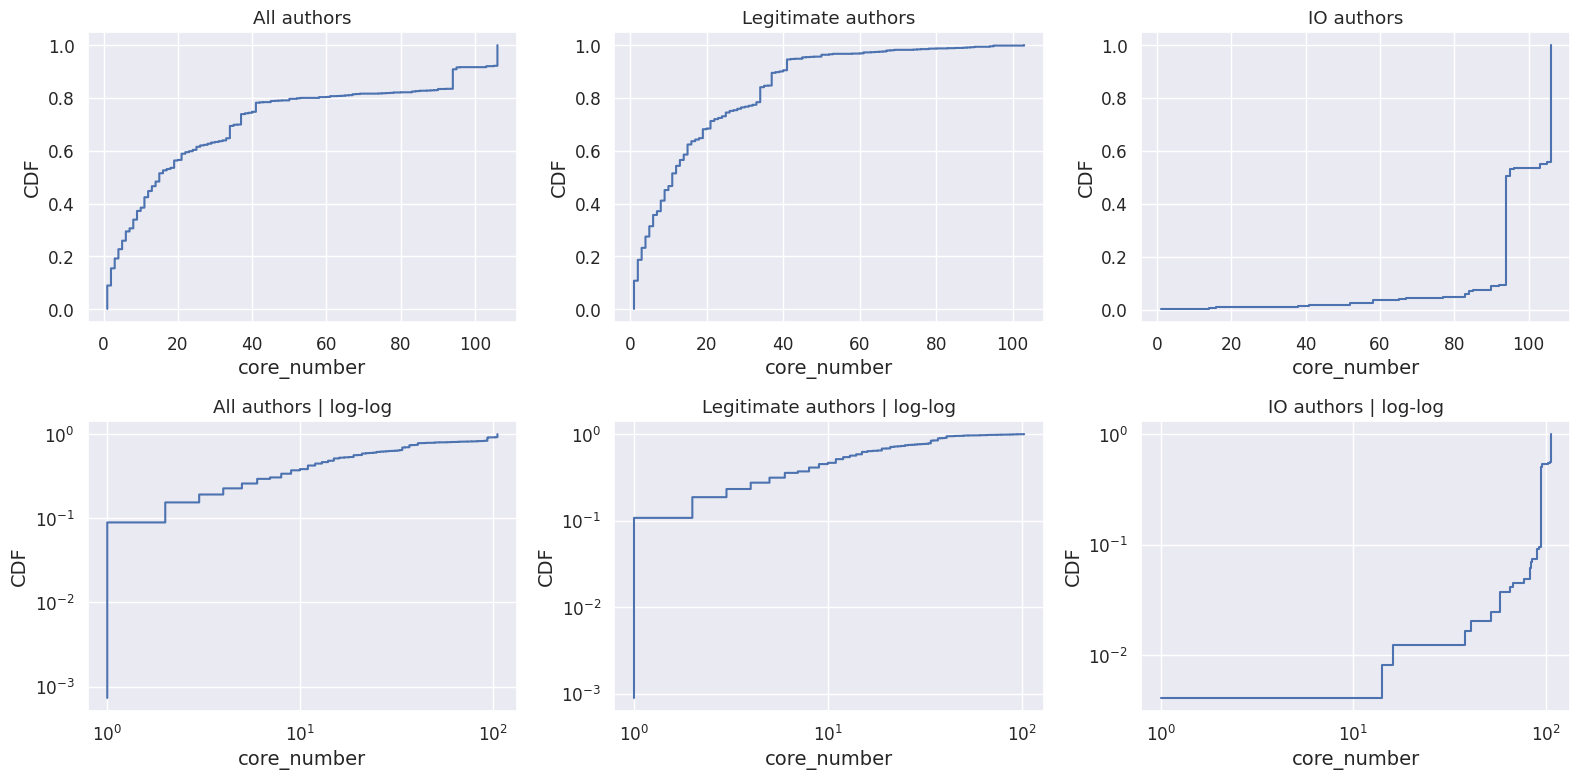

2026-07-07 17:02:23 | Completed: plot_indicator_cdf_subplots


In [103]:
if run_demo:
    indicator_col_h1 = "core_number"
    plot_indicator_cdf_subplots(node_indicators_df, io_authors_set, indicator_col = indicator_col_h1, output_path = folder_output_path)

,core_number,n_authors,io_authors,io_rate,legitimate_authors
0,1,122,1,0.008197,121
1,2,89,0,0.000000,89
2,3,51,0,0.000000,51
3,4,48,0,0.000000,48
4,5,44,0,0.000000,44
...,...,...,...,...,...
75,95,10,7,0.700000,3
76,96,1,1,1.000000,0
77,103,5,3,0.600000,2
78,105,2,2,1.000000,0


Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_counts_by_core_number.png


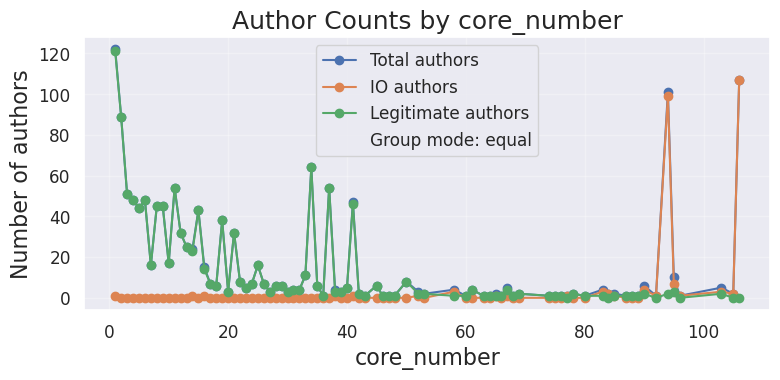

2026-07-07 17:02:23 | Completed: plot_io_counts_by_indicator
[plot_io_rate_by_indicator] Plotting 80 samples with at least 1 authors each.
Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_rate_by_core_number.png


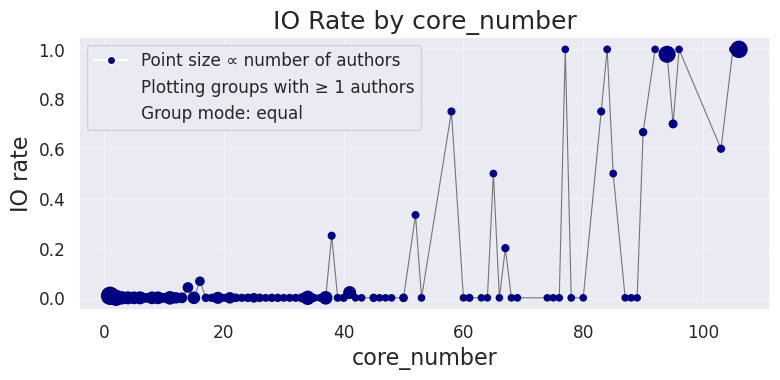

2026-07-07 17:02:24 | Completed: plot_io_rate_by_indicator
                           Logit Regression Results                           
Dep. Variable:              io_status   No. Observations:                 1366
Model:                          Logit   Df Residuals:                     1364
Method:                           MLE   Df Model:                            1
Date:                Tue, 07 Jul 2026   Pseudo R-squ.:                  0.8381
Time:                        17:02:24   Log-Likelihood:                -103.30
converged:                       True   LL-Null:                       -638.00
Covariance Type:            nonrobust   LLR p-value:                1.467e-234
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -8.2639      0.646    -12.791      0.000      -9.530      -6.998
core_number     0.1119      0.008     14.030      0.000       0.096  

In [104]:
if run_demo:
    n_bins = None
    used_bins = n_bins is not None
    group_mode = "equal"

    indicator_io_df_H1 = build_io_rate_by_indicator(node_indicators_df, io_authors_set, indicator_col_h1, n_bins = n_bins)

    
    # plot_indicator_histogram(node_indicators_df, indicator_col, io_authors_set = io_authors_set, log_scale=True, output_path=folder_output_path, n_bins = n_bins)
    plot_io_counts_by_indicator(indicator_io_df_H1,indicator_col_h1,folder_output_path, used_bins, group_mode = group_mode)
    plot_io_rate_by_indicator(indicator_io_df_H1, indicator_col_h1, output_path = folder_output_path, used_bins = used_bins, group_mode = group_mode)
    logit_statistical_test(node_indicators_df, io_authors_set, indicator_col_h1)

,core_number,n_authors,io_authors,io_rate,legitimate_authors,core_number_bin
0,3.5725,402,1,0.002488,401,"(0.895, 6.25]"
1,8.8750,177,0,0.000000,177,"(6.25, 11.5]"
2,14.1250,139,2,0.014388,137,"(11.5, 16.75]"
3,19.3750,94,0,0.000000,94,"(16.75, 22.0]"
4,24.6250,38,0,0.000000,38,"(22.0, 27.25]"
5,29.8750,23,0,0.000000,23,"(27.25, 32.5]"
6,35.1250,136,0,0.000000,136,"(32.5, 37.75]"
7,40.3750,62,2,0.032258,60,"(37.75, 43.0]"
8,45.6250,9,0,0.000000,9,"(43.0, 48.25]"
9,50.8750,13,1,0.076923,12,"(48.25, 53.5]"


Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_counts_by_core_number.png


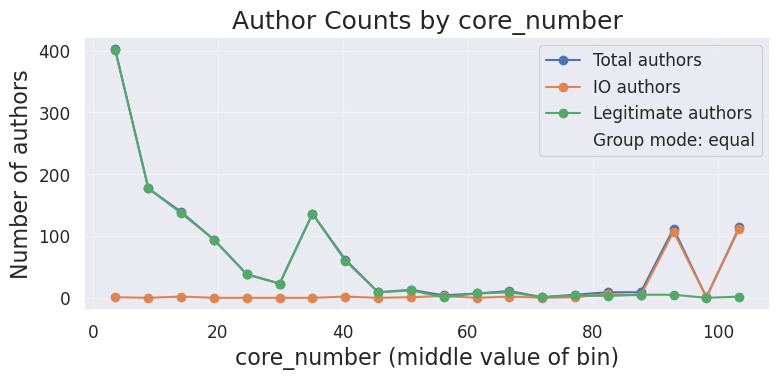

2026-07-07 17:02:24 | Completed: plot_io_counts_by_indicator
[plot_io_rate_by_indicator] Plotting 20 samples with at least 1 authors each.
Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_rate_by_core_number.png


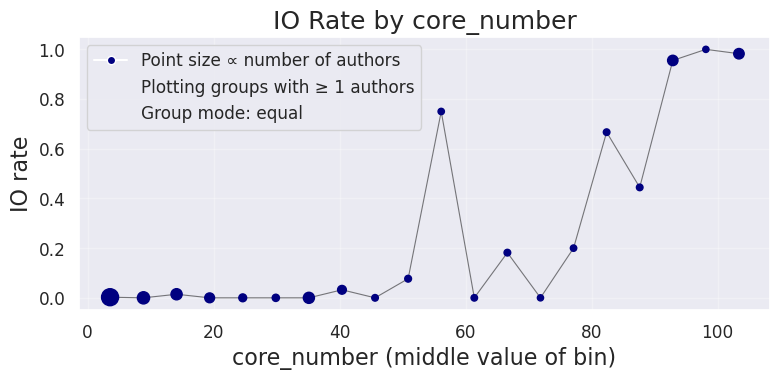

2026-07-07 17:02:24 | Completed: plot_io_rate_by_indicator
                           Logit Regression Results                           
Dep. Variable:              io_status   No. Observations:                 1366
Model:                          Logit   Df Residuals:                     1364
Method:                           MLE   Df Model:                            1
Date:                Tue, 07 Jul 2026   Pseudo R-squ.:                  0.8381
Time:                        17:02:24   Log-Likelihood:                -103.30
converged:                       True   LL-Null:                       -638.00
Covariance Type:            nonrobust   LLR p-value:                1.467e-234
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -8.2639      0.646    -12.791      0.000      -9.530      -6.998
core_number     0.1119      0.008     14.030      0.000       0.096  

In [105]:
if run_demo:
    n_bins = 20
    used_bins = n_bins is not None
    group_mode = "equal"

    indicator_io_df_H1 = build_io_rate_by_indicator(node_indicators_df, io_authors_set, indicator_col_h1, n_bins = n_bins)

    # plot_indicator_histogram(node_indicators_df, indicator_col, io_authors_set = io_authors_set, log_scale=True, output_path=folder_output_path, n_bins = n_bins)
    plot_io_counts_by_indicator(indicator_io_df_H1, indicator_col=indicator_col_h1, output_path=folder_output_path, used_bins = used_bins, group_mode = group_mode)
    plot_io_rate_by_indicator(indicator_io_df_H1, indicator_col=indicator_col_h1, output_path = folder_output_path, used_bins = used_bins, group_mode = group_mode)
    logit_statistical_test(node_indicators_df, io_authors_set, indicator_col=indicator_col_h1)

,core_number,n_authors,io_authors,io_rate,legitimate_authors
0,1,0,0,NaN,0
1,2,122,1,0.008197,121
2,3,211,1,0.004739,210
3,4,262,1,0.003817,261
4,5,310,1,0.003226,309
...,...,...,...,...,...
75,95,1241,122,0.098308,1119
76,96,1251,129,0.103118,1122
77,103,1252,130,0.103834,1122
78,105,1257,133,0.105807,1124


Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_counts_by_core_number.png


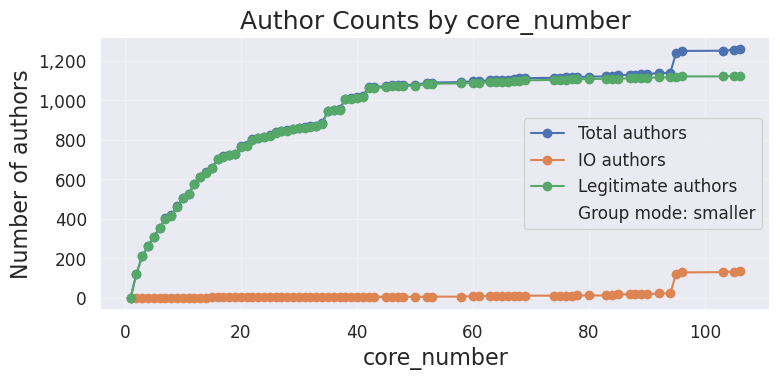

2026-07-07 17:02:25 | Completed: plot_io_counts_by_indicator
[plot_io_rate_by_indicator] Plotting 80 samples with at least 1 authors each.
Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_rate_by_core_number.png


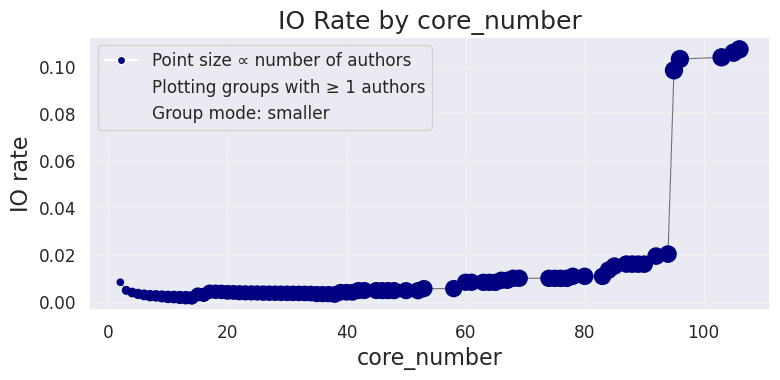

2026-07-07 17:02:25 | Completed: plot_io_rate_by_indicator
                           Logit Regression Results                           
Dep. Variable:              io_status   No. Observations:                 1366
Model:                          Logit   Df Residuals:                     1364
Method:                           MLE   Df Model:                            1
Date:                Tue, 07 Jul 2026   Pseudo R-squ.:                  0.8381
Time:                        17:02:25   Log-Likelihood:                -103.30
converged:                       True   LL-Null:                       -638.00
Covariance Type:            nonrobust   LLR p-value:                1.467e-234
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -8.2639      0.646    -12.791      0.000      -9.530      -6.998
core_number     0.1119      0.008     14.030      0.000       0.096  

In [106]:
if run_demo:
    n_bins = None
    used_bins = n_bins is not None
    group_mode = "smaller"

    indicator_io_df_H1 = build_io_rate_by_indicator(node_indicators_df, io_authors_set, indicator_col_h1, group_mode = group_mode)

    
    # plot_indicator_histogram(node_indicators_df, indicator_col, io_authors_set = io_authors_set, log_scale=True, output_path=folder_output_path, n_bins = n_bins)
    plot_io_counts_by_indicator(indicator_io_df_H1,indicator_col_h1,folder_output_path, used_bins, group_mode = group_mode)
    plot_io_rate_by_indicator(indicator_io_df_H1, indicator_col_h1, output_path = folder_output_path, used_bins = used_bins, group_mode = group_mode)
    logit_statistical_test(node_indicators_df, io_authors_set, indicator_col_h1)

,core_number,n_authors,io_authors,io_rate,legitimate_authors
0,1,1244,241,0.193730,1003
1,2,1155,241,0.208658,914
2,3,1104,241,0.218297,863
3,4,1056,241,0.228220,815
4,5,1012,241,0.238142,771
...,...,...,...,...,...
75,95,115,113,0.982609,2
76,96,114,112,0.982456,2
77,103,109,109,1.000000,0
78,105,107,107,1.000000,0


Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_counts_by_core_number.png


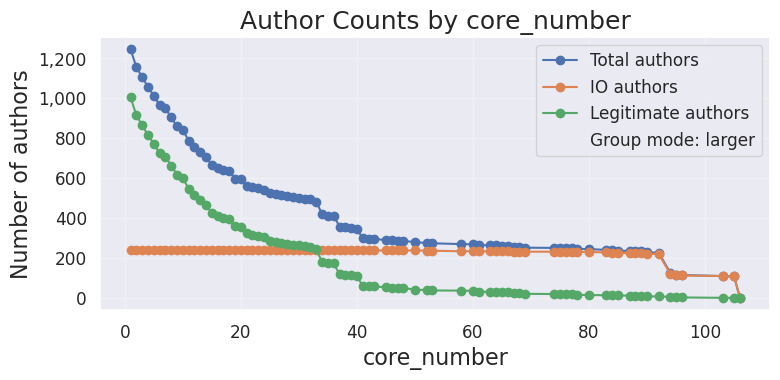

2026-07-07 17:02:26 | Completed: plot_io_counts_by_indicator
[plot_io_rate_by_indicator] Plotting 80 samples with at least 1 authors each.
Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_rate_by_core_number.png


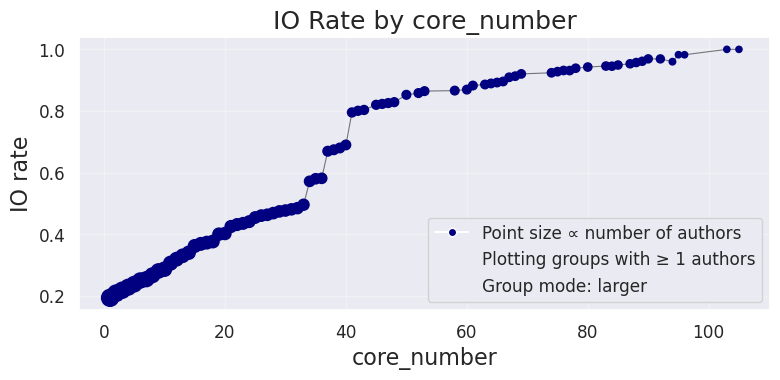

2026-07-07 17:02:26 | Completed: plot_io_rate_by_indicator
                           Logit Regression Results                           
Dep. Variable:              io_status   No. Observations:                 1366
Model:                          Logit   Df Residuals:                     1364
Method:                           MLE   Df Model:                            1
Date:                Tue, 07 Jul 2026   Pseudo R-squ.:                  0.8381
Time:                        17:02:26   Log-Likelihood:                -103.30
converged:                       True   LL-Null:                       -638.00
Covariance Type:            nonrobust   LLR p-value:                1.467e-234
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -8.2639      0.646    -12.791      0.000      -9.530      -6.998
core_number     0.1119      0.008     14.030      0.000       0.096  

In [107]:
if run_demo:
    n_bins = None
    used_bins = n_bins is not None
    group_mode = "larger"

    indicator_io_df_H1 = build_io_rate_by_indicator(node_indicators_df, io_authors_set, indicator_col_h1, group_mode = group_mode)

    
    # plot_indicator_histogram(node_indicators_df, indicator_col, io_authors_set = io_authors_set, log_scale=True, output_path=folder_output_path, n_bins = n_bins)
    plot_io_counts_by_indicator(indicator_io_df_H1,indicator_col_h1,folder_output_path, used_bins, group_mode = group_mode)
    plot_io_rate_by_indicator(indicator_io_df_H1, indicator_col_h1, output_path = folder_output_path, used_bins = used_bins, group_mode = group_mode)
    logit_statistical_test(node_indicators_df, io_authors_set, indicator_col_h1)

## H2 (Community Heterogeneity Hypothesis):
* IO drivers are non-uniformly distributed across communities in the co-action graph.
* Evaluation: Compare IO driver probability across different communities.
* Statistical test: permutation-based chi-square test of homogeneity.
    * Dependent variable: IO status (categorial, 0/1).
    * Independent variable: community membership (categorial).

In [108]:
from scipy.stats import chi2_contingency

@report_done
def permutation_chi2_test(
    node_indicators_df: pd.DataFrame,
    indicator_col: str,
    io_authors_set: set,
    n_permutations: int = 1000,
    random_state: int | None = None,
    alpha: float = 0.05
) -> dict:
    """Permutation-based chi-square test of homogeneity.
    Used for categorical Dependent variable and categorical independent variable.

    Args:
        node_indicators_df (pd.DataFrame):
            DataFrame where index are account IDs and columns include the indicator.
        indicator_col (str):
            Column with indicator values (categorical).
        io_authors_set (set):
            Set of IO author IDs.
        n_permutations (int, optional):
            Number of permutations. Defaults to 1000.
        random_state (int | None, optional):
            Random seed for reproducibility. Defaults to None.
        alpha (float, optional):
            Significance level for hypothesis testing. Defaults to 0.05.

    Returns:
        dict:
            {
                "observed_chi2": float,
                "p_value": float,
                "perm_distribution": np.ndarray
            }
    """
    
    # target_values
    io_authors_set = set(map(str, io_authors_set))
    target_values = node_indicators_df.index.astype(str).isin(io_authors_set).astype(int) 

    # Observed contingency table
    observed_table = pd.crosstab(index = node_indicators_df[indicator_col], columns = target_values)
    observed_chi2, _, _, _ = chi2_contingency(observed_table)

    perm_statistics = np.zeros(n_permutations)


    rng = np.random.default_rng(random_state)
    # Permutation loop
    for i in range(n_permutations):
        rng.shuffle(target_values)  # permute labels

        perm_table = pd.crosstab(index = node_indicators_df[indicator_col], columns = target_values)

        # Align shape
        perm_table = perm_table.reindex_like(observed_table).fillna(0).astype(int)
        
        perm_chi2, _, _, _ = chi2_contingency(perm_table)
        perm_statistics[i] = perm_chi2

    # Empirical p-value
    p_value = (np.sum(perm_statistics >= observed_chi2) + 1) / (n_permutations + 1)


    # print results
    reject = p_value < alpha

    print("\n=== Permutation Chi-Square Test Summary ===")
    print(f"Indicator: {indicator_col}")
    print("Target: IO status (0/1)")
    print(f"Number of permutations: {n_permutations:,}")
    print(f"Observed chi-square: {observed_chi2:.4f}")
    print(f"Empirical p-value: {p_value:.4f}")
    print(f"Significance level (alpha): {alpha}")

    print("\nHypotheses:")
    print(f"H0: Target is independent of the {indicator_col} (uniform distribution across groups).")
    print(f"H1: Target distribution differs across {indicator_col} groups.")

    print("\nConclusion:")
    if reject:
        print("Reject H0 → Evidence of non-uniform distribution (heterogeneity).")
    else:
        print("Fail to reject H0 → No strong evidence of heterogeneity.")

    return {
        "observed_chi2": observed_chi2,
        "p_value": p_value,
        "perm_distribution": perm_statistics,
    }

,louvain_community,n_authors,io_authors,io_rate,legitimate_authors
0,0,2,0,0.000000,2
1,1,295,11,0.037288,284
2,2,3,0,0.000000,3
3,3,249,84,0.337349,165
4,4,5,0,0.000000,5
5,5,18,0,0.000000,18
6,6,113,98,0.867257,15
7,7,3,0,0.000000,3
8,8,404,1,0.002475,403
9,9,2,0,0.000000,2


Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_counts_by_louvain_community.png


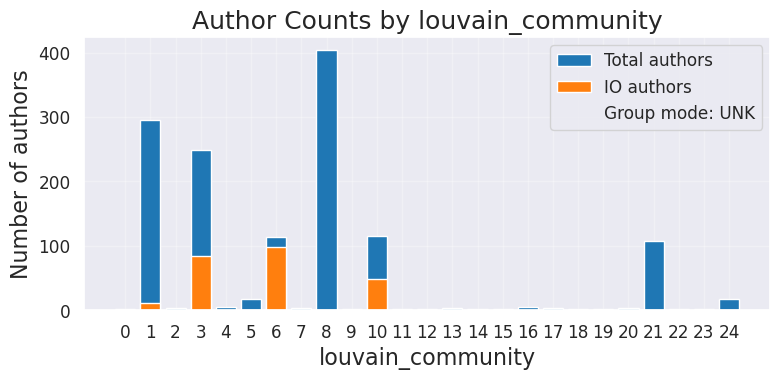

2026-07-07 17:02:26 | Completed: plot_io_counts_by_indicator
[plot_io_rate_by_indicator] Plotting 25 samples with at least 1 authors each.
Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_rate_by_louvain_community.png


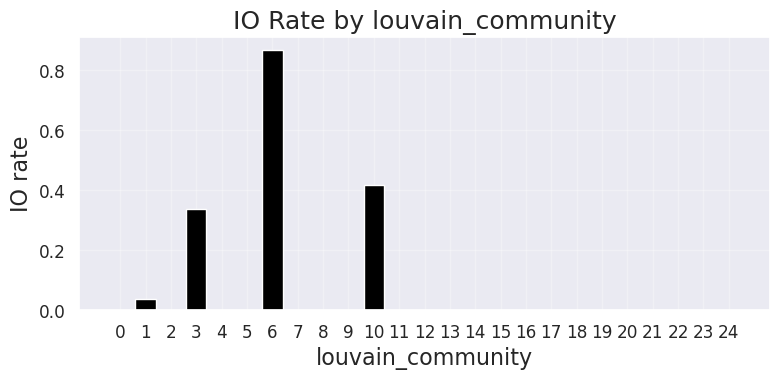

2026-07-07 17:02:27 | Completed: plot_io_rate_by_indicator

=== Permutation Chi-Square Test Summary ===
Indicator: louvain_community
Target: IO status (0/1)
Number of permutations: 1,000
Observed chi-square: 623.5904
Empirical p-value: 0.0010
Significance level (alpha): 0.05

Hypotheses:
H0: Target is independent of the louvain_community (uniform distribution across groups).
H1: Target distribution differs across louvain_community groups.

Conclusion:
Reject H0 → Evidence of non-uniform distribution (heterogeneity).
2026-07-07 17:02:32 | Completed: permutation_chi2_test


In [109]:
if run_demo:
    indicator_col_H2_community = "louvain_community"

    indicator_io_df_H2  = build_io_rate_by_indicator(node_indicators_df, io_authors_set, indicator_col_H2_community)

    plot_io_counts_by_indicator(indicator_io_df_H2, indicator_col_H2_community, folder_output_path, used_bins = False, graph_type="bar")
    plot_io_rate_by_indicator(indicator_io_df_H2, indicator_col_H2_community, output_path = folder_output_path, graph_type="bar")
    permutation_chi2_test(node_indicators_df, indicator_col_H2_community, io_authors_set=io_authors_set)

,top_topic,n_authors,io_authors,io_rate,legitimate_authors
0,-1,27,0,0.000000,27
1,0,294,113,0.384354,181
2,1,37,0,0.000000,37
3,2,39,0,0.000000,39
4,3,38,11,0.289474,27
5,4,37,1,0.027027,36
6,5,41,0,0.000000,41
7,6,16,0,0.000000,16
8,7,13,0,0.000000,13
9,8,16,0,0.000000,16


Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_counts_by_top_topic.png


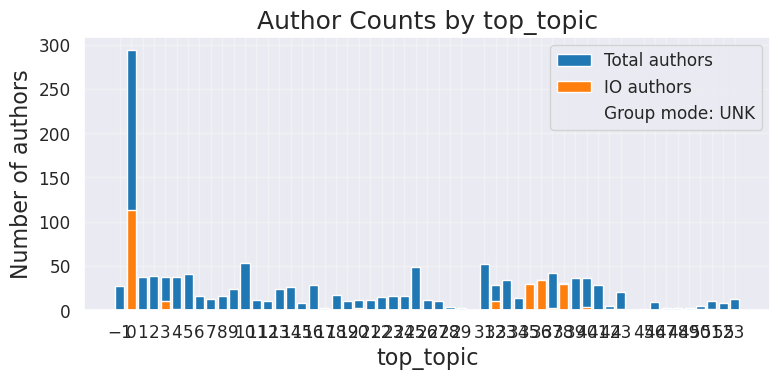

2026-07-07 17:02:33 | Completed: plot_io_counts_by_indicator
[plot_io_rate_by_indicator] Plotting 53 samples with at least 1 authors each.
Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_07_07/io_rate_by_top_topic.png


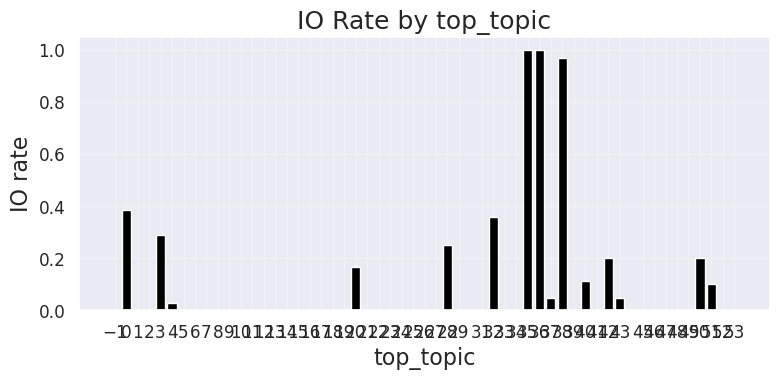

2026-07-07 17:02:33 | Completed: plot_io_rate_by_indicator

=== Permutation Chi-Square Test Summary ===
Indicator: top_topic
Target: IO status (0/1)
Number of permutations: 1,000
Observed chi-square: 700.0210
Empirical p-value: 0.0010
Significance level (alpha): 0.05

Hypotheses:
H0: Target is independent of the top_topic (uniform distribution across groups).
H1: Target distribution differs across top_topic groups.

Conclusion:
Reject H0 → Evidence of non-uniform distribution (heterogeneity).
2026-07-07 17:02:39 | Completed: permutation_chi2_test


In [110]:
if run_demo:
    indicator_col_H2_topic = "top_topic"

    indicator_io_df_H2  = build_io_rate_by_indicator(node_indicators_df, io_authors_set, indicator_col_H2_topic)

    plot_io_counts_by_indicator(indicator_io_df_H2, indicator_col_H2_topic, folder_output_path, used_bins = False, graph_type="bar")
    plot_io_rate_by_indicator(indicator_io_df_H2, indicator_col_H2_topic, min_support= 1, output_path = folder_output_path, graph_type="bar")
    permutation_chi2_test(node_indicators_df, indicator_col_H2_topic, io_authors_set=io_authors_set)

In [111]:
from scipy.stats import chi2_contingency
import numpy as np

if run_demo:
    contingency_table = pd.crosstab(
        node_indicators_df[indicator_col_H2_community],
        node_indicators_df[indicator_col_H2_topic]
    )

    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.to_numpy().sum()

    cramers_v = np.sqrt(
        chi2 / (n * (min(contingency_table.shape) - 1))
    )

    print(f"Cramér’s V: {cramers_v:.4f}")

Cramér’s V: 0.4183


## H3 (Narrative Amplification Hypothesis):
* The key score provides additional predictive value for IO classification beyond coordination-based indicators. 
* Evaluation: Compare classification model performance with and without the key score feature.
* Statistical test: DeLong test.
    * Dependent variable: Models’ AUC (numeric).
    * Independent variable: Inclusion of key score (categorical, 0/1).

In [112]:
if run_demo:

    write_report("Starting H3 (Narrative Amplification Hypothesis)")

    print(f"Node indicators DataFrame columns: {node_indicators_df.columns.tolist()}")

    node_indicators_df_no_key = node_indicators_df.drop(columns=['key_score_sum', 'key_score_dominance', 'posting_dominance', 'boost_score', 'top_topic'])

    classifiers = ["random_forest", "xgboost", "logistic_regression"]

    node_indicator_tables = {"with_key": node_indicators_df, "no_key": node_indicators_df_no_key,}

    results_h3 = {}

    for clf_name in classifiers:
        print(f"\n=== Training and evaluating {clf_name} classifier ===")

        for feature_set_name, indicators_df in node_indicator_tables.items():

            clf, report, auc, f1, y_test, y_proba_test = io_classification(
                indicators_df,
                io_authors_set,
                clf_name,
                random_state=42 # random_state must be the same for io_classification to compare between the models

            )

            clf_result_name = f"{clf_name}_{feature_set_name}"

            print(f"{clf_result_name}: AUC: {auc:.4f}, F1: {f1:.4f}")

            results_h3[clf_result_name] = {
                "auc": auc,
                "f1": f1,
                "y_test": y_test,
                "y_proba_test": y_proba_test,
                "report": report,
            }

2026-07-07 17:02:39 | Starting H3 (Narrative Amplification Hypothesis)
Node indicators DataFrame columns: ['degree_centrality', 'harmonic_centrality', 'eigenvector_centrality', 'betweenness_centrality', 'pagerank', 'core_number', 'clustering', 'square_clustering', 'louvain_community', 'key_score_sum', 'key_score_dominance', 'posting_dominance', 'boost_score', 'top_topic']

=== Training and evaluating random_forest classifier ===
Training set: 1092 samples, Test set: 274 samples
2026-07-07 17:02:40 | Completed: io_classification
random_forest_with_key: AUC: 0.9870, F1: 0.9796
Training set: 1092 samples, Test set: 274 samples
2026-07-07 17:02:40 | Completed: io_classification
random_forest_no_key: AUC: 0.9878, F1: 0.9796

=== Training and evaluating xgboost classifier ===
Training set: 1092 samples, Test set: 274 samples
2026-07-07 17:02:40 | Completed: io_classification
xgboost_with_key: AUC: 0.9946, F1: 0.9600
Training set: 1092 samples, Test set: 274 samples
2026-07-07 17:02:40 | Comp

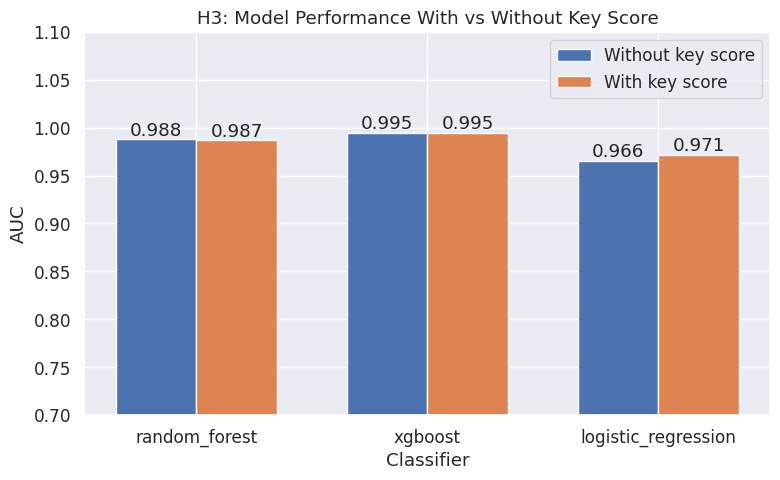

In [113]:
if run_demo:
    auc_with_key = [
        results_h3[f"{clf_name}_with_key"]["auc"]
        for clf_name in classifiers
    ]

    auc_no_key = [
        results_h3[f"{clf_name}_no_key"]["auc"]
        for clf_name in classifiers
    ]

    x = np.arange(len(classifiers))
    width = 0.35

    plt.figure(figsize=(8, 5))

    bars_no_key = plt.bar(
        x - width / 2,
        auc_no_key,
        width,
        label="Without key score",
    )

    bars_with_key = plt.bar(
        x + width / 2,
        auc_with_key,
        width,
        label="With key score",
    )

    # Optional: show values on bars
    plt.bar_label(bars_no_key, fmt="%.3f")
    plt.bar_label(bars_with_key, fmt="%.3f")

    plt.xticks(x, classifiers)
    plt.ylabel("AUC")
    plt.xlabel("Classifier")
    plt.title("H3: Model Performance With vs Without Key Score")
    plt.legend()
    plt.ylim(0.7, 1.1)
    plt.tight_layout()

    plt.show()

In [114]:
if run_demo:    
    from MLstatkit.stats import Delong_test
    import numpy as np

    for clf_name in classifiers:
        with_key = results_h3[f"{clf_name}_with_key"]
        no_key = results_h3[f"{clf_name}_no_key"]

        # Same ground-truth labels required
        assert np.array_equal(with_key["y_test"], no_key["y_test"],), "Test labels differ between models"


        true = with_key["y_test"]  # or no_key["y_test"], they are the same
        prob_A = with_key["y_proba_test"]
        prob_B = no_key["y_proba_test"]
        z_score, p_value = Delong_test(true, prob_A, prob_B, return_ci=False, return_auc=False, verbose=0)

        print(f"\n=== {clf_name} DeLong test ===")
        print(f"AUC (with key): {with_key['auc']:.4f}")
        print(f"AUC (no key):   {no_key['auc']:.4f}")
        auc_delta = with_key['auc'] - no_key['auc']
        print(f"ΔAUC:           {auc_delta:.4f} {auc_delta / no_key['auc'] * 100:.2f}%")
        print(f"Z-score:        {z_score:.4f}")
        print(f"P-value:        {p_value:.4g}")


    write_report("H3 analysis completed.")


=== random_forest DeLong test ===
AUC (with key): 0.9870
AUC (no key):   0.9878
ΔAUC:           -0.0008 -0.08%
Z-score:        0.7555
P-value:        0.4499

=== xgboost DeLong test ===
AUC (with key): 0.9946
AUC (no key):   0.9948
ΔAUC:           -0.0002 -0.02%
Z-score:        0.2319
P-value:        0.8166

=== logistic_regression DeLong test ===
AUC (with key): 0.9714
AUC (no key):   0.9657
ΔAUC:           0.0057 0.59%
Z-score:        -0.7673
P-value:        0.4429
2026-07-07 17:02:40 | H3 analysis completed.


/tmp/ipykernel_2010299/1436103724.py:2: UserWarning: Importing from MLstatkit.stats is deprecated and will be removed in v0.2.0. Please use `from MLstatkit import ...` instead.
  from MLstatkit.stats import Delong_test


## H4 (Topic Interpretability Hypothesis):
* Topic modelling reveals coherent topics and narratives that improve understanding of the campaign’s objectives, messaging strategies, and targeted audience.
* Evaluation: Analyse discovered topics and representative posts over the campaign timeline to identify narrative evolution and event alignment.
* Test: Coloured topic graphs, campaign timeline, posts-events alignment.

In [115]:
# Done in Gephi outside of this notebook.
# See `add_nodes_labels_for_topic` in this notebook for the code used to prepare the node labels for Gephi.

# Indicator Based Graph Filtering

In [116]:
@report_done
def filter_graph_by_indicators(
    G: nx.Graph,
    indicator_name: str,
    threshold_percentage: float = 1,
    node_indicator_dict: dict | None = None,
    key_authors_mode: str = "global",
    df: pd.DataFrame | None = None,
    topic_col: str | None = None,
    author_col: str = "accountid",
    author_score_col: str = "topic_author_key_score",
    base_number: int = 5,
) -> nx.Graph:
    """Filter graph nodes by top indicator values or per-topic key authors.

    Args:
        G: Input graph.
        indicator_name: Indicator name to use for filtering.
        threshold_percentage: Percentage of top nodes to keep, in (0, 100].
            Values in (0, 1) are treated as fractions.
        node_indicator_dict: Optional dict mapping node to indicator value.
        key_authors_mode: Filtering mode. Either "global" or "per_topic".
        df: Input dataframe, required for "per_topic" mode.
        topic_col: Topic column, required for "per_topic" mode.
        author_col: Author id column.
        author_score_col: Author score column for per-topic mode.
        base_number: Base number of authors per topic.

    Returns:
        A filtered graph containing only selected nodes.
    """
    if threshold_percentage <= 0 or threshold_percentage > 100:
        raise ValueError(
            f"threshold_percentage must be in (0, 100], got {threshold_percentage}"
        )

    if threshold_percentage < 1:
        threshold_percentage *= 100
        print(
            "[filter_graph_by_indicators] WARNING: "
            f"interpreting fraction as percentage: {threshold_percentage}%"
        )

    mode = key_authors_mode.strip().lower().replace(" ", "_")

    if mode not in {"global", "per_topic"}:
        raise ValueError(
            f"Invalid key_authors_mode={key_authors_mode!r}. "
            "Use 'global' or 'per_topic'."
        )

    if mode == "per_topic":
        if df is None:
            raise ValueError("df is required when key_authors_mode='per_topic'.")
        if topic_col is None:
            raise ValueError("topic_col is required when key_authors_mode='per_topic'.")

        selected_authors = get_all_topics_key_authors(
            df=df,
            author_score_col=author_score_col,
            author_col=author_col,
            topic_col=topic_col,
            key_authors_mode=mode,
            base_number=base_number,
            top_percentage=threshold_percentage,
        )

        graph_nodes_by_str = {str(node): node for node in G.nodes}
        nodes_to_keep = {
            graph_nodes_by_str[str(author)]
            for author in selected_authors
            if str(author) in graph_nodes_by_str
        }

    else:
        if node_indicator_dict is not None:
            print(
                f"[filter_graph_by_indicators] Using provided node_indicator_dict "
                f"for '{indicator_name}'."
            )
            raw_indicator = node_indicator_dict

        else:
            print(
                f"[filter_graph_by_indicators] Trying node attributes "
                f"for '{indicator_name}'."
            )

            raw_indicator = nx.get_node_attributes(G, indicator_name)

            if not raw_indicator:
                print(
                    f"[filter_graph_by_indicators] Node attribute '{indicator_name}' "
                    "not found. Computing indicator with _compute_indicator."
                )

                global _GRAPH
                _GRAPH = G

                _, raw_indicator, _ = _compute_indicator(indicator_name)

        indicator_by_str_node = {
            str(node): value
            for node, value in raw_indicator.items()
            if pd.notna(value)
        }

        missing_nodes = [
            node for node in G.nodes
            if str(node) not in indicator_by_str_node
        ]

        if missing_nodes:
            raise KeyError(
                f"Missing '{indicator_name}' for {len(missing_nodes):,} "
                f"nodes ({len(missing_nodes) / G.number_of_nodes():.1%})."
            )

        graph_nodes_by_str = {str(node): node for node in G.nodes}

        values = sorted(indicator_by_str_node.values(), reverse=True)
        num_to_keep = max(1, int(len(values) * threshold_percentage / 100))
        threshold_value = values[num_to_keep - 1]

        nodes_to_keep = {
            graph_nodes_by_str[node_str]
            for node_str, value in indicator_by_str_node.items()
            if value >= threshold_value
        }

    G_filtered = G.subgraph(nodes_to_keep).copy()

    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    n_nodes_f = G_filtered.number_of_nodes()
    n_edges_f = G_filtered.number_of_edges()

    node_ratio = n_nodes_f / n_nodes if n_nodes else 0
    edge_ratio = n_edges_f / n_edges if n_edges else 0

    print(
        f"""[filter_graph_by_indicators]
    {indicator_name} | top {threshold_percentage}%

    Nodes: {n_nodes:,} → {n_nodes_f:,} ({node_ratio:.1%})
    Edges: {n_edges:,} → {n_edges_f:,} ({edge_ratio:.1%})
    """
    )

    return G_filtered

In [117]:
# import networkx as nx
# import pandas as pd

# folder_path = Path("../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_03_29")
# G_accounts = nx.read_gexf(folder_path / "BERTopic_topic_512_accounts_graph.gexf")
# node_indicators_df = pd.read_parquet(folder_path / "node_indicators.parquet")

In [118]:
@report_done
def build_and_plot_filtered_graphs_by_indicator(
    G: nx.Graph,
    indicator_name: str,
    indicator_threshold_percentages: list[float],
    layout: str | dict | list[str | dict] = "random",
    folder_output_path: str | Path | None = None,
    key_authors_mode: str | None = 'global',
    df: pd.DataFrame | None = None,
    topic_col: str | None = None,
    author_col: str = "accountid",
    author_score_col: str = "topic_author_key_score",
    base_number: int = 5,
    node_indicator_dict: dict | None = None,
) -> None:
    """Filter graph by indicator thresholds and plot as subplots.

    Args:
        G: Original graph.
        indicator_name: Indicator used for filtering.
        indicator_threshold_percentages: List of thresholds (e.g., [1, 5, 10]).
        layout: Layout name, NetworkX pos dict, or list of names/pos dicts for subplots.
        folder_output_path: Optional path to save plot.
        key_authors_mode: Optional key-author mode passed to filter_graph_by_indicators.
        df: DataFrame containing the data (required for 'per_topic' mode).
        topic_col: Topic column name used in per_topic mode.
        author_col: Author identifier column for key-author selection.
        author_score_col: Score column for per_topic key-author selection.
        base_number: Base number of authors per topic for per_topic mode.
        node_indicator_dict: Optional flat dict {node_id: indicator_value} passed to filtering in global mode.
    Returns:
        None. Displays and optionally saves subplot figure.
    """

    filtered_graph_name = (
        G.graph.get("name", "accounts_graph")
        + f"_filtered_by_{indicator_name}"
    )

    print(f"[plot_filtered_graphs_by_indicator] Building {len(indicator_threshold_percentages)} filtered graphs...")

    graphs = []
    sub_plot_titles = []

    for threshold in tqdm(indicator_threshold_percentages, desc="Filtering graphs"):
        sub_plot_title = f"Top {threshold}% {indicator_name}"

        G_filtered = filter_graph_by_indicators(
            G=G,
            indicator_name=indicator_name,
            threshold_percentage=threshold,
            node_indicator_dict=node_indicator_dict,
            key_authors_mode=key_authors_mode,
            df=df,
            topic_col=topic_col,
            author_col=author_col,
            author_score_col=author_score_col,
            base_number=base_number,
        )

        graphs.append(G_filtered)
        sub_plot_titles.append(sub_plot_title)

    layout_for_plot = layout

    if not isinstance(layout, list):
        if not graphs:
            raise ValueError("indicator_threshold_percentages must contain at least one threshold.")

        largest_graph = max(
            graphs,
            key=lambda graph: (graph.number_of_nodes(), graph.number_of_edges()),
        )

        print(
            "[plot_filtered_graphs_by_indicator] Preparing shared layout from largest "
            f"filtered graph with {largest_graph.number_of_nodes():,} nodes and "
            f"{largest_graph.number_of_edges():,} edges."
        )

        if isinstance(layout, str):
            largest_pos = _get_pos(largest_graph, layout)
        elif isinstance(layout, dict):
            largest_pos = _validate_pos(largest_graph, layout)
        else:
            raise ValueError(
                "layout must be a layout name string, a NetworkX pos dict, "
                "or a list of strings/pos dicts."
            )

        layout_for_plot = [_subset_pos_for_graph(largest_pos, graph) for graph in graphs]

    print(f"[plot_filtered_graphs_by_indicator] Plotting {len(graphs)} filtered graphs by indicator '{indicator_name}' with layout '{_layout_label(layout_for_plot)}'...")

    plot_accounts_graph(
        G=graphs,
        title=sub_plot_titles,
        graph_name=filtered_graph_name,
        folder_output_path=folder_output_path,
        layout=layout_for_plot,
    )

## Runing

### Parameters

In [119]:
if run_graph_filtering:

    write_report("Starting graph filtering by indicators...")
        
    layout_name_for_filtered_graph = "random"
    indicator_name_for_filtering = "core_number"
    indicator_threshold_percentages = [100, 50, 25, 10, 5, 1]

    folder_output_path_for_filtered_graph = folder_output_path / f"graphs_filtered_by_{indicator_name_for_filtering}"
    folder_output_path_for_filtered_graph.mkdir(exist_ok=True)

    print(f"Filtering graph by indicator '{indicator_name_for_filtering}' with thresholds: {indicator_threshold_percentages}%")
    print(f"topic col = {topic_col}")
    print(f"For KeyScore Filtering, key mode is 'per_topic' and for {indicator_name_for_filtering} filtering, key mode is 'global'.")

### Utils

In [120]:
if run_graph_filtering:
    
    G_no_filtering = build_accounts_graph(
        df=df,
        account_relations=account_relations,
        io_authors=io_authors_set,
        # all_topics_key_authors_set=all_topics_key_authors_set, # not using filtering
        author_topic_key_score_df=author_topic_key_score_df,  # for node labels.
        boost_score_df=boost_df,
        is_directed_graphs= False,
        topic_col=topic_col,
        author_col=account_id_col,
        graph_name="accounts_graph_no_filtering",
    )


    node_indicator_G_no_filtering = compute_indicators(G_no_filtering, folder_output_path)

### Only KeyScore Filtering

In [121]:
# only KeyScore filtering (per topic)

if run_graph_filtering:

    print("only KeyScore filtering")

    build_and_plot_filtered_graphs_by_indicator(
        G=G_no_filtering,
        indicator_name=author_key_score_col, # topic_author_key_score
        indicator_threshold_percentages=indicator_threshold_percentages,
        layout=layout_name_for_filtered_graph,
        folder_output_path=folder_output_path_for_filtered_graph,
        key_authors_mode='per_topic',
        df=df,
        topic_col=topic_col,
        author_col=account_id_col,
        author_score_col=author_key_score_col,
    )

### Only k-core Filtering

In [122]:
# if run_graph_filtering:

#     print("only core_number filtering")

#     build_and_plot_filtered_graphs_by_indicator(
#         G=G_no_filtering,
#         indicator_name=indicator_name_for_filtering, # "core_number"
#         indicator_threshold_percentages=indicator_threshold_percentages,
#         layout=layout_name_for_filtered_graph,
#         folder_output_path=folder_output_path_for_filtered_graph,
#     )

### KeyScore Filtering --> Core Number Filtering

In [123]:
# if run_graph_filtering:

#     print("KeyScore Filtering --> Core Number Filtering")

#     print(f"Top key authors percentage = {top_percentage}")

#     build_and_plot_filtered_graphs_by_indicator(
#         G=G_accounts,
#         indicator_name=indicator_name_for_filtering, # "core_number"
#         indicator_threshold_percentages=indicator_threshold_percentages,
#         layout=layout_name_for_filtered_graph,
#         folder_output_path=folder_output_path_for_filtered_graph,
#     )

### Core Number Filtering --> KeyScore Filtering

In [124]:
# if run_graph_filtering:
    
#     threshold_percentage_core_number = 10

#     print(f"threshold_percentage_core_number = {threshold_percentage_core_number}")


#     G_core_number_filtered = filter_graph_by_indicators(
#         G=G_no_filtering,
#         indicator_name = indicator_name_for_filtering, # "core_number"
#         threshold_percentage=threshold_percentage_core_number,
#     )


#     build_and_plot_filtered_graphs_by_indicator(
#         G=G_core_number_filtered,
#         indicator_name=author_key_score_col, # topic_author_key_score
#         indicator_threshold_percentages=indicator_threshold_percentages,
#         layout=layout_name_for_filtered_graph,
#         folder_output_path=folder_output_path_for_filtered_graph,
#         key_authors_mode='per_topic',
#         df=df,
#         topic_col=topic_col,
#         author_col=account_id_col,
#         author_score_col=author_key_score_col,
#     )

# Parameter Sweep: Information Gain and AUC Analysis

This section implements functions to run key_authors_graph with different min_topic_size, top_percentage, and key_authors_mode values, compute total information gain, and visualize the results.

In [125]:
from itertools import product
from typing import Iterable, Sequence

from concurrent.futures import ProcessPoolExecutor
import os

import pandas as pd

import gc # garbage collector

## One Experiment

In [126]:
def run_io_indicator_ig_experiment(
    df: pd.DataFrame,
    topic_col: str,
    top_percentage: float,
    account_relations: Iterable[tuple[str, str]],
    is_directed_graphs: bool,
    author_col: str = "accountid",
    is_io_control_col: str = "is_control",
    io_threshold: float = 0.33,
    min_posts: int = 5,
    key_authors_mode: str = "per_topic",
    entity_cols_lst: list[str] = ["hashtags", "account_mentions", "urls", "ner_entities"],
    author_topic_key_score_df: pd.DataFrame | None = None, # (rows = authors, columns = topics, values = author-topic score)
    io_authors_set: set | None = None, # set of authors that are labeled as IO. If not provided, it will be computed.
    boost_score_df: pd.DataFrame | None = None, # Optional DataFrame with columns [accountid, boost_score].
    output_folder_path : str | Path | None = None, # Optional path to save node indicators.
) -> pd.DataFrame:
    """Run a full IO experiment pipeline and return summary metrics.

    Pipeline:
      1) Use the provided topic_col
      2) get_io_authors_by_ratio(...) -> io_authors
      3) get_all_topics_key_authors(...) -> all_topics_key_authors_set
      4) Boost authors: merge boost_authors_set into all_topics_key_authors_set (if boost_score_df provided)
      5) build_accounts_graph(...) -> G
      6) compute_indicators(G) -> node_indicators_df
      7) compute_centrality_information_gain(...) -> IG per indicator (for both key_authors and all_authors variants)
      8) compute AUC for RF, XGBoost, and Logistic Regression on node indicators (for both key_authors and all_authors variants)
      9) return IG + AUC summary metrics.

    Returns:
        Single-row DataFrame with topic_col, top_percentage,
        key_authors_mode, is_directed_graphs, IG and AUC metrics for both
        key_authors and all_authors variants, and helpful counts.
    """

    write_report(f"Running [run_io_indicator_ig_experiment] for topic_col='{topic_col}', top_percentage={top_percentage}%, key_authors_mode='{key_authors_mode}', is_directed_graphs={is_directed_graphs}...")
    
    mode = key_authors_mode.strip().lower().replace(" ", "_")
    assert mode in ("per_topic", "global"), (
        f"Invalid key_authors_mode: {key_authors_mode!r}. Use 'per_topic' or 'global'."
    )

    if topic_col not in df.columns:
        raise KeyError(f"[MY ERROR] topic_col '{topic_col}' not found in df.columns")

    # ---------- 1) IO authors ----------
    if io_authors_set is None:
        io_authors_set = get_io_authors_by_ratio(
            df=df,
            author_col=author_col,
            is_io_control_col=is_io_control_col,
            io_threshold=io_threshold,
            min_posts=min_posts,
        )
        io_authors_set = set(map(str, io_authors_set))

    # ---------- 2) key authors ----------

    post_score_col = f"post_tfidf_{topic_col}"
    author_score_col = f"topic_author_key_score_{topic_col}"


    if post_score_col not in df.columns:
        print(f"Computing post-level TF-IDF scores for topic_col '{topic_col}' and saving to column '{post_score_col}'")
        compute_post_tfidf(df, topic_col, entity_cols_lst, post_score_col)

    to_delate_author_topic_key_score_df = False
    if author_score_col not in df.columns or author_topic_key_score_df is None:
        print(f"[run_io_indicator_ig_experiment] Computing author-topic key scores for topic_col '{topic_col}' and saving to column '{author_score_col}'")
        # author_topic_key_score_df (rows = authors, columns = topics, values = author-topic score)
        author_topic_key_score_df = compute_author_key_score(
            df=df,
            topic_col=topic_col,
            author_col=author_col,
            post_score_col=post_score_col,
            author_score_col=author_score_col,
        )
        to_delate_author_topic_key_score_df =  True

    all_topics_key_authors_set = get_all_topics_key_authors(
        df=df,
        author_score_col=author_score_col,
        author_col=author_col,
        topic_col=topic_col,
        key_authors_mode=mode,
        base_number=10,
        top_percentage=top_percentage,
    )


    # ---------- 3) Boost authors ----------
    if boost_score_df is not None:
        # Boost scores are global (not topic-specific), so use global mode.
        boost_authors_set = get_all_topics_key_authors(
            df=boost_score_df,
            author_score_col="boost_score",
            author_col=author_col,
            topic_col=None,
            key_authors_mode="global",
            base_number=10,
            top_percentage=top_percentage,
        )
        # Merge boost authors into key authors set so both are included in the graph.
        all_topics_key_authors_set = all_topics_key_authors_set.union(boost_authors_set)


    # ---------- 4) build graph ----------
    G = build_accounts_graph(
        df=df,
        account_relations=account_relations,
        io_authors=io_authors_set,
        all_topics_key_authors_set=all_topics_key_authors_set,
        author_topic_key_score_df=author_topic_key_score_df,  # for node labels.
        boost_score_df=boost_score_df,
        is_directed_graphs=is_directed_graphs,
        topic_col=topic_col,
        author_col=author_col,
        graph_name=f"accounts_graph_top_percentage_{top_percentage}_{mode}_key_authors"
    )

    # ---------- 5) compute indicators ----------
    using_ner_entities_in_graph = any("ner" in relation_col.lower() for relation in account_relations for relation_col in relation)

    key_authors_indicators_folder_name = ("node_indicators_only_key_authors_with_ner" if using_ner_entities_in_graph else "node_indicators_only_key_authors_without_ner")
    node_indicators_df_only_key_authors_folder = output_folder_path / key_authors_indicators_folder_name
    node_indicators_df_only_key_authors_folder.mkdir(parents=True, exist_ok=True)
    node_indicators_df = compute_indicators(G, node_indicators_df_only_key_authors_folder)

    # ---------- 6) Preparation ----------
    all_authors = df[author_col].astype(str).unique()
    node_indicators_df_all_authors = add_missing_authors_with_zeros(node_indicators_df, all_authors)

    # save indicators DataFrames to use for classification analysis.
    all_authors_indicators_folder_name = ("node_indicators_all_authors_with_ner" if using_ner_entities_in_graph else "node_indicators_all_authors_without_ner")
    node_indicators_df_all_authors_path = output_folder_path / all_authors_indicators_folder_name / f"{G.name}_node_indicators.parquet"
    node_indicators_df_all_authors_path.parent.mkdir(parents=True, exist_ok=True,)
    node_indicators_df_all_authors.to_parquet(node_indicators_df_all_authors_path, index=True, compression="gzip")
    write_report(f"node_indicators_df_all_authors is saved to: {node_indicators_df_all_authors_path}")


    # ---------- 7) IG - key authors variant ----------
    ig_series_key_authors = compute_indicators_information_gain(node_indicators_df, io_authors_set)

    ig_series_key_authors = pd.to_numeric(ig_series_key_authors, errors="coerce").dropna()

    ig_sum_key_authors = float(ig_series_key_authors.sum())
    ig_mean_key_authors = float(ig_series_key_authors.mean())

    # ---------- 7) IG - all authors variant ----------
    ig_series_all_authors = compute_indicators_information_gain(node_indicators_df_all_authors,io_authors_set)

    ig_series_all_authors = pd.to_numeric(ig_series_all_authors, errors="coerce").dropna()

    ig_sum_all_authors = float(ig_series_all_authors.sum())
    ig_mean_all_authors = float(ig_series_all_authors.mean())

    # ---------- 8) AUC - key authors variant ----------
    auc_rf_key_authors = io_classification(node_indicators_df, io_authors_set, "random_forest", folder_output_path)[2] # save only auc
    auc_xgb_key_authors = io_classification(node_indicators_df, io_authors_set, "xgboost", folder_output_path)[2] # save only auc
    auc_lr_key_authors = io_classification(node_indicators_df, io_authors_set, "logistic_regression", folder_output_path)[2] # save only auc

    auc_best_key_authors = max(auc_rf_key_authors, auc_xgb_key_authors, auc_lr_key_authors)

    # ---------- 8) AUC - all authors variant ----------
    auc_rf_all_authors = io_classification(node_indicators_df_all_authors, io_authors_set, "random_forest", folder_output_path)[2] # save only auc
    auc_xgb_all_authors = io_classification(node_indicators_df_all_authors, io_authors_set, "xgboost", folder_output_path)[2] # save only auc
    auc_lr_all_authors = io_classification(node_indicators_df_all_authors, io_authors_set, "logistic_regression", folder_output_path)[2] # save only auc

    auc_best_all_authors = max(auc_rf_all_authors, auc_xgb_all_authors, auc_lr_all_authors)

    # ---------- 9) Memory Clean ----------

    n_indicators = len(ig_series_key_authors)
    n_io_authors = len(io_authors_set)
    n_nodes = node_indicators_df.shape[0]

    del G
    del node_indicators_df
    del node_indicators_df_all_authors
    del ig_series_key_authors
    del ig_series_all_authors
    del all_topics_key_authors_set
    if to_delate_author_topic_key_score_df: # created in this function
        del author_topic_key_score_df
    gc.collect()

    # ---------- output ----------
    return pd.DataFrame([{
        "topic_col": topic_col,
        "top_percentage": float(top_percentage),
        "key_authors_mode": mode,
        "is_directed_graphs": bool(is_directed_graphs),
        "ig_sum_key_authors": ig_sum_key_authors,
        "ig_mean_key_authors": ig_mean_key_authors,
        "ig_sum_all_authors": ig_sum_all_authors,
        "ig_mean_all_authors": ig_mean_all_authors,
        "auc_rf_key_authors": auc_rf_key_authors,
        "auc_xgb_key_authors": auc_xgb_key_authors,
        "auc_lr_key_authors": auc_lr_key_authors,
        "auc_best_key_authors": auc_best_key_authors,
        "auc_rf_all_authors": auc_rf_all_authors,
        "auc_xgb_all_authors": auc_xgb_all_authors,
        "auc_lr_all_authors": auc_lr_all_authors,
        "auc_best_all_authors": auc_best_all_authors,
        "n_indicators": int(n_indicators),
        "n_nodes": int(n_nodes),
        "n_io_authors": int(n_io_authors),
        "n_account_relations": int(len(account_relations)),
    }])

## Grid Experiments

In [127]:
def get_author_topic_key_score_dict(
    df: pd.DataFrame,
    topic_cols: list[str],
    author_col: str,
    entity_cols_lst: list[str],
) -> dict[str, pd.DataFrame]:
    """Compute author-topic key score matrices for multiple topic columns.

    Ensures TF-IDF and author-topic score columns exist in df, then returns
    a dict mapping each topic_col -> author_topic_key_score_df.

    Args:
        df: Posts DataFrame (modified in place if score columns are missing).
        topic_cols: List of topic column names.
        author_col: Author column name.
        entity_cols_lst: Entity columns used for TF-IDF.

    Returns:
        Dict mapping topic_col -> author_topic_key_score_df.
    """
    
    # {topic_col, author_topic_key_score_df}
    out: dict[str, pd.DataFrame] = {} 

    for topic_col in topic_cols:

        post_score_col = f"post_tfidf_{topic_col}"
        author_score_col = f"topic_author_key_score_{topic_col}"

        if post_score_col not in df.columns:
            print(
                f"[author_scores] Computing post TF-IDF "
                f"entity_cols_lst = {entity_cols_lst} "
                f"for '{topic_col}' → '{post_score_col}'"
            )
            compute_post_tfidf(df, topic_col, entity_cols_lst, post_score_col)


        print(
            f"[author_scores] Computing author-topic key scores "
            f"for '{post_score_col}' → '{author_score_col}'"
        )
        author_topic_key_score_df = compute_author_key_score(
            df=df,
            topic_col=topic_col,
            author_col=author_col,
            post_score_col=post_score_col,
            author_score_col=author_score_col,
        )

        out[topic_col] = author_topic_key_score_df

    return out

In [128]:
# Helper functions for parallel programming

GLOBAL_DF = None
GLOBAL_TOPIC_SCORE_DICT = None  # topic_col -> author_topic_key_score_df

@report_done
def _init_worker(df: pd.DataFrame, topic_col_to_key_score_df: dict):
    """Initialize each worker process with shared read-only data.

    Args:
        df: Full posts DataFrame. Stored as a global to avoid pickling per task.
        topic_col_to_key_score_df: Mapping of topic_col -> author-topic score DataFrame.
    """

    print(f"[_init_worker] started, Processes id {os.getpid()}")
    global GLOBAL_DF, GLOBAL_TOPIC_SCORE_DICT
    GLOBAL_DF = df
    GLOBAL_TOPIC_SCORE_DICT = topic_col_to_key_score_df


def _run_single_ig_experiment(kwargs: dict) -> pd.DataFrame:
    """Worker entry point: run one IG experiment using process-local globals.

    Args:
        kwargs: Experiment parameters (everything except df and author_topic_key_score_df,
            which are retrieved from the process globals set by _init_worker).

    Returns:
        Single-row DataFrame with experiment results.
    """
    print(f"[_run_single_ig_experiment] Process id: {os.getpid()}\n",
          f"Running IG experiment with parameters: {kwargs}")

    topic_col = kwargs["topic_col"]
    return run_io_indicator_ig_experiment(
        df=GLOBAL_DF,
        author_topic_key_score_df=GLOBAL_TOPIC_SCORE_DICT[topic_col],
        **kwargs,
    )

In [129]:
@report_done
def run_io_indicator_ig_grid(
    df: pd.DataFrame,
    topic_cols_lst: Sequence[str],
    top_percentage_lst: Sequence[float],
    account_relations: Iterable[tuple[str, str]],  # this is one configuration of account_relations.
    is_directed_graphs_lst: Sequence[bool] = (False, True),
    author_col: str = "accountid",
    is_io_control_col: str = "is_control",
    io_threshold: float = 0.33,
    min_posts: int = 5,
    output_folder_path: str | Path | None = None,
    key_authors_mode_lst: Sequence[str] = ("per_topic", "global"),
    entity_cols_lst: list[str] = ["hashtags", "account_mentions", "urls", "ner_entities"],
    max_workers: int = 6,
    boost_score_df: pd.DataFrame | None = None, # Optional DataFrame with columns [accountid, boost_score].
) -> pd.DataFrame:
    """Run run_io_indicator_ig_experiment over a grid of configurations.

    Args:
        df: Posts DataFrame.
        topic_cols_lst: List of topic column names to test.
        top_percentage_lst: List of top_percentage values to test.
        account_relations: Relations used by build_accounts_graph.
        is_directed_graphs_lst: Which directed settings to test.
        author_col, is_io_control_col, io_threshold, min_posts:
            Passed through to run_io_indicator_ig_experiment.
        output_folder_path: Optional path to save output files.
        key_authors_mode_lst: Key-author modes to compare in the grid sweep.
        entity_cols_lst: A list of entity types to consider.
        max_workers: Max worker processes. Defaults to 5 to
            avoid spawning more processes than necessary and wasting memory.
        boost_score_df: Optional DataFrame with columns [accountid, boost_score].

    Returns:
        Merged DataFrame of all runs, with a configuration_number column.
    """

    write_report(
        f"""Starting run_io_indicator_ig_grid...
        Topics columns: {topic_cols_lst}
        top_percentage_lst: {top_percentage_lst}
        is_directed_graphs_lst: {is_directed_graphs_lst}
        key_authors_mode_lst: {key_authors_mode_lst}
        account_relations configuration: {len(account_relations)} relations
        max_workers: {max_workers}
        boost_score_df provided: {boost_score_df is not None}
        Total configurations: {len(topic_cols_lst) * len(top_percentage_lst) * len(is_directed_graphs_lst) * len(key_authors_mode_lst)}."""
    )
    
    topic_cols_lst = [str(topic_col) for topic_col in topic_cols_lst]
    if len(topic_cols_lst) == 0:
        raise ValueError("topic_cols_lst must contain at least one topic column")

    normalized_modes = [
        mode.strip().lower().replace(" ", "_")
        for mode in key_authors_mode_lst
    ]

    # Compute author-topic key score DataFrames for all topic_cols in the grid.
    # Passed via the process initializer so they are pickled once per worker,
    # not once per task - avoiding repeated IPC overhead.
    topic_col_to_author_topic_key_score_df = get_author_topic_key_score_dict(
        df=df,
        topic_cols=topic_cols_lst,
        author_col=author_col,
        entity_cols_lst=entity_cols_lst,
    )

    # Compute IO authors set once, since it doesn't depend on the topic_col.
    io_authors_set = get_io_authors_by_ratio(
        df=df,
        author_col=author_col,
        is_io_control_col=is_io_control_col,
        io_threshold=io_threshold,
        min_posts=min_posts,
    )
    io_authors_set = set(map(str, io_authors_set))


    # build list of experiment parameters for the grid sweep
    experiments_parameters = []

    for (topic_col, top_percentage, is_directed, key_authors_mode) in product(
            topic_cols_lst,
            top_percentage_lst,
            is_directed_graphs_lst,
            normalized_modes,
        ):
        experiments_parameters.append(dict(
            # df and author_topic_key_score_df are passed via the initializer, to avoid pickling them once per task.
            topic_col=str(topic_col),
            top_percentage=float(top_percentage),
            account_relations=account_relations,
            is_directed_graphs=bool(is_directed),
            author_col=author_col,
            is_io_control_col=is_io_control_col,
            io_threshold=io_threshold,
            min_posts=min_posts,
            key_authors_mode=key_authors_mode,
            entity_cols_lst=entity_cols_lst,
            io_authors_set=io_authors_set,
            boost_score_df = boost_score_df,
            output_folder_path=output_folder_path,
        ))

    print(f"[run_io_indicator_ig_grid] Executing grid with {len(experiments_parameters)} configurations.")
    # execute the grid in parallel processes, with shared read-only access to df and the author-topic score DataFrames via the initializer.
    print(f"[run_io_indicator_ig_grid] Using max_workers={max_workers} for parallel execution.")
    with ProcessPoolExecutor(
        max_workers=max_workers,
        initializer=_init_worker,
        initargs=(df, topic_col_to_author_topic_key_score_df),
    ) as ex:
        grid_results = list(ex.map(_run_single_ig_experiment, experiments_parameters))


    print(f"[run_io_indicator_ig_grid] Completed grid parallel execution. Merging results...")


    # in main process, merge results
    out = pd.concat(grid_results, ignore_index=True)

    # Ordering
    sort_cols = [
        c
        for c in ["key_authors_mode", "topic_col", "top_percentage", "is_directed_graphs"]
        if c in out.columns
    ]
    if sort_cols:
        out = out.sort_values(sort_cols).reset_index(drop=True)

    # Save
    if output_folder_path is not None:
        output_folder_path = Path(output_folder_path)
        grid_output_path = output_folder_path / "parameter_sweep_analysis_grid_results.parquet"
        out.to_parquet(grid_output_path, index=False, compression="gzip")
        print(f"Saved grid results to: {grid_output_path}")
    else:
        print("No output_folder_path provided, skipping saving grid results.")

    return out


In [130]:
# %%capture

grid_df = pd.DataFrame()  # empty placeholder

if run_parameter_sweep_analysis:

    write_report("Starting IO Indicator IG parameter sweep analysis...")
    
    all_authors_set = set(df[account_id_col].astype(str).unique())
    # boost_score_df = load_boost_scores(boost_csv_path, all_authors_set, account_id_col) # not using boost
    boost_score_df = None

    # topic_cols_lst = df.columns[df.columns.str.startswith(("BERTopic_topic_", "K_Means_topic_"))].tolist()

    topic_cols_lst = ["BERTopic_topic_256"]

    
    grid_df = run_io_indicator_ig_grid(
        df=df,
        topic_cols_lst=topic_cols_lst,
        top_percentage_lst=[0.1, 0.25, 0.5, 0.75, 1.0],
        account_relations=account_relations,
        is_directed_graphs_lst=[False], # only undirected 
        output_folder_path=folder_output_path,
        key_authors_mode_lst=["per_topic"], # "global"
        entity_cols_lst=["hashtags", "account_mentions", "ner_entities"],
        boost_score_df=boost_score_df,
    )

In [131]:
if run_parameter_sweep_analysis:
    display(grid_df.head(20))

## Plot

In [132]:
from matplotlib.lines import Line2D

@report_done
def plot_grid_results(
    grid_df: pd.DataFrame,
    y_col: str = "auc_best_all_authors",
    output_path: str | Path | None = None,
) -> None:
    """Plot grid-search results across top_percentage values.

    Visual encoding:
        - color -> topic_col
        - line style -> graph directionality
        - marker -> key_authors_mode

    Args:
        grid_df: DataFrame from run_io_indicator_ig_grid with columns including
            topic_col, top_percentage, key_authors_mode,
            is_directed_graphs, ig_sum, ig_mean, auc_rf, auc_xgb, and auc_best.
        y_col: Column name to plot on y-axis (for example 'ig_sum', 'ig_mean',
            'auc_rf', 'auc_xgb', or 'auc_best').
        output_path: Directory to save the plot.
    """
    if grid_df.empty:
        print("Warning: grid_df is empty, cannot plot.")
        return

    required_cols = {"topic_col", "top_percentage", "is_directed_graphs", "key_authors_mode", y_col}
    missing_cols = required_cols - set(grid_df.columns)
    if missing_cols:
        raise ValueError(
            f"Missing required columns for plotting: {sorted(missing_cols)}. "
            f"Available columns: {grid_df.columns.tolist()}"
        )

    # y_label_map = {
    #     "ig_sum": "Total Information Gain",
    #     "ig_mean": "Mean Information Gain",
    #     "auc_rf": "Random Forest AUC",
    #     "auc_xgb": "XGBoost AUC",
    #     "auc_best": "Best AUC (RF/XGBoost)",
    # }
    #  y_label = y_label_map.get(y_col, y_col)
    title = f"{y_col} vs top_percentage Key Authors"

    plt.figure(figsize=(20, 10))

    topic_cols = sorted(grid_df["topic_col"].unique())
    key_authors_modes = sorted(grid_df["key_authors_mode"].unique())

    available_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
    colors_map = {
        topic_col: available_colors[i % len(available_colors)]
        for i, topic_col in enumerate(topic_cols)
    }

    marker_map = {
        "global": "D",
        "per_topic": "o",
    }

    for topic_col in topic_cols:
        for is_directed in sorted(grid_df["is_directed_graphs"].unique()):
            for key_authors_mode in key_authors_modes:
                subset = grid_df[
                    (grid_df["topic_col"] == topic_col)
                    & (grid_df["is_directed_graphs"] == is_directed)
                    & (grid_df["key_authors_mode"] == key_authors_mode)
                ].sort_values("top_percentage")

                if subset.empty:
                    continue

                graph_type = "Directed" if is_directed else "Undirected"
                mode_label = key_authors_mode.replace("_", " ").title()
                label = f"key_authors_mode: {mode_label} | graph_type: {graph_type} | topic_col: {topic_col}"

                plt.plot(
                    subset["top_percentage"],
                    subset[y_col],
                    color=colors_map[topic_col],
                    linestyle="solid" if is_directed else "dashed",
                    marker=marker_map.get(key_authors_mode, "o"),
                    markersize=7,
                    linewidth=2,
                    markerfacecolor="white",
                    markeredgewidth=1.5,
                    label=label,
                    alpha=0.9,
                )

    plt.xlabel("Top Percentage of Key Authors", fontsize=18)
    plt.ylabel(y_col, fontsize=18)
    plt.title(title, fontsize=20, fontweight="bold")
    plt.grid(axis="both", alpha=0.25)

    top_percentage_values = sorted(grid_df["top_percentage"].unique())
    plt.xticks(top_percentage_values)

    # --- Legends ---

    # Color legend (topic_col)
    color_handles = [
        Line2D([0], [0], color=colors_map[col], lw=3, label=f"{col}")
        for col in topic_cols
    ]

    # Line style legend (graph type)
    linestyle_handles = [
        Line2D([0], [0], color="black", lw=3, linestyle="solid", label="Directed graph"),
        Line2D([0], [0], color="black", lw=3, linestyle="dashed", label="Undirected graph"),
    ]

    # Marker legend (key_authors_mode)
    marker_handles = [
        Line2D([0], [0], color="black", marker="D", lw=0, markersize=8, label="Global key authors"),
        Line2D([0], [0], color="black", marker="o", lw=0, markersize=8, label="Per-topic key authors"),
    ]

    # Place legends
    legend1 = plt.legend(
        handles=color_handles,
        title="topic_col (color)",
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
    )

    legend2 = plt.legend(
        handles=linestyle_handles,
        title="Graph type (line)",
        loc="center left",
        bbox_to_anchor=(1.02, 0.6),
    )

    legend3 = plt.legend(
        handles=marker_handles,
        title="Key authors mode (marker)",
        loc="lower left",
        bbox_to_anchor=(1.02, 0.2),
    )

    plt.gca().add_artist(legend1)
    plt.gca().add_artist(legend2)
    # legend3 stays automatically.
    
    # --- End Legends ---

    plt.tight_layout()

    # Save
    if output_path is not None:
        output_path = Path(output_path)
        filename = f"{y_col}_vs_top_percentage.png"
        file_path = output_path / filename
        plt.savefig(file_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {file_path}")

    plt.show()
    plt.close()

In [133]:
from matplotlib.lines import Line2D

@report_done
def plot_grid_results_undirected(
    grid_df: pd.DataFrame,
    y_col: str = "auc_best_all_authors",
    output_path: str | Path | None = None,
) -> None:
    """Plot grid-search results for undirected graphs only."""

    if grid_df.empty:
        print("Warning: grid_df is empty, cannot plot.")
        return

    required_cols = {
        "topic_col",
        "top_percentage",
        "is_directed_graphs",
        "key_authors_mode",
        y_col,
    }
    missing_cols = required_cols - set(grid_df.columns)
    if missing_cols:
        raise ValueError(f"Missing required columns: {sorted(missing_cols)}")

    # Keep only undirected graphs
    grid_df = grid_df[grid_df["is_directed_graphs"] == False].copy()

    if grid_df.empty:
        print("Warning: no undirected graph results found.")
        return

    plt.figure(figsize=(22, 12))

    topic_cols = sorted(grid_df["topic_col"].unique())
    key_authors_modes = sorted(grid_df["key_authors_mode"].unique())

    available_colors = [
        "#1f77b4", "#ff7f0e", "#2ca02c",
        "#d62728", "#9467bd", "#8c564b"
    ]

    colors_map = {
        topic_col: available_colors[i % len(available_colors)]
        for i, topic_col in enumerate(topic_cols)
    }

    linestyle_map = {
        "global": "dashed",
        "per_topic": "solid",
    }

    for topic_col in topic_cols:
        for key_authors_mode in key_authors_modes:
            subset = grid_df[
                (grid_df["topic_col"] == topic_col)
                & (grid_df["key_authors_mode"] == key_authors_mode)
            ].sort_values("top_percentage")

            if subset.empty:
                continue

            plt.plot(
                subset["top_percentage"],
                subset[y_col],
                color=colors_map[topic_col],
                linestyle=linestyle_map[key_authors_mode],
                linewidth=3,
                alpha=0.9,
                marker="o"
            )

    # Larger fonts
    plt.xlabel("Top Percentage of Key Authors", fontsize=26)
    plt.ylabel(y_col, fontsize=26)
    plt.title(
        f"{y_col} vs Top Percentage (Undirected Graphs)",
        fontsize=28,
        fontweight="bold",
    )

    plt.xticks(
        sorted(grid_df["top_percentage"].unique()),
        fontsize=16,
    )
    plt.yticks(fontsize=16)

    plt.grid(axis="both", alpha=0.25)

    # Legends
    color_handles = [
        Line2D(
            [0], [0],
            color=colors_map[col],
            lw=4,
            label=col.replace("BERTopic_topic_", "BERTopic_"),
        )
        for col in topic_cols
    ]

    linestyle_handles = [
        Line2D(
            [0], [0],
            color="black",
            lw=4,
            linestyle="dashed",
            label="Global",
        ),
        Line2D(
            [0], [0],
            color="black",
            lw=4,
            linestyle="solid",
            label="Per-topic",
        ),
    ]

    legend1 = plt.legend(
        handles=color_handles,
        title="Topic Modeling",
        title_fontsize=18,
        fontsize=16,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
    )

    legend2 = plt.legend(
        handles=linestyle_handles,
        title="Key Authors Mode",
        title_fontsize=18,
        fontsize=16,
        loc="center left",
        bbox_to_anchor=(1.02, 0.6),
    )

    plt.gca().add_artist(legend1)

    plt.tight_layout(rect=[0, 0, 0.8, 1])

    if output_path is not None:
        output_path = Path(output_path)
        file_path = output_path / f"{y_col}_vs_top_percentage_undirected.png"
        plt.savefig(file_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {file_path}")

    plt.show()
    plt.close()

In [134]:
# # TODO: delete
# import pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path


# base_path = Path("../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10")

# for file_path in sorted(base_path.glob("*/io_indicator_ig_experiment_grid_results.parquet")):
#     print(file_path)
# print("\n"*2)

# run_parameter_sweep_analysis = True

# grid_df = pd.read_parquet(Path("../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/2026_03_29/io_indicator_ig_experiment_grid_results.parquet"))
# print(grid_df.columns)
# print(grid_df.shape)


# grid_df = grid_df[grid_df["top_percentage"] > 0.1].copy()
# print(grid_df.shape)

In [135]:
# Plot ig_sum vs top_percentage

if run_parameter_sweep_analysis:
    plot_grid_results_undirected(
        grid_df=grid_df,
        y_col="auc_best_all_authors",
        output_path=folder_output_path,
    )

In [136]:
# Plot ig_sum vs top_percentage

if run_parameter_sweep_analysis:
    plot_grid_results(
        grid_df=grid_df,
        y_col="ig_sum_all_authors",
        output_path=folder_output_path,
    )

In [137]:
# Plot best AUC (best of RF, XGBoost, Logistic Regression) [key authors] vs top_percentage

if run_parameter_sweep_analysis:
    plot_grid_results(
        grid_df=grid_df,
        y_col="auc_best_key_authors",
        output_path=folder_output_path,
    )

In [138]:
# Plot best AUC (best of RF, XGBoost, Logistic Regression) [all_authors] vs top_percentage

if run_parameter_sweep_analysis:
    plot_grid_results(
        grid_df=grid_df,
        y_col="auc_best_all_authors",
        output_path=folder_output_path,
    )

In [139]:
# Plot Random Forest AUC [all_authors] vs top_percentage

if run_parameter_sweep_analysis:
    plot_grid_results(
        grid_df=grid_df,
        y_col="auc_rf_all_authors",
        output_path=folder_output_path,
    )

In [140]:
# Plot XGBoost AUC [all_authors] vs top_percentage

if run_parameter_sweep_analysis:
    plot_grid_results(
        grid_df=grid_df,
        y_col="auc_xgb_all_authors",
        output_path=folder_output_path,
    )

In [141]:
# Plot Logistic Regression AUC [all_authors] vs top_percentage

if run_parameter_sweep_analysis:
    plot_grid_results(
        grid_df=grid_df,
        y_col="auc_lr_all_authors",
        output_path=folder_output_path,
    )

# Temporal IO Analysis

## Parameters

In [142]:
if run_temporal_io_analysis_flag:
    indicator_names = ["core_number"]
    time_windows = ["1D", "7D"]
    start_date = "2010-03-13"   # "2018-03-01" 
    end_date = "2019-07-30"     # "2018-06-01"
    target_date_in_plot = None # "2018-04-13"
    all_authors_set = set(df[account_id_col].astype(str).dropna().unique())
    spike_z_threshold = 1.5
    is_legitimate_post_col = "is_control" # True if legitimate/non-IO, False if IO.
    timestamp_col="post_time"  

In [143]:
if run_temporal_io_analysis_flag:
    # Convert to datetime if needed
    df[timestamp_col] = pd.to_datetime(df[timestamp_col])

    # Print date range
    print(f"Start date: {df[timestamp_col].min()}")
    print(f"End date:   {df[timestamp_col].max()}")

    # Count posts per day
    posts_per_day = (
        df.groupby(df[timestamp_col].dt.date)
        .size()
    )

    # Plot
    plt.figure(figsize=(12, 4))
    posts_per_day.plot()
    plt.xlabel("Date")
    plt.ylabel("Number of Posts")
    plt.title("Posts per Day")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Utils

In [144]:
import contextlib
import io

TEMPORAL_IO_DF = None


def _normalize_to_list(value, value_name: str):
    """Normalize scalar or list-like input into a non-empty list."""
    if isinstance(value, (list, tuple, set)):
        values = list(value)
    else:
        values = [value]

    if len(values) == 0:
        raise ValueError(f"{value_name} must contain at least one value")

    return values


def _make_temporal_windows(start_date, end_date, time_windows) -> list[dict]:
    """Create consecutive half-open temporal windows for each window size."""
    start_ts = pd.to_datetime(start_date)
    end_ts = pd.to_datetime(end_date)

    if pd.isna(start_ts) or pd.isna(end_ts):
        raise ValueError("start_date and end_date must be valid datetime values")
    if start_ts >= end_ts:
        raise ValueError("start_date must be earlier than end_date")

    windows = []
    for time_window in time_windows:
        time_window_delta = pd.to_timedelta(time_window)
        if pd.isna(time_window_delta) or time_window_delta <= pd.Timedelta(0):
            raise ValueError(f"time_window must be positive, got {time_window!r}")

        window_start = start_ts
        while window_start < end_ts:
            window_end = min(window_start + time_window_delta, end_ts)
            windows.append({
                "time_window": str(time_window_delta),
                "time_window_delta": time_window_delta,
                "window_start": window_start,
                "window_end": window_end,
                "window_midpoint": window_start + (window_end - window_start) / 2,
            })
            window_start = window_end

    return windows


def _temporal_worker_output_context(show_output: bool):
    """Optionally suppress noisy per-window graph-builder output."""
    if show_output:
        return contextlib.nullcontext()

    stack = contextlib.ExitStack()
    stack.enter_context(contextlib.redirect_stdout(io.StringIO()))
    stack.enter_context(contextlib.redirect_stderr(io.StringIO()))
    return stack


def _init_temporal_io_worker(df: pd.DataFrame) -> None:
    """Store posts DataFrame once per temporal worker process."""
    global TEMPORAL_IO_DF
    TEMPORAL_IO_DF = df


## One Experiment

In [145]:
def _run_single_temporal_io_window(params: dict) -> dict:
    """Build one temporal graph, compute requested indicators, and aggregate means."""
    global TEMPORAL_IO_DF, _GRAPH

    timestamp_col = params["timestamp_col"]
    window_start = params["window_start"]
    window_end = params["window_end"]
    indicator_names = params["indicator_names"]

    df = TEMPORAL_IO_DF
    window_mask = (df[timestamp_col] >= window_start) & (df[timestamp_col] < window_end)
    window_df = df.loc[window_mask].copy()

    result = {
        "time_window": params["time_window"],
        "window_start": window_start,
        "window_end": window_end,
        "window_midpoint": params["window_midpoint"],
        "n_posts": int(len(window_df)),
        "n_nodes": 0,
        "n_edges": 0,
        "errors": "",
    }

    for indicator_name in indicator_names:
        result[f"{indicator_name}_avg"] = 0.0

    if window_df.empty:
        # result["n_nodes"] = len(params["all_authors_set"])
        return result

    with _temporal_worker_output_context(params["show_worker_output"]):
        G = build_accounts_graph(
            df=window_df,
            account_relations=params["account_relations"],
            topic_col=None,
            is_directed_graphs=params["is_directed_graphs"],
            output_path=None,
            author_col=params["author_col"],
            graph_name=(
                "temporal_accounts_graph_"
                f"{pd.Timestamp(window_start).strftime('%Y%m%d_%H%M%S')}_"
                f"{pd.Timestamp(window_end).strftime('%Y%m%d_%H%M%S')}"
            ),
        )
    
    # time_window_str = f"Time window {str(params['time_window'])}. start time {pd.Timestamp(window_start).strftime('%Y-%m-%d %H:%M:%S')}"
    # print(f"{time_window_str} | Graph before adding missing authors: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

    graph_authors = set(map(str, G.nodes))
    all_authors = params.get("all_authors_set", None)
    if all_authors is not None:
        all_authors_set = set(map(str, all_authors))
        missing_authors = all_authors_set - graph_authors
        out_authors = graph_authors - all_authors_set
        G.remove_nodes_from(out_authors)
        G.add_nodes_from(missing_authors)

    # print(f"{time_window_str} | Graph after adding missing authors: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

    result["n_nodes"] = int(G.number_of_nodes())
    result["n_edges"] = int(G.number_of_edges())

    if G.number_of_nodes() == 0:
        return result

    for _, _, edge_data in G.edges(data=True):
        weight = edge_data.get("weight", 1)
        edge_data["distance"] = 1 / weight if weight else np.inf

    _GRAPH = G
    try:
        with _temporal_worker_output_context(params["show_worker_output"]):
            for indicator_name in indicator_names:
                try:
                    _, nodes_to_indicator_dict, _ = _compute_indicator(indicator_name)
                    indicator_values = pd.to_numeric(
                        pd.Series(nodes_to_indicator_dict).rename_axis("accountid"),
                        errors="coerce",
                    )
                    indicator_values.index = indicator_values.index.astype(str)
                    if params.get("all_authors_set") is not None:
                        indicator_values = indicator_values.reindex(
                            sorted(params["all_authors_set"]),
                            fill_value=0,
                        ).fillna(0)
                        indicator_values.loc[list(missing_authors)] = 0
                    result[f"{indicator_name}_avg"] = float(indicator_values.mean())
                except Exception as exc:
                    error_msg = f"{indicator_name}: {type(exc).__name__}: {exc}"
                    result["errors"] = f"{result['errors']} | {error_msg}" if result["errors"] else error_msg
    finally:
        _GRAPH = None
        del G
        del window_df
        gc.collect()

    return result


def _add_temporal_spike_columns(
    temporal_results_df: pd.DataFrame,
    indicator_names: list[str],
    spike_z_threshold: float,
) -> pd.DataFrame:
    """Add z-score diagnostics and spike flags per time-window size."""
    out = temporal_results_df.copy()

    for indicator_name in indicator_names:
        avg_col = f"{indicator_name}_avg"
        zscore_col = f"{indicator_name}_zscore"
        spike_col = f"{indicator_name}_spike"

        out[zscore_col] = np.nan
        out[spike_col] = False

        for _, idx in out.groupby("time_window", sort=False).groups.items():
            values = pd.to_numeric(out.loc[idx, avg_col], errors="coerce")
            valid_values = values.dropna()
            if len(valid_values) == 0:
                continue

            std = valid_values.std(ddof=0)
            if pd.isna(std) or std == 0:
                continue

            zscores = (values - valid_values.mean()) / std
            out.loc[idx, zscore_col] = zscores
            out.loc[idx, spike_col] = zscores >= spike_z_threshold

    return out

In [146]:
# plot

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from pathlib import Path


def _format_time_window_label(time_window) -> str:
    """Format time window label using only relevant units."""
    td = pd.to_timedelta(time_window)

    days = td.days
    seconds = td.seconds

    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    secs = seconds % 60

    parts = []

    if days:
        parts.append(f"{days}d")
    if hours:
        parts.append(f"{hours}h")
    if minutes:
        parts.append(f"{minutes}m")
    if secs:
        parts.append(f"{secs}s")

    return " ".join(parts) if parts else str(td)


def _plot_temporal_io_results(
    temporal_results_df: pd.DataFrame,
    indicator_names: str | list[str],
    output_folder_path: str | Path,
    spike_z_threshold: float | None = None,
    target_date_in_plot: str | pd.Timestamp | None = None,
    ylabel: str | None = None,
    rolling_mean_window: int | None = None,
    title: str = "Temporal IO Indicator Averages"
) -> Path:
    """Plot indicator averages over time and mark detected spikes.

    Args:
        temporal_results_df: Temporal results DataFrame.
        indicator_names: One indicator name or a list of indicator names to plot.
        output_folder_path: Folder where the plot will be saved.
        spike_z_threshold: Optional z-score threshold used for spike detection.
        target_date_in_plot: Optional date to mark with a vertical line.
        ylabel: Optional y-axis label. If None, a default label based on indicator_names will be used.
        rolling_mean_window: Number of observations used for each series'
            rolling mean. Set to None to disable the rolling-mean lines.
        title: Plot title.

    Returns:
        Path: Path to the saved plot.
    """

    print("Starting _plot_temporal_io_results")
    
    output_folder_path = Path(output_folder_path)
    output_folder_path.mkdir(parents=True, exist_ok=True)

    if isinstance(indicator_names, str):
        indicator_names = [indicator_names]
    else:
        indicator_names = list(indicator_names)
    if len(indicator_names) == 0:
        raise ValueError("indicator_names must contain at least one indicator")
    if rolling_mean_window is not None:
        rolling_mean_window = int(rolling_mean_window)
        if rolling_mean_window < 1:
            raise ValueError("rolling_mean_window must be at least 1 or None")

    plot_path = output_folder_path / "temporal_io_analysis_indicator_averages.png"

    fig, ax = plt.subplots(figsize=(16, 8))

    temporal_results_df = temporal_results_df.copy()
    temporal_results_df["window_start"] = pd.to_datetime(temporal_results_df["window_start"])
    temporal_results_df["window_end"] = pd.to_datetime(temporal_results_df["window_end"])
    # temporal_results_df["window_midpoint"] = (
    #     temporal_results_df["window_start"]
    #     + (temporal_results_df["window_end"] - temporal_results_df["window_start"]) / 2
    # )

    time_windows = list(temporal_results_df["time_window"].dropna().unique())
    plot_keys = [
        (indicator_name, time_window)
        for indicator_name in indicator_names
        for time_window in time_windows
    ]

    cmap = plt.get_cmap("tab10")
    colors_map = {
        key: cmap(i % cmap.N)
        for i, key in enumerate(plot_keys)
    }

    for indicator_name in indicator_names:
        avg_col = f"{indicator_name}_avg"
        spike_col = f"{indicator_name}_spike"

        for time_window, group in temporal_results_df.groupby("time_window", sort=False):
            group = group.sort_values("window_start")

            color = colors_map[(indicator_name, time_window)]
            time_window_label = _format_time_window_label(time_window)
            label = f"{indicator_name} | window={time_window_label}"

            ax.plot(
                group["window_midpoint"],
                group[avg_col],
                marker="o",
                markersize=7,
                linewidth=2.5,
                color=color,
                label=label,
            )

            if rolling_mean_window is not None:
                rolling_mean = pd.to_numeric(
                    group[avg_col], errors="coerce"
                ).rolling(
                    window=rolling_mean_window,
                    min_periods=1,
                ).mean()
                ax.plot(
                    group["window_midpoint"],
                    rolling_mean,
                    linestyle="--",
                    linewidth=3,
                    color=color,
                    alpha=0.9,
                    label=f"{label} | {rolling_mean_window}-point rolling mean",
                )

            spikes = group[group[spike_col].fillna(False)]
            if not spikes.empty:
                ax.scatter(
                    spikes["window_midpoint"],
                    spikes[avg_col],
                    s=150,
                    marker="X",
                    color=color,
                    edgecolors="black",
                    linewidths=1.2,
                    zorder=5,
                )

    if target_date_in_plot is not None:
        target_date = pd.to_datetime(target_date_in_plot)

        ax.axvline(
            x=target_date,
            color="black",
            linestyle="--",
            linewidth=4,
            alpha=0.8,
            label=f"Target date: {target_date.date()}",
        )

    ax.set_title(title, fontsize=26, fontweight="bold")
    ax.set_xlabel("Window Midpoint", fontsize=22)
    if ylabel is None:
        ylabel = (
            f"Average {indicator_names[0]} Value"
            if len(indicator_names) == 1
            else "Average indicator value"
        )
    ax.set_ylabel(ylabel, fontsize=22)

    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda value, _: f"{value:,.2f}".rstrip("0").rstrip("."))
    )
    ax.tick_params(axis="both", labelsize=14)
    ax.grid(True, alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()

    spike_label = (
        "Spike (relative to all time windows)"
        if spike_z_threshold is None
        else f"Spike: z-score above {spike_z_threshold} \n(relative to all time windows)"
    )

    spike_handle = Line2D(
        [0],
        [0],
        marker="X",
        color="white",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=12,
        linewidth=0,
        label=spike_label,
    )

    handles.append(spike_handle)

    ax.legend(
        handles=handles,
        loc="best",
        fontsize=17,
    )

    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print(f"Saved temporal IO plot to: {plot_path}")
    return plot_path

## Grid Experiment

In [147]:
@report_done
def run_temporal_io_analysis(
    df: pd.DataFrame,
    start_date,
    end_date,
    time_window,
    indicator_names,
    output_folder_path: str | Path,
    account_relations: list[tuple[str, str]],
    all_authors_set: set =  None,
    author_col: str = "accountid",
    timestamp_col: str = "post_time",
    max_workers: int | None = None,
    spike_z_threshold: float = 2.0,
    is_directed_graphs: bool = False,
    show_worker_output: bool = False,
    target_date_in_plot: str | pd.Timestamp | None = None,
    rolling_mean_window : int | None = None,

) -> pd.DataFrame:
    """Run temporal graph-indicator analysis over non-overlapping windows.

    For each selected time window in ``[start_date, end_date)``, this function
    filters posts, builds an accounts graph with ``build_accounts_graph``,
    computes requested indicators with ``_compute_indicator``, aggregates each
    indicator to an average, detects abnormal positive spikes by z-score, saves
    the results and plot, and returns the temporal results DataFrame.

    Args:
        df: Posts DataFrame. Must include ``timestamp_col``, ``author_col``,
            and every column referenced by ``account_relations``.
        start_date: Inclusive start of the analysis date range. Converted with
            ``pd.to_datetime``. YYYY-MM-DD format.
        end_date: Exclusive end of the analysis date range. Converted with
            ``pd.to_datetime``. YYYY-MM-DD format.
        time_window: One window size or a list of window sizes. Values are
            converted with ``pd.to_timedelta``.
        indicator_names: One indicator name or a list of indicator names accepted
            by ``_compute_indicator``.
        output_folder_path: Folder where the parquet, CSV, and plot outputs are
            saved. Created if it does not already exist.
        account_relations: Iterable of ``(src_col, dst_col)`` relations passed to
            ``build_accounts_graph``.
        all_authors_set: Complete author population. Authors absent from a time
            window are added to its graph and assigned indicator value zero.
        author_col: Author/account id column. Defaults to ``"accountid"``.
        timestamp_col: Post timestamp column. Defaults to ``"post_time"``.
        is_directed_graphs: Whether to build directed graphs.
        max_workers: Maximum number of worker processes for per-window parallel
            computation.
        spike_z_threshold: Z-score threshold used to mark positive spikes.
        show_worker_output: If True, keep verbose graph-builder output from each worker.
        target_date_in_plot: Optional date to mark with a vertical line in the plot. Converted with ``pd.to_datetime``. format: YYYY-MM-DD.
        rolling_mean_window: Number of observations used for each series' rolling mean in the plot. Set to None to disable the rolling-mean lines.


    Returns:
        DataFrame with one row per temporal window. Includes window metadata,
        graph sizes, ``<indicator>_avg`` columns, ``<indicator>_zscore``
        diagnostics, and ``<indicator>_spike`` flags.

    Raises:
        KeyError: If required DataFrame columns are missing.
        ValueError: If date bounds, time windows, or account relations are invalid.

    Notes:
        Windows are consecutive, non-overlapping, and half-open. Per-window work
        is parallelized across windows, not across indicators, to avoid nested
        process pools. Empty windows are retained with zero indicator averages.
        Results are saved as ``temporal_io_analysis_results.parquet`` and
        ``temporal_io_analysis_results.csv``. The combined plot is saved as
        ``temporal_io_analysis_indicator_averages.png``.
    """

    output_folder_path = Path(output_folder_path)
    output_folder_path.mkdir(parents=True, exist_ok=True)

    if timestamp_col not in df.columns:
        raise KeyError(f"timestamp_col {timestamp_col!r} not found in df.columns")
    if author_col not in df.columns:
        raise KeyError(f"author_col {author_col!r} not found in df.columns")
    if account_relations is None:
        raise ValueError("account_relations must contain at least one relation")
    
    if all_authors_set is not None:
        print(f"Total unique authors in all_authors_set: {len(all_authors_set):,}")
        all_authors_set = set(map(str, all_authors_set))
        
        if len(all_authors_set) == 0:
            raise ValueError("all_authors_set must contain at least one author")
    
    account_relations = list(account_relations)
    if len(account_relations) == 0:
        raise ValueError("account_relations must contain at least one relation")
    invalid_relations = [relation for relation in account_relations if len(relation) != 2]
    if invalid_relations:
        raise ValueError(f"Each account relation must contain exactly two columns: {invalid_relations}")
    missing_relation_cols = sorted({
        relation_col
        for relation in account_relations
        for relation_col in relation
        if relation_col not in df.columns
    })
    if missing_relation_cols:
        raise KeyError(f"Relation columns not found in df.columns: {missing_relation_cols}")

    time_windows = [pd.to_timedelta(window) for window in _normalize_to_list(time_window, "time_window")]
    indicator_names = [str(indicator_name) for indicator_name in _normalize_to_list(indicator_names, "indicator_names")]
    windows = _make_temporal_windows(start_date, end_date, time_windows)

    if max_workers is None:
        max_workers = os.cpu_count() or 1
    else:
        max_workers = int(max_workers)
    if max_workers < 1:
        raise ValueError("max_workers must be at least 1")
    max_workers = min(max_workers, len(windows), 24)
    print(f"CPU count: {os.cpu_count()}")


    relation_cols = [col for col_1, col_2 in account_relations for col in (col_1, col_2)]
    temporal_cols = list(set([timestamp_col, author_col] + relation_cols))
    temporal_df = df[temporal_cols].copy()
    
    temporal_df[timestamp_col] = pd.to_datetime(temporal_df[timestamp_col], errors="coerce")
    temporal_df = temporal_df.dropna(subset=[timestamp_col])
    temporal_df[author_col] = temporal_df[author_col].astype(str)

    write_report(
        f"Starting temporal IO analysis with {len(windows):,} windows, Time windows length: {time_window}  "
        f"{len(indicator_names)} indicators, max_workers={max_workers}."
    )

    window_params = []
    for window in windows:
        window_params.append({
            **window,
            "indicator_names": indicator_names,
            "account_relations": account_relations,
            "all_authors_set": all_authors_set,
            "author_col": author_col,
            "timestamp_col": timestamp_col,
            "is_directed_graphs": bool(is_directed_graphs),
            "show_worker_output": bool(show_worker_output),
        })

    if max_workers == 1:
        _init_temporal_io_worker(temporal_df)
        results = [
            _run_single_temporal_io_window(params)
            for params in tqdm(window_params, total=len(window_params), desc="Temporal IO windows")
        ]
    else:
        with ProcessPoolExecutor(
            max_workers=max_workers,
            initializer=_init_temporal_io_worker,
            initargs=(temporal_df,),
        ) as executor:
            results = list(tqdm(
                executor.map(_run_single_temporal_io_window, window_params),
                total=len(window_params),
                desc="Temporal IO windows",
            ))

    temporal_results_df = pd.DataFrame(results)
    temporal_results_df = temporal_results_df.sort_values(
        ["time_window", "window_start"],
    ).reset_index(drop=True)
    temporal_results_df = _add_temporal_spike_columns(
        temporal_results_df=temporal_results_df,
        indicator_names=indicator_names,
        spike_z_threshold=spike_z_threshold,
    )

    csv_path = output_folder_path / "temporal_io_analysis_results.csv"
    parquet_path = output_folder_path / "temporal_io_analysis_results.parquet"
    temporal_results_df.to_csv(csv_path, index=False)
    temporal_results_df.to_parquet(parquet_path, index=False, compression="gzip")
    write_report(f"Temporal IO results saved to: {csv_path} and {parquet_path}")

    _plot_temporal_io_results(
        temporal_results_df=temporal_results_df,
        indicator_names=indicator_names,
        output_folder_path=output_folder_path,
        spike_z_threshold=spike_z_threshold,
        target_date_in_plot=target_date_in_plot,
        rolling_mean_window = rolling_mean_window,
    )

    return temporal_results_df

In [148]:
if run_temporal_io_analysis_flag:
    temporal_results_df = run_temporal_io_analysis(
        df=df,
        start_date=start_date, # YYYY-MM-DD
        end_date=end_date,   # YYYY-MM-DD
        time_window=time_windows,
        indicator_names=indicator_names,
        output_folder_path=folder_output_path,
        account_relations=similarity_account_relations,
        # all_authors_set=all_authors_set,
        author_col=account_id_col,
        timestamp_col=post_time_col,
        is_directed_graphs=False,
        spike_z_threshold=1.5,
        target_date_in_plot = target_date_in_plot,
        max_workers= 12,
        # rolling_mean_window = 5,
    )

In [149]:
# if run_temporal_io_analysis_flag:    
#     _plot_temporal_io_results(
#         temporal_results_df=temporal_results_df,
#         indicator_names=["core_number"],
#         output_folder_path=folder_output_path,
#         spike_z_threshold=1.5,
#         target_date_in_plot = "2018-10-25",
#     )

In [150]:
if run_temporal_io_analysis_flag:
    
    display(temporal_results_df.head(5))

    print("\n\n\n Temporal windows with core_number spikes:")
    for indicator in indicator_names:
        spike_col = f"{indicator}_spike"
        spikes_df = temporal_results_df[temporal_results_df[spike_col]]
        for time_window, group in spikes_df.groupby("time_window", sort=False):
            print(f"Time window: {time_window}")
            display(group.head(5))
        

    # display(temporal_results_df[temporal_results_df['core_number_spike']])

## IO Posting Analysis 

In [151]:
@report_done
def run_io_posting_analysis(
    df: pd.DataFrame,
    start_date,
    end_date,
    time_window,
    is_legitimate_post_col: str,
    output_folder_path: str | Path,
    timestamp_col: str = "post_time",
    spike_z_threshold: float = 2.0,
    target_date_in_plot: str | pd.Timestamp | None = None,
) -> pd.DataFrame:
    """Count IO and legitimate posts per window and detect count spikes.

    This reuses the temporal-analysis helpers from the previous section.
    ``is_legitimate_post_col`` must contain True/1 for legitimate posts and
    False/0 for IO posts.
    """
    required_cols = {timestamp_col, is_legitimate_post_col}
    missing_cols = sorted(required_cols - set(df.columns))
    if missing_cols:
        raise KeyError(f"Missing required df columns: {missing_cols}")

    time_windows = [
        pd.to_timedelta(window)
        for window in _normalize_to_list(time_window, "time_window")
    ]
    windows = _make_temporal_windows(start_date, end_date, time_windows)

    posting_df = df[[timestamp_col, is_legitimate_post_col]].copy()
    posting_df[timestamp_col] = pd.to_datetime(
        posting_df[timestamp_col], errors="coerce"
    )
    posting_df = posting_df.dropna(subset=[timestamp_col])

    labels = posting_df[is_legitimate_post_col].replace({
        "True": 1,
        "true": 1,
        "False": 0,
        "false": 0,
    })
    labels = pd.to_numeric(labels, errors="coerce")
    invalid_labels = labels.isna() | ~labels.isin([0, 1])
    if invalid_labels.any():
        raise ValueError(
            f"{is_legitimate_post_col!r} contains "
            f"{int(invalid_labels.sum()):,} values outside 0/1 or False/True."
        )
    posting_df["is_legitimate_post"] = labels.astype(bool)

    rows = []
    for window in windows:
        window_df = posting_df.loc[
            (posting_df[timestamp_col] >= window["window_start"])
            & (posting_df[timestamp_col] < window["window_end"])
        ]
        legitimate_count = int(window_df["is_legitimate_post"].sum())
        total_count = int(len(window_df))

        rows.append({
            "time_window": window["time_window"],
            "window_start": window["window_start"],
            "window_end": window["window_end"],
            "window_midpoint": window["window_midpoint"],
            "n_posts": total_count,
            "io_post_count_avg": total_count - legitimate_count,
            "legitimate_post_count_avg": legitimate_count,
            "io_rate_avg": (total_count - legitimate_count) / total_count if total_count > 0 else 0.0,
        })

    io_posting_results_df = pd.DataFrame(rows).sort_values(
        ["time_window", "window_start"]
    ).reset_index(drop=True)

    io_posting_results_df["window_start"] = pd.to_datetime(io_posting_results_df["window_start"])
    io_posting_results_df["window_end"] = pd.to_datetime(io_posting_results_df["window_end"])
    # io_posting_results_df["window_midpoint"] = (
    #     io_posting_results_df["window_start"]
    #     + (io_posting_results_df["window_end"] - io_posting_results_df["window_start"]) / 2
    # )

    posting_indicators = ["io_post_count", "legitimate_post_count"]
    io_posting_results_df = _add_temporal_spike_columns(
        temporal_results_df=io_posting_results_df,
        indicator_names=posting_indicators,
        spike_z_threshold=spike_z_threshold,
    )

    output_folder_path = Path(output_folder_path) / "io_posting_analysis"
    output_folder_path.mkdir(parents=True, exist_ok=True)
    csv_path = output_folder_path / "io_posting_analysis_results.csv"
    parquet_path = output_folder_path / "io_posting_analysis_results.parquet"
    io_posting_results_df.to_csv(csv_path, index=False)
    io_posting_results_df.to_parquet(
        parquet_path, index=False, compression="gzip"
    )
    write_report(
        f"IO posting results saved to: {csv_path} and {parquet_path}"
    )

    _plot_temporal_io_results(
        temporal_results_df=io_posting_results_df,
        indicator_names=posting_indicators,
        output_folder_path=output_folder_path,
        spike_z_threshold=spike_z_threshold,
        target_date_in_plot=target_date_in_plot,
        ylabel="Number of Posts",
        title="Temporal IO Posting"
    )

    return io_posting_results_df

In [152]:
display(df["is_control"].value_counts(dropna=False))

is_control
True     769608
False    698957
Name: count, dtype: int64

In [153]:
if run_temporal_io_analysis_flag:
    io_posting_results_df = run_io_posting_analysis(
        df=df,
        start_date=start_date,
        end_date=end_date,
        time_window=["1D"],
        is_legitimate_post_col=is_legitimate_post_col,
        output_folder_path=folder_output_path,
        timestamp_col=post_time_col,
        spike_z_threshold=spike_z_threshold,
        # target_date_in_plot="2018-10-25",
    )

    display(io_posting_results_df.head(5))
    
    display(io_posting_results_df.loc[io_posting_results_df["io_post_count_spike"]].head(5))

In [154]:
# if run_temporal_io_analysis_flag:
#     io_posting_results_df.plot(x="window_midpoint", y="io_rate_avg", figsize=(12, 5), grid=True)

## Active Authors Analysis

In [155]:
@report_done
def run_active_authors_analysis(
    df: pd.DataFrame,
    start_date,
    end_date,
    time_window,
    author_col: str,
    output_folder_path: str | Path,
    timestamp_col: str = "post_time",
    spike_z_threshold: float = 2.0,
    target_date_in_plot: str | pd.Timestamp | None = None,
) -> pd.DataFrame:
    """Count unique active authors per window and detect count spikes."""
    required_cols = {timestamp_col, author_col}
    missing_cols = sorted(required_cols - set(df.columns))
    if missing_cols:
        raise KeyError(f"Missing required df columns: {missing_cols}")

    time_windows = [
        pd.to_timedelta(window)
        for window in _normalize_to_list(time_window, "time_window")
    ]
    windows = _make_temporal_windows(start_date, end_date, time_windows)

    authors_df = df[[timestamp_col, author_col]].copy()
    authors_df[timestamp_col] = pd.to_datetime(
        authors_df[timestamp_col], errors="coerce"
    )
    authors_df = authors_df.dropna(subset=[timestamp_col])

    rows = []
    for window in windows:
        window_df = authors_df.loc[
            (authors_df[timestamp_col] >= window["window_start"])
            & (authors_df[timestamp_col] < window["window_end"])
        ]
        rows.append({
            "time_window": window["time_window"],
            "window_start": window["window_start"],
            "window_end": window["window_end"],
            "window_midpoint": window["window_midpoint"],
            "n_posts": int(len(window_df)),
            "active_author_count_avg": int(window_df[author_col].nunique()),
        })

    active_authors_results_df = pd.DataFrame(rows).sort_values(
        ["time_window", "window_start"]
    ).reset_index(drop=True)
    active_authors_results_df = _add_temporal_spike_columns(
        temporal_results_df=active_authors_results_df,
        indicator_names=["active_author_count"],
        spike_z_threshold=spike_z_threshold,
    )

    output_folder_path = Path(output_folder_path) / "active_authors_analysis"
    output_folder_path.mkdir(parents=True, exist_ok=True)
    csv_path = output_folder_path / "active_authors_analysis_results.csv"
    parquet_path = output_folder_path / "active_authors_analysis_results.parquet"
    active_authors_results_df.to_csv(csv_path, index=False)
    active_authors_results_df.to_parquet(
        parquet_path, index=False, compression="gzip"
    )
    write_report(
        f"Active authors results saved to: {csv_path} and {parquet_path}"
    )

    _plot_temporal_io_results(
        temporal_results_df=active_authors_results_df,
        indicator_names=["active_author_count"],
        output_folder_path=output_folder_path,
        spike_z_threshold=spike_z_threshold,
        target_date_in_plot=target_date_in_plot,
        ylabel="Number of Unique Active Authors",
        title="Temporal Active Authors",
    )

    return active_authors_results_df

In [156]:
if run_temporal_io_analysis_flag:
    active_authors_results_df = run_active_authors_analysis(
        df=df,
        start_date=start_date,
        end_date=end_date,
        time_window=["1D"],
        author_col=account_id_col,
        output_folder_path=folder_output_path,
        timestamp_col=post_time_col,
        spike_z_threshold=spike_z_threshold,
        # target_date_in_plot="2018-10-25",
    )

    display(active_authors_results_df.head(5))
    
    display(active_authors_results_df.loc[active_authors_results_df["active_author_count_spike"]].head(5))

## Nodes with Degree >0

In [157]:
def _run_single_temporal_nodes_with_degree_window(params: dict) -> dict:
    """Build one temporal graph and count nodes with degree greater than zero."""
    global TEMPORAL_IO_DF

    timestamp_col = params["timestamp_col"]
    window_start = params["window_start"]
    window_end = params["window_end"]

    df = TEMPORAL_IO_DF
    window_mask = (df[timestamp_col] >= window_start) & (df[timestamp_col] < window_end)
    window_df = df.loc[window_mask].copy()

    result = {
        "time_window": params["time_window"],
        "window_start": window_start,
        "window_end": window_end,
        "window_midpoint": params["window_midpoint"],
        "n_posts": int(len(window_df)),
        "n_nodes": 0,
        "n_edges": 0,
        "nodes_with_non_zero_degree_count_avg": 0,
        "errors": "",
    }

    if window_df.empty:
        return result

    try:
        with _temporal_worker_output_context(params["show_worker_output"]):
            G = build_accounts_graph(
                df=window_df,
                account_relations=params["account_relations"],
                topic_col=None,
                is_directed_graphs=params["is_directed_graphs"],
                output_path=None,
                author_col=params["author_col"],
                graph_name=(
                    "temporal_nodes_with_degree_graph_"
                    f"{pd.Timestamp(window_start).strftime('%Y%m%d_%H%M%S')}_"
                    f"{pd.Timestamp(window_end).strftime('%Y%m%d_%H%M%S')}"
                ),
            )

        result["n_nodes"] = int(G.number_of_nodes())
        result["n_edges"] = int(G.number_of_edges())
        result["nodes_with_non_zero_degree_count_avg"] = int(
            sum(degree > 0 for _, degree in G.degree())
        )
    except Exception as exc:
        result["errors"] = f"{type(exc).__name__}: {exc}"
    finally:
        if "G" in locals():
            del G
        del window_df
        gc.collect()

    return result


@report_done
def run_temporal_nodes_with_degree_analysis(
    df: pd.DataFrame,
    start_date,
    end_date,
    time_window,
    output_folder_path: str | Path,
    account_relations: list[tuple[str, str]],
    author_col: str = "accountid",
    timestamp_col: str = "post_time",
    max_workers: int | None = None,
    spike_z_threshold: float = 2.0,
    is_directed_graphs: bool = False,
    show_worker_output: bool = False,
    target_date_in_plot: str | pd.Timestamp | None = None,
    rolling_mean_window: int | None = None,
) -> pd.DataFrame:
    """Count graph authors with degree greater than zero in temporal windows."""
    if timestamp_col not in df.columns:
        raise KeyError(f"timestamp_col {timestamp_col!r} not found in df.columns")
    if author_col not in df.columns:
        raise KeyError(f"author_col {author_col!r} not found in df.columns")
    if account_relations is None:
        raise ValueError("account_relations must contain at least one relation")

    account_relations = list(account_relations)
    if len(account_relations) == 0:
        raise ValueError("account_relations must contain at least one relation")
    invalid_relations = [relation for relation in account_relations if len(relation) != 2]
    if invalid_relations:
        raise ValueError(
            f"Each account relation must contain exactly two columns: {invalid_relations}"
        )
    missing_relation_cols = sorted({
        relation_col
        for relation in account_relations
        for relation_col in relation
        if relation_col not in df.columns
    })
    if missing_relation_cols:
        raise KeyError(f"Relation columns not found in df.columns: {missing_relation_cols}")

    time_windows = [
        pd.to_timedelta(window)
        for window in _normalize_to_list(time_window, "time_window")
    ]
    windows = _make_temporal_windows(start_date, end_date, time_windows)

    if max_workers is None:
        max_workers = os.cpu_count() or 1
    else:
        max_workers = int(max_workers)
    if max_workers < 1:
        raise ValueError("max_workers must be at least 1")
    max_workers = min(max_workers, len(windows), 24)

    relation_cols = [col for relation in account_relations for col in relation]
    temporal_cols = list(dict.fromkeys([timestamp_col, author_col] + relation_cols))
    temporal_df = df[temporal_cols].copy()
    temporal_df[timestamp_col] = pd.to_datetime(
        temporal_df[timestamp_col], errors="coerce"
    )
    temporal_df = temporal_df.dropna(subset=[timestamp_col])
    temporal_df[author_col] = temporal_df[author_col].astype(str)

    write_report(
        f"Starting temporal nodes-with-degree analysis with {len(windows):,} windows, "
        f"time windows={time_window}, max_workers={max_workers}."
    )

    window_params = [{
        **window,
        "account_relations": account_relations,
        "author_col": author_col,
        "timestamp_col": timestamp_col,
        "is_directed_graphs": bool(is_directed_graphs),
        "show_worker_output": bool(show_worker_output),
    } for window in windows]

    if max_workers == 1:
        _init_temporal_io_worker(temporal_df)
        results = [
            _run_single_temporal_nodes_with_degree_window(params)
            for params in tqdm(
                window_params,
                total=len(window_params),
                desc="Temporal nodes with degree > 0",
            )
        ]
    else:
        with ProcessPoolExecutor(
            max_workers=max_workers,
            initializer=_init_temporal_io_worker,
            initargs=(temporal_df,),
        ) as executor:
            results = list(tqdm(
                executor.map(
                    _run_single_temporal_nodes_with_degree_window,
                    window_params,
                ),
                total=len(window_params),
                desc="Temporal nodes with degree > 0",
            ))

    results_df = pd.DataFrame(results).sort_values(
        ["time_window", "window_start"]
    ).reset_index(drop=True)
    results_df = _add_temporal_spike_columns(
        temporal_results_df=results_df,
        indicator_names=["nodes_with_non_zero_degree_count"],
        spike_z_threshold=spike_z_threshold,
    )

    output_folder_path = Path(output_folder_path) / "nodes_with_non_zero_degree_analysis"
    output_folder_path.mkdir(parents=True, exist_ok=True)
    csv_path = output_folder_path / "nodes_with_non_zero_degree_results.csv"
    parquet_path = output_folder_path / "nodes_with_non_zero_degree_results.parquet"
    results_df.to_csv(csv_path, index=False)
    results_df.to_parquet(parquet_path, index=False, compression="gzip")
    write_report(f"Nodes-with-degree results saved to: {csv_path} and {parquet_path}")

    _plot_temporal_io_results(
        temporal_results_df=results_df,
        indicator_names=["nodes_with_non_zero_degree_count"],
        output_folder_path=output_folder_path,
        spike_z_threshold=spike_z_threshold,
        target_date_in_plot=target_date_in_plot,
        rolling_mean_window=rolling_mean_window,
        ylabel="Number of Authors with Degree > 0",
        title="Temporal Authors with Degree > 0",
    )

    return results_df

In [158]:
if run_temporal_io_analysis_flag:
    nodes_with_degree_results_df = run_temporal_nodes_with_degree_analysis(
        df=df,
        start_date=start_date,
        end_date=end_date,
        time_window=["1D"],
        output_folder_path=folder_output_path,
        account_relations=similarity_account_relations, # account_relations,
        author_col=account_id_col,
        timestamp_col=post_time_col,
        spike_z_threshold=spike_z_threshold,
        is_directed_graphs=False,
        # max_workers = 1,
    )

    display(nodes_with_degree_results_df.head(5))
    display(
        nodes_with_degree_results_df.loc[
            nodes_with_degree_results_df["nodes_with_non_zero_degree_count_spike"]
        ].head(5)
    )

## Authors Analysis

In [159]:
def _run_single_temporal_authors_window(params: dict) -> list[dict]:
    """Compute per-author post counts and core numbers for one window."""
    global TEMPORAL_IO_DF, _GRAPH

    timestamp_col = params["timestamp_col"]
    author_col = params["author_col"]
    window_start = params["window_start"]
    window_end = params["window_end"]

    df = TEMPORAL_IO_DF
    window_df = df.loc[
        (df[timestamp_col] >= window_start)
        & (df[timestamp_col] < window_end)
    ].copy()
    if window_df.empty:
        return []

    post_counts = window_df[author_col].value_counts(sort=False)
    active_authors = set(post_counts.index.astype(str))
    window_n_posts = len(window_df)
    window_n_unique_authors = len(active_authors)

    with _temporal_worker_output_context(params["show_worker_output"]):
        G = build_accounts_graph(
            df=window_df,
            account_relations=params["account_relations"],
            topic_col=None,
            is_directed_graphs=params["is_directed_graphs"],
            output_path=None,
            author_col=author_col,
            post_time_col=timestamp_col,
            graph_name=(
                "temporal_authors_graph_"
                f"{pd.Timestamp(window_start).strftime('%Y%m%d_%H%M%S')}_"
                f"{pd.Timestamp(window_end).strftime('%Y%m%d_%H%M%S')}"
            ),
        )

    # Authors without a relation edge still belong to the window's graph.
    G.add_nodes_from(active_authors)
    _GRAPH = G
    try:
        with _temporal_worker_output_context(params["show_worker_output"]):
            _, core_numbers, _ = _compute_indicator("core_number")
    finally:
        _GRAPH = None

    rows = [{
        "accountid": accountid,
        "time_window": params["time_window"],
        "window_start": window_start,
        "window_end": window_end,
        "window_midpoint": params["window_midpoint"],
        "window_n_posts": window_n_posts,
        "window_n_unique_authors": window_n_unique_authors,
        "account_n_posts": int(post_counts.get(accountid, 0)),
        "account_core_number": int(core_numbers.get(accountid, 0)),
    } for accountid in sorted(active_authors)]

    del G
    del window_df
    gc.collect()
    return rows


@report_done
def run_temporal_authors_analysis(
    df: pd.DataFrame,
    start_date,
    end_date,
    time_window,
    output_folder_path: str | Path,
    account_relations: list[tuple[str, str]],
    author_col: str = "accountid",
    timestamp_col: str = "post_time",
    max_workers: int | None = None,
    is_directed_graphs: bool = False,
    show_worker_output: bool = False,
) -> pd.DataFrame:
    """Save per-author and window-level metrics for temporal windows.

    Windows are consecutive, non-overlapping, and half-open. The returned
    DataFrame and CSV contain one row per author who posted in each window.
    No plots or aggregate temporal indicators are produced.
    """
    required_cols = {timestamp_col, author_col}
    if account_relations is None:
        raise ValueError("account_relations must contain at least one relation")

    account_relations = list(account_relations)
    if not account_relations:
        raise ValueError("account_relations must contain at least one relation")
    invalid_relations = [relation for relation in account_relations if len(relation) != 2]
    if invalid_relations:
        raise ValueError(
            f"Each account relation must contain exactly two columns: {invalid_relations}"
        )
    required_cols.update(col for relation in account_relations for col in relation)
    missing_cols = sorted(required_cols - set(df.columns))
    if missing_cols:
        raise KeyError(f"Missing required df columns: {missing_cols}")

    time_windows = [
        pd.to_timedelta(window)
        for window in _normalize_to_list(time_window, "time_window")
    ]
    windows = _make_temporal_windows(start_date, end_date, time_windows)

    if max_workers is None:
        max_workers = os.cpu_count() or 1
    else:
        max_workers = int(max_workers)
    if max_workers < 1:
        raise ValueError("max_workers must be at least 1")
    max_workers = min(max_workers, len(windows), 24)

    temporal_cols = list(dict.fromkeys(required_cols))
    temporal_df = df[temporal_cols].copy()
    temporal_df[timestamp_col] = pd.to_datetime(
        temporal_df[timestamp_col], errors="coerce"
    )
    temporal_df = temporal_df.dropna(subset=[timestamp_col, author_col])
    temporal_df[author_col] = temporal_df[author_col].astype(str)

    write_report(
        f"Starting temporal authors analysis with {len(windows):,} windows, "
        f"time windows={time_window}, max_workers={max_workers}."
    )

    window_params = [{
        **window,
        "account_relations": account_relations,
        "author_col": author_col,
        "timestamp_col": timestamp_col,
        "is_directed_graphs": bool(is_directed_graphs),
        "show_worker_output": bool(show_worker_output),
    } for window in windows]

    if max_workers == 1:
        _init_temporal_io_worker(temporal_df)
        window_results = [
            _run_single_temporal_authors_window(params)
            for params in tqdm(
                window_params,
                total=len(window_params),
                desc="Temporal authors windows",
            )
        ]
    else:
        with ProcessPoolExecutor(
            max_workers=max_workers,
            initializer=_init_temporal_io_worker,
            initargs=(temporal_df,),
        ) as executor:
            window_results = list(tqdm(
                executor.map(_run_single_temporal_authors_window, window_params),
                total=len(window_params),
                desc="Temporal authors windows",
            ))

    output_columns = [
        "accountid",
        "time_window",
        "window_start",
        "window_end",
        "window_midpoint",
        "window_n_posts",
        "window_n_unique_authors",
        "account_n_posts",
        "account_core_number",
    ]
    column_descriptions = {
        "accountid": "The author represented by this row.",
        "time_window": "The duration used to create the time window.",
        "window_start": "The inclusive start timestamp of the time window.",
        "window_end": "The exclusive end timestamp of the time window.",
        "window_midpoint": "The timestamp at the middle of the time window.",
        "window_n_posts": "The total number of posts in the time window.",
        "window_n_unique_authors": "The number of unique authors in the time window.",
        "account_n_posts": "The number of posts by this author in the time window.",
        "account_core_number": "The author's graph core number in the time window.",
    }
    print("Temporal authors result columns:")
    for column in output_columns:
        print(f"- {column}: {column_descriptions[column]}")
    rows = [row for window_rows in window_results for row in window_rows]
    authors_results_df = pd.DataFrame(rows, columns=output_columns)
    if not authors_results_df.empty:
        authors_results_df = authors_results_df.sort_values(
            ["time_window", "window_start", "accountid"]
        ).reset_index(drop=True)

    output_folder_path = Path(output_folder_path) / "temporal_authors_analysis"
    output_folder_path.mkdir(parents=True, exist_ok=True)
    csv_path = output_folder_path / "temporal_authors_analysis_results.csv"
    authors_results_df.to_csv(csv_path, index=False)
    write_report(f"Temporal authors results saved to: {csv_path}")

    return authors_results_df

In [160]:

if run_temporal_io_analysis_flag:
    temporal_authors_results_df = run_temporal_authors_analysis(
        df=df,
        start_date=start_date,
        end_date=end_date,
        time_window=time_windows,
        output_folder_path=folder_output_path,
        account_relations=similarity_account_relations,
        author_col=account_id_col,
        timestamp_col=post_time_col,
        is_directed_graphs=False,
        # max_workers=12,
    )



In [161]:
if run_temporal_io_analysis_flag:
    temporal_authors_results_df.info()
    display(temporal_authors_results_df.sample(10))

## Combined Plot

In [162]:
def _run_single_temporal_degree_core_window(params: dict) -> dict:
    """Compute comparable degree and core metrics for one daily window."""
    global TEMPORAL_IO_DF, _GRAPH

    timestamp_col = params["timestamp_col"]
    author_col = params["author_col"]
    window_start = params["window_start"]
    window_end = params["window_end"]
    df = TEMPORAL_IO_DF
    window_df = df.loc[
        (df[timestamp_col] >= window_start)
        & (df[timestamp_col] < window_end)
    ].copy()
    all_authors = params["all_authors_set"]

    result = {
        "time_window": params["time_window"],
        "window_start": window_start,
        "window_end": window_end,
        "window_midpoint": params["window_midpoint"],
        "n_posts": int(len(window_df)),
        "authors_with_degree_gt_zero_count": 0,
        "core_number_avg_all_authors": 0.0,
        "core_number_avg_degree_gt_zero_authors": 0.0,
        "n_edges": 0,
        "errors": "",
    }
    if window_df.empty:
        return result

    try:
        with _temporal_worker_output_context(params["show_worker_output"]):
            G = build_accounts_graph(
                df=window_df,
                account_relations=params["account_relations"],
                topic_col=None,
                is_directed_graphs=params["is_directed_graphs"],
                output_path=None,
                author_col=author_col,
                post_time_col=timestamp_col,
                graph_name=(
                    "temporal_degree_core_graph_"
                    f"{pd.Timestamp(window_start).strftime('%Y%m%d_%H%M%S')}_"
                    f"{pd.Timestamp(window_end).strftime('%Y%m%d_%H%M%S')}"
                ),
            )

        graph_authors = set(map(str, G.nodes))
        G.remove_nodes_from(graph_authors - all_authors) # remove any nodes not in the all_authors set
        G.add_nodes_from(all_authors - set(map(str, G.nodes)))
        result["n_edges"] = int(G.number_of_edges())
        degree_gt_zero_authors = {
            str(author) for author, degree in G.degree() if degree > 0
        }
        result["authors_with_degree_gt_zero_count"] = int(
            len(degree_gt_zero_authors)
        )

        _GRAPH = G
        with _temporal_worker_output_context(params["show_worker_output"]):
            _, core_numbers, _ = _compute_indicator("core_number")

        all_core_values = pd.Series(
            {author: core_numbers.get(author, 0) for author in all_authors},
            dtype=float,
        )
        result["core_number_avg_all_authors"] = float(all_core_values.mean())
        if degree_gt_zero_authors:
            result["core_number_avg_degree_gt_zero_authors"] = float(
                all_core_values.reindex(
                    sorted(degree_gt_zero_authors), fill_value=0
                ).mean()
            )
    except Exception as exc:
        result["errors"] = f"{type(exc).__name__}: {exc}"
    finally:
        _GRAPH = None
        if "G" in locals():
            del G
        del window_df
        gc.collect()

    return result


def plot_temporal_degree_core_results(
    results_df: pd.DataFrame,
    output_folder_path: str | Path,
    target_date_in_plot: str | pd.Timestamp | None = None,
) -> Path:
    """Plot daily connected-author counts and both core-number averages."""
    required_cols = {
        "window_midpoint",
        "authors_with_degree_gt_zero_count",
        "core_number_avg_all_authors",
        "core_number_avg_degree_gt_zero_authors",
    }
    missing_cols = sorted(required_cols - set(results_df.columns))
    if missing_cols:
        raise KeyError(f"Missing required results columns: {missing_cols}")

    plot_df = results_df.sort_values("window_midpoint").copy()
    plot_df["window_midpoint"] = pd.to_datetime(plot_df["window_midpoint"])
    output_folder_path = Path(output_folder_path)
    output_folder_path.mkdir(parents=True, exist_ok=True)
    plot_path = output_folder_path / "daily_authors_degree_and_core_number.png"

    fig, count_ax = plt.subplots(figsize=(16, 8))
    core_ax = count_ax.twinx()
    count_line = count_ax.plot(
        plot_df["window_midpoint"],
        plot_df["authors_with_degree_gt_zero_count"],
        color="tab:blue",
        marker="o",
        markersize=5,
        linewidth=2.5,
        label="Authors with degree > 0",
    )[0]
    all_authors_line = core_ax.plot(
        plot_df["window_midpoint"],
        plot_df["core_number_avg_all_authors"],
        color="tab:orange",
        linewidth=2.5,
        label="Average core number (all authors; absent = 0)",
    )[0]
    degree_authors_line = core_ax.plot(
        plot_df["window_midpoint"],
        plot_df["core_number_avg_degree_gt_zero_authors"],
        color="tab:green",
        linewidth=2.5,
        label="Average core number (authors with degree > 0)",
    )[0]

    legend_handles = [count_line, all_authors_line, degree_authors_line]
    if target_date_in_plot is not None:
        target_date = pd.to_datetime(target_date_in_plot)
        legend_handles.append(count_ax.axvline(
            target_date,
            color="black",
            linestyle="--",
            linewidth=2.5,
            alpha=0.8,
            label=f"Target date: {target_date.date()}",
        ))

    count_ax.set_title(
        "Daily Authors with Degree > 0 and Average Core Number",
        fontsize=24,
        fontweight="bold",
    )
    count_ax.set_xlabel("Daily Window Midpoint", fontsize=18)
    count_ax.set_ylabel("Number of Authors with Degree > 0", color="tab:blue", fontsize=18)
    core_ax.set_ylabel("Average Core Number", fontsize=18)
    count_ax.tick_params(axis="both", labelsize=13)
    core_ax.tick_params(axis="y", labelsize=13)
    count_ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
    core_ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
    count_ax.grid(True, alpha=0.35)
    count_ax.legend(handles=legend_handles, loc="best", fontsize=13)

    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved daily degree/core plot to: {plot_path}")
    return plot_path


@report_done
def run_temporal_degree_core_analysis(
    df: pd.DataFrame,
    start_date,
    end_date,
    output_folder_path: str | Path,
    account_relations: list[tuple[str, str]],
    all_authors_set: set,
    author_col: str = "accountid",
    timestamp_col: str = "post_time",
    max_workers: int | None = None,
    is_directed_graphs: bool = False,
    show_worker_output: bool = False,
    target_date_in_plot: str | pd.Timestamp | None = None,
) -> pd.DataFrame:
    """Run the combined author degree/core analysis using fixed 1-day windows."""
    if account_relations is None or len(account_relations) == 0:
        raise ValueError("account_relations must contain at least one relation")
    account_relations = list(account_relations)
    invalid_relations = [relation for relation in account_relations if len(relation) != 2]
    if invalid_relations:
        raise ValueError(f"Invalid account relations: {invalid_relations}")

    required_cols = {timestamp_col, author_col}
    required_cols.update(col for relation in account_relations for col in relation)
    missing_cols = sorted(required_cols - set(df.columns))
    if missing_cols:
        raise KeyError(f"Missing required df columns: {missing_cols}")

    all_authors_set = set(map(str, all_authors_set))
    if not all_authors_set:
        raise ValueError("all_authors_set must contain at least one author")

    windows = _make_temporal_windows(start_date, end_date, [pd.Timedelta("1D")])
    if max_workers is None:
        max_workers = os.cpu_count() or 1
    max_workers = min(max(1, int(max_workers)), len(windows), 24)

    temporal_df = df[list(dict.fromkeys(required_cols))].copy()
    temporal_df[timestamp_col] = pd.to_datetime(
        temporal_df[timestamp_col], errors="coerce"
    )
    temporal_df = temporal_df.dropna(subset=[timestamp_col, author_col])
    temporal_df[author_col] = temporal_df[author_col].astype(str)

    write_report(
        f"Starting daily degree/core analysis with {len(windows):,} windows, "
        f"max_workers={max_workers}."
    )
    window_params = [{
        **window,
        "account_relations": account_relations,
        "all_authors_set": all_authors_set,
        "author_col": author_col,
        "timestamp_col": timestamp_col,
        "is_directed_graphs": bool(is_directed_graphs),
        "show_worker_output": bool(show_worker_output),
    } for window in windows]

    if max_workers == 1:
        _init_temporal_io_worker(temporal_df)
        results = [
            _run_single_temporal_degree_core_window(params)
            for params in tqdm(window_params, desc="Daily degree/core windows")
        ]
    else:
        with ProcessPoolExecutor(
            max_workers=max_workers,
            initializer=_init_temporal_io_worker,
            initargs=(temporal_df,),
        ) as executor:
            results = list(tqdm(
                executor.map(_run_single_temporal_degree_core_window, window_params),
                total=len(window_params),
                desc="Daily degree/core windows",
            ))

    results_df = pd.DataFrame(results).sort_values("window_start").reset_index(drop=True)
    output_folder_path = Path(output_folder_path) / "temporal_degree_core_analysis"
    output_folder_path.mkdir(parents=True, exist_ok=True)
    csv_path = output_folder_path / "daily_degree_core_results.csv"
    parquet_path = output_folder_path / "daily_degree_core_results.parquet"
    results_df.to_csv(csv_path, index=False)
    results_df.to_parquet(parquet_path, index=False, compression="gzip")
    write_report(f"Daily degree/core results saved to: {csv_path} and {parquet_path}")
    plot_temporal_degree_core_results(
        results_df=results_df,
        output_folder_path=output_folder_path,
        target_date_in_plot=target_date_in_plot,
    )
    return results_df

In [163]:
if run_temporal_io_analysis_flag:
    temporal_degree_core_results_df = run_temporal_degree_core_analysis(
        df=df,
        start_date=start_date,
        end_date=end_date,
        output_folder_path=folder_output_path,
        account_relations=similarity_account_relations,
        all_authors_set=all_authors_set,
        author_col=account_id_col,
        timestamp_col=post_time_col,
        # max_workers=12,
        is_directed_graphs=False,
        target_date_in_plot=target_date_in_plot,
    )

    display(temporal_degree_core_results_df.head())

## One Window Analysis

### Parameters

In [164]:
if run_temporal_io_analysis_flag:
    indicator_col = "core_number"
    time_window = '1 days 00:00:00'

    print(temporal_results_df['time_window'].unique())

    spike_col = f"{indicator_col}_spike"
    zscore_col = f"{indicator_col}_zscore"

    time_window_results = temporal_results_df[temporal_results_df['time_window'] == time_window].sort_values(zscore_col, ascending=False).reset_index(drop=True)
    display(time_window_results.head(10))

    selected_window = time_window_results.nlargest(10, zscore_col).iloc[1]

    print(f"Selected window for inspection: {selected_window['window_start']} to {selected_window['window_end']} (spike: {selected_window.get(spike_col, False)})")

### Topic Analysis

In [165]:
from collections import Counter


@report_done
def run_temporal_topic_analysis(
    df: pd.DataFrame,
    start_date,
    end_date,
    window_start,
    window_end,
    topic_col: str,
    post_time_col: str,
    top_topic_num: int,
    output_path: str | Path | None = None,
    text_col: str = "post_text",
    min_word_len: int = 3,
    stop_words: set[str] | None = None,
    show_plot: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Analyze the temporal volume of the top topics from one selected window.

    The selected window defines two things:
    1. The topics to follow: the top ``top_topic_num`` topics by post count in
       ``[window_start, window_end)``.
    2. The temporal bin size: ``window_end - window_start``. That bin size is
       passed into ``_make_temporal_windows`` over ``[start_date, end_date)``.

    Args:
        df: Posts DataFrame.
        start_date: Inclusive start of the full temporal range.
        end_date: Exclusive end of the full temporal range.
        window_start: Inclusive start of the topic-selection window.
        window_end: Exclusive end of the topic-selection window.
        topic_col: Column containing topic IDs.
        post_time_col: Column containing post timestamps.
        top_topic_num: Number of top topics to follow.
        output_path: Optional folder where CSV/parquet/plot outputs are saved.
        text_col: Text column used to extract common topic words.
        min_word_len: Minimum word length retained for common-word extraction.
        stop_words: Optional set of lower-case words to ignore.
        show_plot: Whether to display the plot after saving.

    Returns:
        ``(topic_counts_df, topic_words_df)``.
    """
    if top_topic_num < 1:
        raise ValueError("top_topic_num must be at least 1")

    required_cols = {topic_col, post_time_col}
    missing_cols = sorted(required_cols - set(df.columns))
    if missing_cols:
        raise KeyError(f"Missing required df columns: {missing_cols}")

    start_ts = pd.to_datetime(start_date)
    end_ts = pd.to_datetime(end_date)
    selected_start_ts = pd.to_datetime(window_start)
    selected_end_ts = pd.to_datetime(window_end)
    if selected_start_ts >= selected_end_ts:
        raise ValueError("window_start must be earlier than window_end")

    analysis_df = df.copy()
    analysis_df[post_time_col] = pd.to_datetime(analysis_df[post_time_col], errors="coerce")
    analysis_df = analysis_df.dropna(subset=[post_time_col, topic_col])

    selected_window_df = analysis_df.loc[
        (analysis_df[post_time_col] >= selected_start_ts)
        & (analysis_df[post_time_col] < selected_end_ts)
    ].copy()
    if selected_window_df.empty:
        raise ValueError(f"No posts found in selected window [{selected_start_ts}, {selected_end_ts})")

    top_topics = selected_window_df[topic_col].value_counts().head(top_topic_num)
    top_topic_ids = top_topics.index.tolist()
    print(f"Top {len(top_topic_ids)} topics in selected window: {top_topic_ids}")

    time_window_delta = selected_end_ts - selected_start_ts
    windows = _make_temporal_windows(start_ts, end_ts, [time_window_delta])

    rows = []
    for window in windows:
        current_window_df = analysis_df.loc[
            (analysis_df[post_time_col] >= window["window_start"])
            & (analysis_df[post_time_col] < window["window_end"])
            & (analysis_df[topic_col].isin(top_topic_ids))
        ]
        counts = current_window_df[topic_col].value_counts()
        for topic_id in top_topic_ids:
            rows.append({
                "time_window": window["time_window"],
                "window_start": window["window_start"],
                "window_end": window["window_end"],
                topic_col: topic_id,
                "post_count": int(counts.get(topic_id, 0)),
            })

    topic_counts_df = pd.DataFrame(rows)

    default_stop_words = {
        "the", "and", "for", "that", "this", "with", "from", "are", "was", "were",
        "you", "your", "have", "has", "had", "not", "but", "all", "can", "will",
        "its", "our", "their", "they", "them", "his", "her", "she", "him", "who",
        "what", "when", "where", "why", "how", "http", "https", "www", "com",
        "para", "con", "por", "que", "los", "las", "una", "del", "como", "esta",
        "este", "esto", "sobre", "mas", "sus", "sin", "son", "ser", "hay",
    }
    if stop_words is not None:
        default_stop_words |= {str(word).lower() for word in stop_words}

    word_rows = []
    for topic_id in top_topic_ids:
        topic_window_df = selected_window_df.loc[selected_window_df[topic_col] == topic_id]
        words: list[str] = []
        if text_col in topic_window_df.columns:
            topic_text = " ".join(topic_window_df[text_col].dropna().astype(str))
            words = [
                word.lower()
                for word in re.findall(r"\b[\w']+\b", topic_text)
                if len(word) >= min_word_len and not word.isdigit() and word.lower() not in default_stop_words
            ]
        else:
            print(f"Warning: text_col {text_col!r} not found; top_words will be empty.")

        top_words = [word for word, _ in Counter(words).most_common(10)]
        word_rows.append({
            topic_col: topic_id,
            "selected_window_post_count": int(top_topics.loc[topic_id]),
            "top_10_common_words": ", ".join(top_words),
        })

    topic_words_df = pd.DataFrame(word_rows)

    fig, ax = plt.subplots(figsize=(12, 6))
    for topic_id in top_topic_ids:
        topic_plot_df = topic_counts_df.loc[topic_counts_df[topic_col] == topic_id]
        label = f"Topic {topic_id} (selected n={int(top_topics.loc[topic_id])})"
        ax.plot(topic_plot_df["window_start"], topic_plot_df["post_count"], marker="o", label=label)

    ax.axvspan(selected_start_ts, selected_end_ts, color="#333333", alpha=0.32, label="Selected window")
    ax.set_title(f"Temporal Post Counts for Top {len(top_topic_ids)} Topics", fontsize=22)
    ax.set_xlabel("Window start", fontsize=18)
    ax.set_ylabel("Post count", fontsize=18)
    ax.tick_params(axis="both", labelsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=13, frameon=True)
    plt.xticks(rotation=45, ha="right", fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.mkdir(parents=True, exist_ok=True)
        safe_label = f"{selected_start_ts:%Y%m%d_%H%M%S}_to_{selected_end_ts:%Y%m%d_%H%M%S}"
        counts_path = output_path / f"temporal_topic_counts_{topic_col}_{safe_label}.parquet"
        words_path = output_path / f"temporal_topic_words_{topic_col}_{safe_label}.csv"
        plot_path = output_path / f"temporal_topic_counts_{topic_col}_{safe_label}.png"
        topic_counts_df.to_parquet(counts_path, index=False, compression="gzip")
        topic_words_df.to_csv(words_path, index=False)
        plt.savefig(plot_path, dpi=300)
        print(f"Saved temporal topic counts to: {counts_path}")
        print(f"Saved temporal topic words to: {words_path}")
        print(f"Saved temporal topic plot to: {plot_path}")

    if show_plot:
        plt.show()
    else:
        plt.close(fig)

    display(topic_words_df)
    return topic_counts_df, topic_words_df


In [166]:
if run_temporal_io_analysis_flag:

    temporal_topic_counts_df, temporal_topic_words_df = run_temporal_topic_analysis(
        df=df,
        start_date=start_date,
        end_date=end_date,
        window_start=selected_window["window_start"],
        window_end=selected_window["window_end"],
        topic_col=topic_col,
        post_time_col=post_time_col,
        top_topic_num=5,
        output_path=folder_output_path,
        text_col="post_text",
    )

    display(temporal_topic_counts_df.head(20))


### Hashtag Analysis

In [167]:
@report_done
def run_temporal_hashtag_analysis(
    df: pd.DataFrame,
    start_date,
    end_date,
    window_start,
    window_end,
    hashtag_col: str,
    post_time_col: str,
    top_hashtag_num: int,
    output_path: str | Path | None = None,
    show_plot: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Analyze temporal volume of the top hashtags from one selected window.

    The selected window defines:
    1. The top hashtags to follow.
    2. The temporal bin size used over the full temporal range.

    Args:
        df: Posts DataFrame.
        start_date: Inclusive start of the full temporal range.
        end_date: Exclusive end of the full temporal range.
        window_start: Inclusive start of the hashtag-selection window.
        window_end: Exclusive end of the hashtag-selection window.
        hashtag_col: Column containing list-like hashtags per post.
        post_time_col: Column containing post timestamps.
        top_hashtag_num: Number of top hashtags to follow.
        output_path: Optional folder where outputs are saved.
        show_plot: Whether to display the plot after saving.

    Returns:
        tuple[pd.DataFrame, pd.DataFrame]: Hashtag counts over time and hashtag summary.
    """

    print(
        f"Running temporal hashtag analysis with selected window "
        f"[{window_start}, {window_end}) and top_hashtag_num={top_hashtag_num}..."
    )

    if top_hashtag_num < 1:
        raise ValueError("top_hashtag_num must be at least 1")

    required_cols = {hashtag_col, post_time_col}
    missing_cols = sorted(required_cols - set(df.columns))
    if missing_cols:
        raise KeyError(f"Missing required df columns: {missing_cols}")

    start_ts = pd.to_datetime(start_date)
    end_ts = pd.to_datetime(end_date)
    selected_start_ts = pd.to_datetime(window_start)
    selected_end_ts = pd.to_datetime(window_end)

    if selected_start_ts >= selected_end_ts:
        raise ValueError("window_start must be earlier than window_end")

    def _normalize_hashtags(value):
        if isinstance(value, (list, tuple, set, np.ndarray)):
            return [str(hashtag).strip() for hashtag in value if str(hashtag).strip()]

        if pd.isna(value):
            return []

        value_str = str(value).strip()
        return [value_str] if value_str else []

    def _format_hashtag_label(hashtag: str) -> str:
        hashtag = str(hashtag).strip()
        return hashtag if hashtag.startswith("#") else f"#{hashtag}"

    analysis_df = df[[post_time_col, hashtag_col]].copy()
    analysis_df[post_time_col] = pd.to_datetime(
        analysis_df[post_time_col],
        errors="coerce",
    )
    analysis_df[hashtag_col] = analysis_df[hashtag_col].apply(_normalize_hashtags)
    analysis_df = analysis_df.dropna(subset=[post_time_col])

    hashtag_posts_df = (
        analysis_df
        .explode(hashtag_col)
        .dropna(subset=[hashtag_col])
        .copy()
    )

    hashtag_posts_df = hashtag_posts_df.loc[
        hashtag_posts_df[hashtag_col].astype(str).str.len() > 0
    ]

    selected_window_df = hashtag_posts_df.loc[
        (hashtag_posts_df[post_time_col] >= selected_start_ts)
        & (hashtag_posts_df[post_time_col] < selected_end_ts)
    ].copy()

    if selected_window_df.empty:
        raise ValueError(
            f"No hashtags found in selected window "
            f"[{selected_start_ts}, {selected_end_ts})"
        )

    top_hashtags = selected_window_df[hashtag_col].value_counts().head(top_hashtag_num)
    top_hashtag_values = top_hashtags.index.tolist()

    print(
        f"Top {len(top_hashtag_values)} hashtags by post count "
        f"in selected window [{selected_start_ts}, {selected_end_ts}): "
        f"{top_hashtag_values}"
    )

    time_window_delta = selected_end_ts - selected_start_ts
    windows = _make_temporal_windows(start_ts, end_ts, [time_window_delta])

    rows = []

    for window in windows:
        current_window_df = hashtag_posts_df.loc[
            (hashtag_posts_df[post_time_col] >= window["window_start"])
            & (hashtag_posts_df[post_time_col] < window["window_end"])
            & (hashtag_posts_df[hashtag_col].isin(top_hashtag_values))
        ]

        counts = current_window_df[hashtag_col].value_counts()

        for hashtag in top_hashtag_values:
            rows.append({
                "time_window": window["time_window"],
                "window_start": window["window_start"],
                "window_end": window["window_end"],
                "window_midpoint": window["window_midpoint"],
                hashtag_col: hashtag,
                "post_count": int(counts.get(hashtag, 0)),
            })

    hashtag_counts_df = pd.DataFrame(rows)

    hashtag_summary_df = pd.DataFrame({
        hashtag_col: top_hashtag_values,
        "selected_window_post_count": [
            int(top_hashtags.loc[hashtag])
            for hashtag in top_hashtag_values
        ],
    })

    fig, ax = plt.subplots(figsize=(12, 6))

    for hashtag in top_hashtag_values:
        hashtag_plot_df = hashtag_counts_df.loc[
            hashtag_counts_df[hashtag_col] == hashtag
        ]

        selected_count = int(top_hashtags.loc[hashtag])
        hashtag_label = _format_hashtag_label(hashtag)

        label = (
            f"{hashtag_label} | {selected_count} posts"
        )

        ax.plot(
            hashtag_plot_df["window_midpoint"],
            hashtag_plot_df["post_count"],
            marker="o",
            label=label,
        )

    ax.axvspan(
        selected_start_ts,
        selected_end_ts,
        color="#333333",
        alpha=0.32,
        label="Selected window",
    )

    ax.set_title(
        f"Temporal Post Counts for Top {len(top_hashtag_values)} Hashtags",
        fontsize=22,
    )
    ax.set_xlabel("Window Midpoint", fontsize=18)
    ax.set_ylabel("Post Count", fontsize=18)

    ax.tick_params(axis="both", labelsize=14)
    ax.grid(True, alpha=0.3)

    ax.legend(
        loc="best",
        fontsize=13,
        frameon=True,
    )

    plt.xticks(rotation=45, ha="right", fontsize=14)
    plt.yticks(fontsize=14)

    plt.text(
        0.5,
        -0.45,  # lower than the x-label
        f"Selected window: [{selected_start_ts}, {selected_end_ts})\n\n"
        "The number of posts for each hashtag is in the selected window.",
        ha="center",
        va="top",
        fontsize=14,
        transform=ax.transAxes,
    )

    plt.subplots_adjust(bottom=0.30)

    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.mkdir(parents=True, exist_ok=True)

        safe_label = (
            f"{selected_start_ts:%Y%m%d_%H%M%S}"
            f"_to_{selected_end_ts:%Y%m%d_%H%M%S}"
        )

        counts_path = output_path / f"temporal_hashtag_counts_{hashtag_col}_{safe_label}.parquet"
        summary_path = output_path / f"temporal_hashtag_summary_{hashtag_col}_{safe_label}.csv"
        plot_path = output_path / f"temporal_hashtag_counts_{hashtag_col}_{safe_label}.png"

        hashtag_counts_df.to_parquet(
            counts_path,
            index=False,
            compression="gzip",
        )
        hashtag_summary_df.to_csv(summary_path, index=False)
        plt.savefig(plot_path, dpi=300, bbox_inches="tight")

        print(f"Saved temporal hashtag counts to: {counts_path}")
        print(f"Saved temporal hashtag summary to: {summary_path}")
        print(f"Saved temporal hashtag plot to: {plot_path}")

    if show_plot:
        plt.show()
    else:
        plt.close(fig)

    display(hashtag_summary_df)

    return hashtag_counts_df, hashtag_summary_df

In [168]:
if run_temporal_io_analysis_flag:

    hashtag_analysis_window = selected_window
    
    # if "topic_analysis_window" in globals():
    #     hashtag_analysis_window = topic_analysis_window
    # elif "selected_window" in globals():
    #     hashtag_analysis_window = selected_window
    # else:
    #     spike_col = "core_number_spike"
    #     if spike_col in temporal_results_df.columns and temporal_results_df[spike_col].any():
    #         hashtag_analysis_window = temporal_results_df.loc[temporal_results_df[spike_col]].iloc[0]
    #     else:
    #         hashtag_analysis_window = temporal_results_df.iloc[0]

    temporal_hashtag_counts_df, temporal_hashtag_summary_df = run_temporal_hashtag_analysis(
        df=df,
        start_date=start_date,
        end_date=end_date,
        window_start=hashtag_analysis_window["window_start"],
        window_end=hashtag_analysis_window["window_end"],
        hashtag_col="hashtags",
        post_time_col=timestamp_col,
        top_hashtag_num=10,
        output_path=folder_output_path,
    )

    display(temporal_hashtag_counts_df.head(5))

### CDF Analysis

In [169]:
@report_done
def plot_temporal_window_indicator_cdf(
    df: pd.DataFrame,
    temporal_results_df: pd.DataFrame,
    indicator_col: str,
    io_authors_set: set,
    output_path: str | Path,
    window_start,
    window_end,
    account_relations: list[tuple[str, str]],
    author_col: str = "accountid",
    timestamp_col: str = "post_time",
    time_window: str | pd.Timedelta | None = None,
    is_directed_graphs: bool = False,
    topic_col: str | None = None,
    show_plot: bool = True,
) -> pd.DataFrame:
    """Plot an indicator CDF for authors active in one temporal window.

    Args:
        df: Full posts DataFrame.
        temporal_results_df: Output from ``run_temporal_io_analysis``.
        indicator_col: Indicator name accepted by ``_compute_indicator``.
        io_authors_set: Set of IO author IDs.
        output_path: Folder where the CDF image and node indicators are saved.
        window_start: Inclusive start timestamp of the selected window.
        window_end: Exclusive end timestamp of the selected window.
        account_relations: Relations passed to ``build_accounts_graph``.
        author_col: Author/account id column in ``df``.
        timestamp_col: Timestamp column in ``df``.
        time_window: Optional temporal_results_df time_window value used to validate the selected row.
        is_directed_graphs: Whether to build a directed graph for this window.
        topic_col: Optional topic column for graph node labels.
        show_plot: Whether to display the plot after saving.

    Returns:
        DataFrame indexed by account ID with ``indicator_col`` and ``is_io`` for the selected window.
    """
    output_path = Path(output_path)
    output_path.mkdir(parents=True, exist_ok=True)

    required_df_cols = {timestamp_col, author_col}
    required_df_cols.update(col for relation in account_relations for col in relation)
    missing_df_cols = sorted(required_df_cols - set(df.columns))
    if missing_df_cols:
        raise KeyError(f"Missing required df columns: {missing_df_cols}")

    required_results_cols = {"window_start", "window_end"}
    missing_results_cols = sorted(required_results_cols - set(temporal_results_df.columns))
    if missing_results_cols:
        raise KeyError(f"Missing required temporal_results_df columns: {missing_results_cols}")

    window_start = pd.to_datetime(window_start)
    window_end = pd.to_datetime(window_end)
    if pd.isna(window_start) or pd.isna(window_end) or window_start >= window_end:
        raise ValueError("window_start and window_end must define a valid half-open interval")

    results_check_df = temporal_results_df.copy()
    results_check_df["window_start"] = pd.to_datetime(results_check_df["window_start"])
    results_check_df["window_end"] = pd.to_datetime(results_check_df["window_end"])
    result_mask = (
        (results_check_df["window_start"] == window_start)
        & (results_check_df["window_end"] == window_end)
    )
    if time_window is not None and "time_window" in results_check_df.columns:
        result_mask &= results_check_df["time_window"].astype(str).eq(str(pd.to_timedelta(time_window)))

    matching_windows = results_check_df.loc[result_mask]
    if matching_windows.empty:
        print("Warning: selected window was not found in temporal_results_df; computing CDF from df anyway.")
    else:
        display(matching_windows)

    window_df = df.copy()
    window_df[timestamp_col] = pd.to_datetime(window_df[timestamp_col], errors="coerce")
    window_df = window_df.loc[
        (window_df[timestamp_col] >= window_start)
        & (window_df[timestamp_col] < window_end)
    ].copy()
    window_df[author_col] = window_df[author_col].astype(str)

    if window_df.empty:
        raise ValueError(f"No posts found in window [{window_start}, {window_end})")

    graph_name = (
        "temporal_cdf_accounts_graph_"
        f"{window_start.strftime('%Y%m%d_%H%M%S')}_"
        f"{window_end.strftime('%Y%m%d_%H%M%S')}_"
        f"{indicator_col}"
    )
    G = build_accounts_graph(
        df=window_df,
        account_relations=account_relations,
        topic_col=topic_col,
        io_authors=io_authors_set,
        is_directed_graphs=is_directed_graphs,
        output_path=None,
        author_col=author_col,
        graph_name=graph_name,
    )

    if G.number_of_nodes() == 0:
        raise ValueError(f"No graph nodes found in window [{window_start}, {window_end})")

    for _, _, edge_data in G.edges(data=True):
        weight = edge_data.get("weight", 1)
        edge_data["distance"] = 1 / weight if weight else np.inf

    global _GRAPH
    _GRAPH = G
    try:
        _, nodes_to_indicator_dict, _ = _compute_indicator(indicator_col)
    finally:
        _GRAPH = None

    node_indicators_df = pd.DataFrame.from_dict(
        nodes_to_indicator_dict,
        orient="index",
        columns=[indicator_col],
    )
    node_indicators_df.index.name = author_col
    node_indicators_df["is_io"] = node_indicators_df.index.astype(str).isin(set(map(str, io_authors_set)))
    node_indicators_df[indicator_col] = pd.to_numeric(node_indicators_df[indicator_col], errors="coerce")
    if node_indicators_df[indicator_col].notna().sum() == 0:
        raise ValueError(f"Indicator {indicator_col!r} did not produce numeric values for CDF plotting")

    safe_window_label = f"{window_start:%Y%m%d_%H%M%S}_to_{window_end:%Y%m%d_%H%M%S}"
    node_output_path = output_path / f"temporal_window_{safe_window_label}_{indicator_col}_node_indicators.parquet"
    node_indicators_df.to_parquet(node_output_path, index=True, compression="gzip")
    print(f"Saved temporal window node indicators to: {node_output_path}")

    cdf_df = node_indicators_df[[indicator_col]].copy()
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=False)
    groups = {
        "All authors": cdf_df[indicator_col],
        "Legitimate authors": cdf_df.loc[~node_indicators_df["is_io"], indicator_col],
        "IO authors": cdf_df.loc[node_indicators_df["is_io"], indicator_col],
    }

    for col_idx, (group_title, values) in enumerate(groups.items()):
        values = pd.to_numeric(values, errors="coerce").dropna().sort_values()

        axes[0, col_idx].set_title(group_title)
        axes[0, col_idx].set_xlabel(indicator_col, fontsize=14)
        axes[0, col_idx].set_ylabel("CDF", fontsize=14)
        axes[0, col_idx].grid(True)

        axes[1, col_idx].set_title(f"{group_title} | log-log")
        axes[1, col_idx].set_xlabel(indicator_col, fontsize=14)
        axes[1, col_idx].set_ylabel("CDF", fontsize=14)
        axes[1, col_idx].grid(True)

        if values.empty:
            axes[0, col_idx].text(0.5, 0.5, "No values", ha="center", va="center", transform=axes[0, col_idx].transAxes)
            axes[1, col_idx].text(0.5, 0.5, "No positive values", ha="center", va="center", transform=axes[1, col_idx].transAxes)
            continue

        y = np.arange(1, len(values) + 1) / len(values)
        axes[0, col_idx].step(values, y, where="post")

        log_values = values[values > 0]
        if log_values.empty:
            axes[1, col_idx].text(0.5, 0.5, "No positive values", ha="center", va="center", transform=axes[1, col_idx].transAxes)
        else:
            log_y = np.arange(1, len(log_values) + 1) / len(log_values)
            axes[1, col_idx].step(log_values, log_y, where="post")
            axes[1, col_idx].set_xscale("log")
            axes[1, col_idx].set_yscale("log")

    fig.suptitle(f"{indicator_col} CDF | {window_start} to {window_end}", fontsize=16)
    plt.tight_layout()

    cdf_output_path = output_path / f"temporal_window_{safe_window_label}_{indicator_col}_cdf_subplots.png"
    plt.savefig(cdf_output_path, dpi=300)
    print(f"Saved temporal window CDF plot to: {cdf_output_path}")

    if show_plot:
        plt.show()
    else:
        plt.close(fig)

    return node_indicators_df


In [170]:
if run_temporal_io_analysis_flag:
    
    temporal_window_cdf_df = plot_temporal_window_indicator_cdf(
        df=df,
        temporal_results_df=temporal_results_df,
        indicator_col=indicator_col,
        io_authors_set=get_io_authors_by_ratio(df, folder_output_path = folder_output_path),
        output_path=folder_output_path,
        window_start=selected_window["window_start"],
        window_end=selected_window["window_end"],
        time_window=selected_window.get("time_window"),
        account_relations=account_relations,
        author_col=account_id_col,
        timestamp_col=timestamp_col,
        is_directed_graphs=False,
        topic_col=None,
    )

    display(temporal_window_cdf_df.head())


### Accounts with Abnormal Indicator Distribution  

In [171]:
@report_done
def abnormal_indicator_authors(
    temporal_authors_results_df: pd.DataFrame,
    window_start,
    window_end,
    time_window,
    indicator_col: str,
    ratio_threshold: float,
    output_path: str | Path,
    show_plot: bool = True,
) -> pd.DataFrame:
    """Find and plot abnormal indicator values in one temporal window.

    Args:
        temporal_authors_results_df: Output from
            ``run_temporal_authors_analysis``. 
        window_start: Inclusive start timestamp of the selected window.
        window_end: Exclusive end timestamp of the selected window.
        time_window: Duration used to create the selected window.
        indicator_col: Indicator name, such as ``core_number``.
        ratio_threshold: Minimum selected-to-baseline share ratio used to
            identify a suspicious indicator value.
        output_path: Parent folder for the plot and suspicious-author CSV.
        show_plot: Whether to display the plot after saving it.

    Returns:
        Selected-window authors whose indicator value is suspicious.

    Raises:
        KeyError: If a required result column is missing.
        ValueError: If inputs, the selected window, or the baseline are invalid.
    """
    account_indicator_col = f"account_{indicator_col}"
    time_window_indicator_avg_col = f"time_window_{indicator_col}_avg"
    required_cols = {
        "accountid",
        "time_window",
        "window_start",
        "window_end",
        "window_midpoint",
        "account_n_posts",
        account_indicator_col,
    }
    missing_cols = sorted(required_cols - set(temporal_authors_results_df.columns))
    if missing_cols:
        raise KeyError(f"Missing required temporal author columns: {missing_cols}")

    window_start = pd.to_datetime(window_start, errors="coerce")
    window_end = pd.to_datetime(window_end, errors="coerce")
    normalized_time_window = pd.to_timedelta(time_window, errors="coerce")
    if pd.isna(window_start) or pd.isna(window_end) or window_start >= window_end:
        raise ValueError("window_start and window_end must define a valid interval")
    if pd.isna(normalized_time_window) or normalized_time_window <= pd.Timedelta(0):
        raise ValueError("time_window must be a positive duration")
    ratio_threshold = float(ratio_threshold)
    if not np.isfinite(ratio_threshold) or ratio_threshold <= 0:
        raise ValueError("ratio_threshold must be a positive finite number")

    results_df = temporal_authors_results_df.copy()
    results_df["accountid"] = results_df["accountid"].astype(str)
    results_df["window_start"] = pd.to_datetime(
        results_df["window_start"], errors="coerce"
    )
    results_df["window_end"] = pd.to_datetime(
        results_df["window_end"], errors="coerce"
    )
    results_df["time_window"] = pd.to_timedelta(
        results_df["time_window"], errors="coerce"
    )
    results_df[account_indicator_col] = pd.to_numeric(
        results_df[account_indicator_col], errors="coerce"
    )

    same_duration_mask = results_df["time_window"].eq(normalized_time_window)
    selected_window_mask = (
        same_duration_mask
        & results_df["window_start"].eq(window_start)
        & results_df["window_end"].eq(window_end)
    )
    selected_window_df = results_df.loc[selected_window_mask].copy()
    selected_window_df = selected_window_df.dropna(subset=[account_indicator_col])
    if selected_window_df.empty:
        raise ValueError("The selected window was not found or has no indicator values")

    baseline_mask = same_duration_mask & ~(
        results_df["window_start"].eq(window_start)
        & results_df["window_end"].eq(window_end)
    )
    baseline_df = results_df.loc[baseline_mask].dropna(
        subset=[account_indicator_col]
    )
    if baseline_df.empty:
        raise ValueError("No other windows with the same time_window exist for baseline")

    selected_shares = selected_window_df[account_indicator_col].value_counts(normalize=True)
    baseline_shares = baseline_df[account_indicator_col].value_counts(normalize=True)

    baseline_shares_reindexed = baseline_shares.reindex(selected_shares.index, fill_value=0) + 1e-12
    indicator_ratios = selected_shares / baseline_shares_reindexed

    suspicious_indicator_values = indicator_ratios.loc[
        indicator_ratios >= ratio_threshold
    ].index.tolist()

    suspicious_authors_df = selected_window_df.loc[
        selected_window_df[account_indicator_col].isin(suspicious_indicator_values)
    ].copy()
    suspicious_authors_df[time_window_indicator_avg_col] = selected_window_df[
        account_indicator_col
    ].mean()
    result_columns = [
        "accountid",
        "time_window",
        "window_start",
        "window_end",
        "window_midpoint",
        "account_n_posts",
        account_indicator_col,
        time_window_indicator_avg_col,
    ]
    suspicious_authors_df = suspicious_authors_df[result_columns].sort_values(
        [account_indicator_col, "accountid"], ascending=[False, True]
    ).reset_index(drop=True)

    selected_values = selected_window_df[account_indicator_col].to_numpy()
    baseline_values = baseline_df[account_indicator_col].to_numpy()
    all_values = np.concatenate([selected_values, baseline_values])
    bin_start = np.floor(all_values.min()) - 0.5
    bin_end = np.ceil(all_values.max()) + 1.5
    bins = np.arange(bin_start, bin_end, 1)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    axes[0].hist(
        baseline_values,
        bins=bins,
        # weights=np.ones(len(baseline_values)) / len(baseline_values),
        alpha=0.55,
        label="Baseline",
    )
    axes[0].hist(
        selected_values,
        bins=bins,
        # weights=np.ones(len(selected_values)) / len(selected_values),
        alpha=0.65,
        label="Selected window",
    )
    axes[0].set_title(f"{indicator_col} distribution")
    axes[0].set_xlabel(indicator_col)
    axes[0].set_ylabel("Number of authors")
    axes[0].grid(True, alpha=0.3)

    for values, label in [
        (baseline_values, "Baseline"),
        (selected_values, "Selected window"),
    ]:
        sorted_values = np.sort(values)
        cdf = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
        axes[1].step(sorted_values, cdf, where="post", label=label)
    axes[1].set_title(f"{indicator_col} CDF")
    axes[1].set_xlabel(indicator_col)
    axes[1].set_ylabel("CDF")
    axes[1].grid(True, alpha=0.3)

    for axis in axes:
        for index, indicator_value in enumerate(suspicious_indicator_values):
            axis.axvline(
                indicator_value,
                color="red",
                linestyle="--",
                alpha=0.7,
                label="Suspicious indicator value" if index == 0 else None,
            )
        axis.legend()

    fig.suptitle(
        f"{indicator_col} comparison | {window_start} to {window_end} | "
        f"ratio threshold={ratio_threshold:g}",
        fontsize=14,
    )
    plt.tight_layout()

    analysis_output_path = (
        Path(output_path) / "accounts_with_abnormal_indicator_distribution"
    )
    analysis_output_path.mkdir(parents=True, exist_ok=True)
    safe_window_label = (
        f"{window_start:%Y%m%d_%H%M%S}_to_{window_end:%Y%m%d_%H%M%S}"
    )
    plot_path = analysis_output_path / f"{safe_window_label}_{indicator_col}_distribution.png"
    csv_path = analysis_output_path / f"{safe_window_label}_{indicator_col}_suspicious_authors.csv"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    suspicious_authors_df.to_csv(csv_path, index=False)
    print(
        f"Suspicious {indicator_col} values at ratio threshold "
        f"{ratio_threshold:g}: {suspicious_indicator_values}"
    )
    print(f"Saved abnormal indicator plot to: {plot_path}")
    print(f"Saved suspicious authors to: {csv_path}")

    if show_plot:
        plt.show()
    else:
        plt.close(fig)

    return suspicious_authors_df


In [172]:
if run_temporal_io_analysis_flag:
    indicator_col = "core_number"
    ratio_threshold = 2.0
    suspicious_authors_df = abnormal_indicator_authors(
        temporal_authors_results_df=temporal_authors_results_df,
        window_start=selected_window["window_start"],
        window_end=selected_window["window_end"],
        time_window=selected_window["time_window"],
        indicator_col=indicator_col,
        ratio_threshold=ratio_threshold,
        output_path=folder_output_path,
        show_plot=True,
    )
    display(suspicious_authors_df)
